# Notebook 7 — Vegetation Policy

This notebook evaluates the vegetation pathway of the framework. It starts from the baseline GVI and LCZ layers, aggregates greenness by policy region, defines a **uniform Q3 catch-up policy**, converts `ΔGVI` into monthly `ΔLST`, translates that cooling into **daily T2M-equivalent cooling** with the emulator, recomputes heat mortality under four AC/trees combinations, explores an equity-weighted allocation sensitivity, parameterizes tree costs, and exports the vegetation inputs used later in `NB08`.

For Rome, the operative vegetation geography comes from the `trees:` block in [rome.yml](configs/rome.yml): vegetation is allocated at the **Municipio** level (`veg_regions: regions`), even though AC downscaling in `NB05` is performed on CAP zones. The policy scope is then restricted to **built LCZ pixels inside the NB05 policy domain**, not to every pixel in the city mask.


## 1. Load the spatial layers, policy geography, and baseline inputs

`NB07` does not create a new urban form dataset. Instead, it assembles the layers already prepared upstream and puts them on a common policy-analysis footing: the reference grid and masks, the exposure layers, the GVI baseline, the LCZ raster, the policy geography from `NB05`, and the emulator bundle used to bridge vegetation cooling into the daily T2M hazard space.


### 1.1 Bootstrap and Configuration

The next cells resolve the repository root, bootstrap the selected city, and load the YAML entries used later in the vegetation notebook. The executable workflow is shared across city copies, while geography and emulator choices are driven by the city config.


In [1]:
import os
os.environ["CITY"] = "Rome"   # pick the city here


In [2]:
# Repository bootstrap and city-specific path setup
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Read the city from the environment so each notebook copy stays self-contained
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: Rome  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/interim


In [3]:
# Load the resolved city config and the file references needed later in the vegetation workflow
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # vegetation geography, emulator, and documented tree-policy assumptions
urbclim   = cfg.get("urbclim", {})          # retained for consistency with the shared notebook scaffold

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA GeoPackage prepared upstream in NB2
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# Quick checks on the resolved inputs
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: rome Rome
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/gvi/gvi_356_cities.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/rome_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/CoolingEff/coefs_GVI_lst.csv


### 1.2 Reference Grid and City Mask

All vegetation calculations are performed on the same reference grid used in `NB02` and `NB03`. Keeping the vegetation pathway on that grid is what makes later comparisons with AC, EWS, and the main mortality calculations internally consistent.


In [4]:
import json, numpy as np, geopandas as gpd, rasterio as rio
import pandas as pd
from climada.hazard import Hazard

# Reference grid and city mask inherited from NB2/NB03 outputs
tmpl_path = INT / "template_ref.tif"
mask_path = INT / "city_mask.tif"

with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    ref_transform = src.transform
    ref_crs = src.crs
    HGT, WDT = src.height, src.width

with rio.open(mask_path) as src:
    CITY_MASK = src.read(1).astype(bool)

# In the current notebook the hazard footprint is taken to coincide with the city mask
HAZ_MASK = CITY_MASK.copy()

print(f"Reference grid: {HGT}×{WDT} | CRS: {ref_crs}")
print(f"CITY_MASK pixels: {CITY_MASK.sum():,}")

Reference grid: 301×301 | CRS: EPSG:3035
CITY_MASK pixels: 77,929


In [5]:
# Helper for restoring the daily event calendar on the saved hazard object
def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = Path(INT) / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)
    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."
    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)
    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

# Load the saved daily T2M hazard and restore its daily metadata
H = Hazard.from_hdf5(INT / f"hazard_T2M_daily_{SLUG}.h5")
H = reattach_daily_dates(INT, SLUG, H)
dates = pd.to_datetime(H.date)
YEARS_HAZ = sorted(set(dates.year))

print(f"ref grid: ({HGT}, {WDT}) | CRS: {ref_crs}")
print(f"CITY_MASK true pixels: {CITY_MASK.sum()}")
print(f"Hazard years in H: {YEARS_HAZ}")


ref grid: (301, 301) | CRS: EPSG:3035
CITY_MASK true pixels: 77929
Hazard years in H: [2020, 2030, 2040, 2050]


### 1.3 Population and Age Structure

The notebook loads the age-specific population exposures prepared in `NB03` and keeps them available by year. These grids serve two different purposes later on:
- population weighting when summarising greenness or cooling
- mortality calculations under the different policy scenarios


In [6]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio as rio
from climada.hazard import Hazard
from climada.entity.exposures import Exposures
import pandas as pd

def _days_in_year(y):
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

def reattach_daily_dates(INT, SLUG, H):
    csv = Path(INT) / f"hazard_T2M_daily_events_{SLUG}.csv"
    df = pd.read_csv(csv).sort_values("row").reset_index(drop=True)

    n = H.intensity.shape[0]
    assert len(df) == n, f"Events CSV rows ({len(df)}) != hazard rows ({n})."

    H.event_id   = df["event_id"].to_numpy(int)
    H.date       = pd.to_datetime(df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d.date()}" for d in pd.to_datetime(df["date"])], dtype=object)

    yrs = pd.to_datetime(df["date"]).dt.year.to_numpy(int)
    H.frequency      = np.array([1.0/_days_in_year(y) for y in yrs], dtype=float)
    H.frequency_unit = "1/year"
    return H

tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"

# Load the age-specific exposure arrays prepared upstream in NB03
expo_manifest_path = INT / "exposure_manifest.json"
with open(expo_manifest_path) as f:
    _expo_manifest = json.load(f)
_direct_wp = _expo_manifest.get("direct_worldpop", {})
_bl_key = sorted(_direct_wp.keys())[0]  # first year (typically "2020")
_bl = _direct_wp[_bl_key]
age_npz = Path(_bl["age_npz"])
pop_npz = Path(_bl["pop_npz"])
print(f"Baseline exposure from manifest (year {_bl_key})")

# Reload the reference grid and city mask for consistency checks
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

# Baseline age and total-population arrays on the reference grid
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

# Functional urban area boundary used to sanity-check spatial coverage
if not fua_gp.exists():
    raise FileNotFoundError(f"Missing FUA GeoPackage: {fua_gp} — re-run Notebook 2 for {CITY}.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

# Reference-grid footprint used for hazard-alignment checks
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

print("ref grid:", (HGT, WDT), "| CRS:", ref_meta["crs"])
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))

# Load the downstream hazard and exposure objects used in the shared framework
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"
H   = Hazard.from_hdf5(haz_path)
exp = Exposures.from_hdf5(exp_path)

# Restore the daily calendar so cooling can be applied day by day and set hazard type/units for consistency
H = reattach_daily_dates(INT, SLUG, H)
H.haz_type = "T2M"
H.units    = "degC (daily mean)"

# Extract the hazard years actually present in the saved hazard object
dates_h = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
YEARS_H = np.sort(dates_h.dt.year.unique()).astype(int).tolist()
print("Hazard years in H:", YEARS_H)

epsg = getattr(ref_meta["crs"], "to_epsg", lambda: None)()
if epsg != 3035:
    print(f"[warn] ref grid EPSG={epsg}; T2M NB2 saved EPSG:3035 expected.")

# Sanity-check the saved hazard geometry against the reference grid
n_ref = HGT * WDT
try:
    n_ctd = len(H.centroids.lat)  # works if centroids exist
    if n_ctd != n_ref:
        print(f"[warn] Hazard centroids ({n_ctd}) ≠ ref cells ({n_ref}). Check template_ref.tif.")
except Exception:
    pass 

# Sanity-check that the saved population arrays contain finite cells
if int(np.isfinite(pop_on_ref).sum()) == 0:
    print("[warn] pop_on_ref has no finite cells; check NPZ paths and NB2 outputs.")

Baseline exposure from manifest (year 2020)
ref grid: (301, 301) | CRS: EPSG:3035
CITY_MASK true pixels: 77929
Hazard years in H: [2020, 2030, 2040, 2050]


In [7]:
expo_manifest_path = INT / "exposure_manifest.json"
with open(expo_manifest_path) as f:
    expo_manifest = json.load(f)

# Select the exposure scenario from the manifest/config, with fallbacks when needed
scen_dict = expo_manifest.get("scenarios", {})
direct_wp = expo_manifest.get("direct_worldpop", {})  # WorldPop years (no SSP)
scenario_cfg = (cfg or {}).get("scenario", {}) or {}
SCEN_CODE = scenario_cfg.get("code")

if not SCEN_CODE:
    SCEN_CODE = cfg.get("exp_scenario")

if (not SCEN_CODE or SCEN_CODE not in scen_dict):
    ac_cfg = cfg.get("ac", {})
    ssp = ac_cfg.get("ssp", None)
    if ssp is not None:
        for cand in (f"SSP{ssp}", f"ssp{ssp}", f"ssp{ssp}".lower(), f"SSP{ssp}".upper()):
            if cand in scen_dict:
                SCEN_CODE = cand
                break

if not SCEN_CODE or SCEN_CODE not in scen_dict:
    SCEN_CODE = sorted(scen_dict.keys())[0]

print(f"Using exposure scenario: {SCEN_CODE}")
scen_rec = scen_dict[SCEN_CODE]

# Baseline year is stored separately in the manifest rather than inside the scenario block
baseline_rec = expo_manifest.get("baseline", {})
BASELINE_YEAR = baseline_rec.get("year", 2020)

print(f"Baseline year: {BASELINE_YEAR}")

age_on_ref_by_year = {}
pop_on_ref_by_year = {}

for y in YEARS_H:
    sy = str(y)

    # 2020 (baseline): use baseline entry, not scenario entry
    if y == BASELINE_YEAR:
        # Try baseline entry first
        if "age_npz" in baseline_rec and "pop_npz" in baseline_rec:
            ages_npz = np.load(baseline_rec["age_npz"])
            pop_npz  = np.load(baseline_rec["pop_npz"])
        else:
            # Fallback: use the already-loaded age_on_ref / pop_on_ref from earlier
            age_on_ref_by_year[int(y)] = {
                "<15":   age_on_ref["<15"].astype("float32"),
                "15-64": age_on_ref["15-64"].astype("float32"),
                "65+":   age_on_ref["65+"].astype("float32"),
            }
            pop_on_ref_by_year[int(y)] = pop_on_ref.astype("float32")
            print(f"  {y}: Using pre-loaded baseline arrays")
            continue
    else:
        # Future years: try scenario-specific entry first
        rec_y = scen_rec.get(sy)
        if rec_y is not None:
            ages_npz = np.load(rec_y["age_npz"])
            pop_npz  = np.load(rec_y["pop_npz"])
            label = f"scenario {SCEN_CODE}"
        else:
            # Fallback: direct_worldpop (no SSP; typically 2020, 2030)
            wp_rec = direct_wp.get(sy)
            if wp_rec is not None:
                ages_npz = np.load(wp_rec["age_npz"])
                pop_npz  = np.load(wp_rec["pop_npz"])
                label = f"direct_worldpop (no SSP)"
            else:
                raise KeyError(
                    f"No exposure entry for year {y}: not in scenario {SCEN_CODE} "
                    f"(has {list(scen_rec.keys())}), not in direct_worldpop "
                    f"(has {list(direct_wp.keys())}), and not baseline year ({BASELINE_YEAR})"
                )

    age_on_ref_by_year[int(y)] = {
        "<15":   ages_npz["lt15"].astype("float32"),
        "15-64": ages_npz["a15_64"].astype("float32"),
        "65+":   ages_npz["g65"].astype("float32"),
    }
    pop_on_ref_by_year[int(y)] = pop_npz["pop"].astype("float32")
    print(f"  {y}: Loaded from {label if y != BASELINE_YEAR else 'baseline'}")

    # Shape consistency
    for grp in ["<15", "15-64", "65+"]:
        assert age_on_ref_by_year[y][grp].shape == CITY_MASK.shape
    assert pop_on_ref_by_year[y].shape == CITY_MASK.shape

# Use the earliest hazard year as the design-year population weighting surface
BASE_EXPO_YEAR = min(YEARS_H)
age_on_ref_base = age_on_ref_by_year[BASE_EXPO_YEAR]
pop_on_ref_base = pop_on_ref_by_year[BASE_EXPO_YEAR]

# Keep the legacy variable names used in later cells
age_on_ref = age_on_ref_base
pop_on_ref = pop_on_ref_base

print(f"\nage_on_ref / pop_on_ref now refer to baseline year {BASE_EXPO_YEAR} "
      f"for policy design & GVI weighting.")

Using exposure scenario: SSP2
Baseline year: 2020
  2020: Using pre-loaded baseline arrays
  2030: Loaded from direct_worldpop (no SSP)
  2040: Loaded from scenario SSP2
  2050: Loaded from scenario SSP2

age_on_ref / pop_on_ref now refer to baseline year 2020 for policy design & GVI weighting.


In [8]:
def pop_for_year(y: int):
    """
    Return population grid for year y on the ref grid.
    Falls back to baseline exposure year if y not present.
    """
    y = int(y)
    if y in pop_on_ref_by_year:
        return pop_on_ref_by_year[y]
    return pop_on_ref_base

# Build year-indexed population and age dictionaries keyed to the hazard years
POP_GRID = {y: pop_on_ref_by_year.get(y, pop_on_ref_base) for y in YEARS_HAZ}
AGE_GRID = {y: age_on_ref_by_year.get(y, age_on_ref_base) for y in YEARS_HAZ}

### 1.4 LCZ and Built-Area Mask

Trees are not allocated everywhere inside the city mask. The physical intervention scope is restricted to **built LCZ classes** inside the policy domain. This section therefore prepares the built-mask that defines where vegetation can actually be added in the policy calculations.


In [9]:
# Load the LCZ raster and align it to the common reference grid
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from scipy import ndimage as ndi

# Prefer the cached LCZ-on-reference-grid product when it already exists
lcz_cached = INT / f"lcz_on_ref_{SLUG}.tif"
if lcz_cached.exists():
    with rio.open(lcz_cached) as src:
        lcz_on_ref = src.read(1).astype(int)
    print(f"Loaded cached LCZ from: {lcz_cached}")
else:
    # Load from raw LCZ file and reproject
    # Use lcz_candidates from config, or fallback to P("LCZ") folder
    if not lcz_candidates or not any(p.exists() for p in lcz_candidates):
        p_LCZ = P("LCZ")
        lcz_candidates = [p_LCZ / "lcz_filter_v3.tif", p_LCZ / "lcz_v3.tif"]
    
    lcz_path = next((p for p in lcz_candidates if p.exists()), None)
    if lcz_path is None:
        raise FileNotFoundError(f"No LCZ raster found. Tried: {lcz_candidates}")
    print(f"Using raw LCZ: {lcz_path}")
    
    # Reproject LCZ to reference grid
    with rio.open(lcz_path) as src:
        src_nod = src.nodata if src.nodata is not None else 0
        vrt_opts = dict(
            crs=ref_meta["crs"],
            transform=ref_meta["transform"],
            width=ref_meta["width"],
            height=ref_meta["height"],
            resampling=Resampling.nearest,
            src_nodata=src_nod,
            nodata=np.nan,
        )
        with WarpedVRT(src, **vrt_opts) as vrt:
            lcz_reproj = vrt.read(1, out_dtype="float32")
    
    # Mask to FUA and fill holes inside hazard footprint
    work = np.where(HAZ_MASK, lcz_reproj, np.nan)
    missing_inside = np.isnan(work) & HAZ_MASK
    if missing_inside.any():
        valid = (~np.isnan(work)) & HAZ_MASK
        _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
        work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]
    
    lcz_on_ref = np.where(HAZ_MASK, work, 0).astype("int16")

# Built LCZ classes define where the vegetation policy can physically operate
BUILT_LCZ_CODES = set(range(1, 11))
BUILT_MASK = np.isin(lcz_on_ref, list(BUILT_LCZ_CODES))

print(f"LCZ raster shape: {lcz_on_ref.shape}")
print(f"Built LCZ (1-10) pixels: {BUILT_MASK.sum():,}")
print(f"LCZ values present: {sorted(np.unique(lcz_on_ref[CITY_MASK]))}")

Loaded cached LCZ from: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/interim/lcz_on_ref_rome.tif
LCZ raster shape: (301, 301)
Built LCZ (1-10) pixels: 54,586
LCZ values present: [2, 3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16, 17]


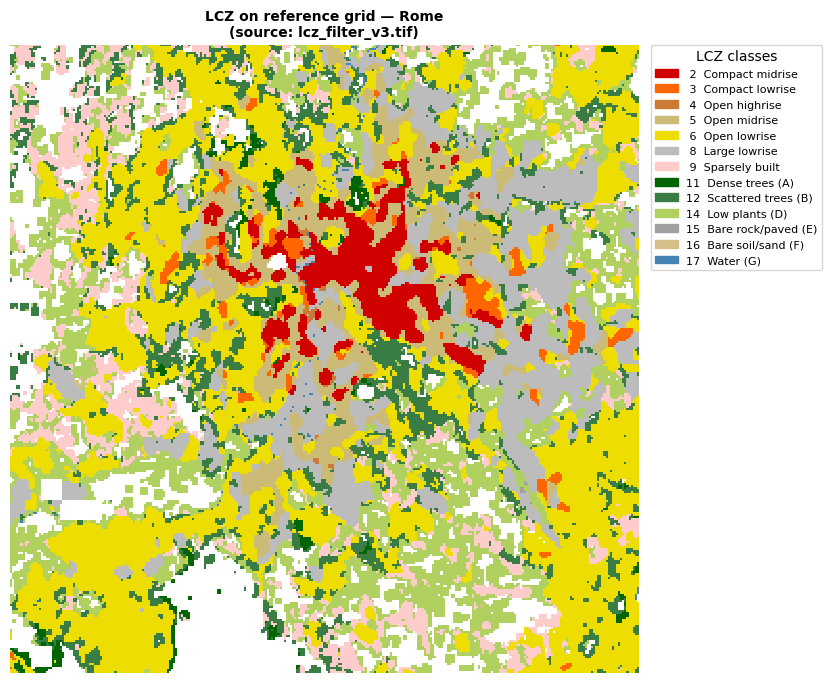


LCZ source: lcz_filter_v3.tif
 Class  Name                        Pixels   Share
     2  Compact midrise               3492    4.5%
     3  Compact lowrise               1388    1.8%
     4  Open highrise                   98    0.1%
     5  Open midrise                  6616    8.5%
     6  Open lowrise                 24892   31.9%
     8  Large lowrise                10832   13.9%
     9  Sparsely built                7268    9.3%
    11  Dense trees (A)                991    1.3%
    12  Scattered trees (B)           8322   10.7%
    14  Low plants (D)               13845   17.8%
    15  Bare rock/paved (E)             11    0.0%
    16  Bare soil/sand (F)              58    0.1%
    17  Water (G)                      116    0.1%


In [10]:
# Quick LCZ sanity check: verify which map was loaded
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

LCZ_COLORS = {
    1: "#8b0000",  2: "#d00000",  3: "#ff6600",  4: "#cc7a33",  5: "#ccbb77",
    6: "#eedd00",  7: "#ffdd99",  8: "#bcbcbc",  9: "#ffcccc", 10: "#555555",
   11: "#006400", 12: "#3a7d44", 13: "#99a640",
   14: "#b0d060", 15: "#a0a0a0", 16: "#d4c088", 17: "#4682b4",
}
LCZ_LABELS = {
    1: "Compact highrise", 2: "Compact midrise", 3: "Compact lowrise",
    4: "Open highrise", 5: "Open midrise", 6: "Open lowrise",
    7: "Lightweight low-rise", 8: "Large lowrise", 9: "Sparsely built",
   10: "Heavy industry", 11: "Dense trees (A)", 12: "Scattered trees (B)",
   13: "Bush/scrub (C)", 14: "Low plants (D)", 15: "Bare rock/paved (E)",
   16: "Bare soil/sand (F)", 17: "Water (G)",
}

colors = ["#00000000"] + [LCZ_COLORS[i] for i in range(1, 18)]
cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, 18.5, 1), cmap.N)

lcz_plot = np.where(lcz_on_ref > 0, lcz_on_ref, np.nan)
present = sorted(set(lcz_on_ref[lcz_on_ref > 0].ravel()))

fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(lcz_plot, cmap=cmap, norm=norm, interpolation="nearest")
ax.set_title(f"LCZ on reference grid — {CITY}\n(source: {lcz_candidates[0].name})",
             fontweight="bold", fontsize=10)
ax.axis("off")

patches = [mpatches.Patch(color=LCZ_COLORS[i], label=f"{i:>2}  {LCZ_LABELS[i]}")
           for i in present if i in LCZ_COLORS]
ax.legend(handles=patches, title="LCZ classes",
          bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, fontsize=8)
plt.tight_layout()
plt.show()

# Print class distribution
uniq, cnt = np.unique(lcz_on_ref[lcz_on_ref > 0], return_counts=True)
print(f"\nLCZ source: {lcz_candidates[0].name}")
print(f"{'Class':>6}  {'Name':<24}  {'Pixels':>8}  {'Share':>6}")
total = cnt.sum()
for c, n in zip(uniq, cnt):
    print(f"{c:>6}  {LCZ_LABELS.get(c, '?'):<24}  {n:>8}  {100*n/total:>5.1f}%")

In [11]:
print(f"CITY_MASK pixels:  {CITY_MASK.sum():,}")      # ~77,929 (all FUA)
print(f"BUILT_MASK pixels: {BUILT_MASK.sum():,}")    # ~54,586 (urban only)
print(f"Natural pixels:    {(CITY_MASK & ~BUILT_MASK).sum():,}")

CITY_MASK pixels:  77,929
BUILT_MASK pixels: 54,586
Natural pixels:    23,343


### 1.5 Baseline GVI Surface

The baseline greenness surface is derived from the city GVI point sample, rasterized onto the reference grid, and clipped to the city. Later sections aggregate this pixel surface to policy regions and compute the greenness deficit that the vegetation policy is designed to close.


In [12]:
import pandas as pd
# Load the city GVI point sample used to construct the baseline greenness surface
files_cfg = cfg.get("files", {})
gvi_rel = files_cfg.get("gvi_csv")
if not gvi_rel:
    raise KeyError("Missing 'files.gvi_csv' in YAML config.")

gvi_path = P(gvi_rel)  # Use P() to resolve relative to base_dir
if not gvi_path.exists():
    raise FileNotFoundError(f"GVI CSV not found: {gvi_path}")

gvi_df = pd.read_csv(gvi_path)

# Standardize the input column names so the downstream rasterization is city-agnostic
colmap = {c.lower(): c for c in gvi_df.columns}
gvi_df = gvi_df.rename(columns={
    colmap.get("x", "x"): "x",
    colmap.get("y", "y"): "y",
    colmap.get("gvi", "gvi"): "gvi",
    colmap.get("lcz_filter_v3", "lcz"): "lcz"
})

print(f"GVI points loaded: {len(gvi_df):,}")
print(f"GVI range: {gvi_df['gvi'].min():.2f} - {gvi_df['gvi'].max():.2f}")

# Turn the point table into a GeoDataFrame on the reference CRS
gvi_gdf = gpd.GeoDataFrame(
    gvi_df,
    geometry=gpd.points_from_xy(gvi_df["x"], gvi_df["y"]),
    crs="EPSG:4326"
).to_crs(ref_crs)

# Normalize GVI to the 1-100 scale if the source arrives on 0-1
if gvi_gdf["gvi"].max() <= 1.2:
    print("[INFO] GVI appears to be on 0-1 scale. Converting to 1-100.")
    gvi_gdf["gvi"] = gvi_gdf["gvi"] * 100.0
else:
    print("[INFO] GVI is on 1-100 scale.")

# Restrict the point sample to the functional urban area boundary
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))
if fua_gpkg.exists():
    fua = gpd.read_file(fua_gpkg, layer="fua").to_crs(ref_crs)
    gvi_gdf = gvi_gdf.sjoin(fua[["geometry"]], predicate="within", how="inner")
    gvi_gdf = gvi_gdf.drop(columns=["index_right"], errors="ignore")
    print(f"GVI points after FUA filter: {len(gvi_gdf):,}")

# Rasterize point GVI to the reference grid by cell mean, then fill gaps conservatively
from rasterio.transform import rowcol

def rasterize_points_to_grid(gdf, value_col, transform, shape, fill_missing=True):
    """
    Rasterize point values to grid by averaging within each cell.
    Optionally fill missing cells with nearest neighbor.
    """
    h, w = shape
    xs = gdf.geometry.x.values
    ys = gdf.geometry.y.values
    vals = gdf[value_col].values.astype(float)
    
    # Convert coordinates to row/col
    rows, cols = rowcol(transform, xs, ys)
    rows = np.array(rows, dtype=int)
    cols = np.array(cols, dtype=int)
    
    # Filter to valid bounds
    valid = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
    rows, cols, vals = rows[valid], cols[valid], vals[valid]
    
    # Aggregate by cell (mean)
    sum_grid = np.zeros((h, w), dtype=float)
    cnt_grid = np.zeros((h, w), dtype=float)
    np.add.at(sum_grid, (rows, cols), vals)
    np.add.at(cnt_grid, (rows, cols), 1.0)
    
    with np.errstate(invalid='ignore'):
        result = np.where(cnt_grid > 0, sum_grid / cnt_grid, np.nan)
    
    # Fill missing with nearest neighbor within valid area
    if fill_missing:
        valid_mask = np.isfinite(result)
        if valid_mask.any() and (~valid_mask).any():
            _, (iy, ix) = ndi.distance_transform_edt(~valid_mask, return_indices=True)
            missing = ~valid_mask
            result[missing] = result[iy[missing], ix[missing]]
    
    return result

gvi_on_ref = rasterize_points_to_grid(
    gvi_gdf, "gvi", ref_transform, (HGT, WDT), fill_missing=True
)

# Clip the rasterized GVI field to the city mask
gvi_on_ref = np.where(CITY_MASK, gvi_on_ref, np.nan)

print(f"GVI rasterized to reference grid.")
print(f"  Finite pixels: {np.isfinite(gvi_on_ref).sum():,}")
print(f"  Mean GVI (city): {np.nanmean(gvi_on_ref[CITY_MASK]):.2f}")

GVI points loaded: 1,610,858
GVI range: 0.92 - 70.26
[INFO] GVI is on 1-100 scale.
GVI points after FUA filter: 3,458
GVI rasterized to reference grid.
  Finite pixels: 77,929
  Mean GVI (city): 21.25


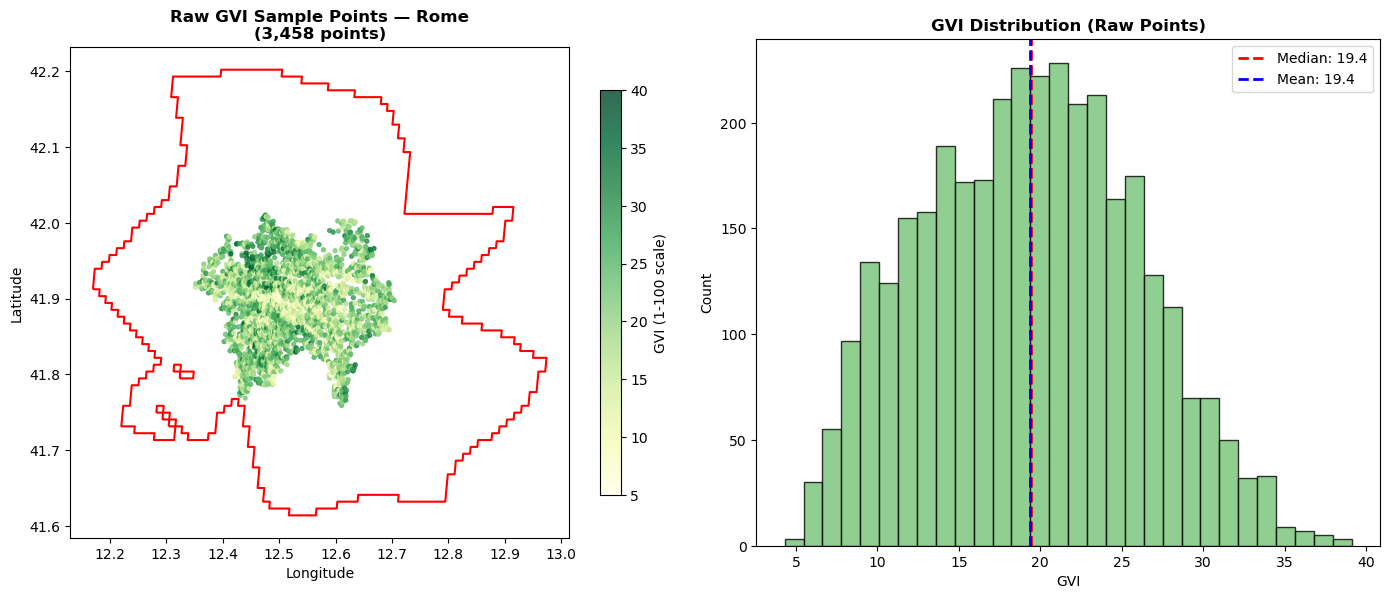

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/rome_gvi_raw_points.png


In [13]:
import matplotlib.pyplot as plt

# Diagnostic view of the raw point sample before rasterization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Load the FUA boundary for the diagnostic plot
fua_4326 = gpd.read_file(fua_gpkg, layer="fua").to_crs("EPSG:4326")
gvi_4326 = gvi_gdf.to_crs("EPSG:4326")

# 1. Raw GVI points
ax1 = axes[0]
fua_4326.boundary.plot(ax=ax1, edgecolor="red", linewidth=1.5, label="FUA boundary")
scatter = ax1.scatter(gvi_4326.geometry.x, gvi_4326.geometry.y, 
                      c=gvi_4326["gvi"], cmap="YlGn", s=8, alpha=0.8,
                      vmin=5, vmax=40)
ax1.set_title(f"Raw GVI Sample Points — {CITY}\n({len(gvi_4326):,} points)", fontweight='bold')
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
plt.colorbar(scatter, ax=ax1, label="GVI (1-100 scale)", shrink=0.8)

# 2. GVI histogram
ax2 = axes[1]
ax2.hist(gvi_gdf["gvi"], bins=30, color='#74c476', edgecolor='black', alpha=0.8)
ax2.axvline(gvi_gdf["gvi"].median(), color='red', linestyle='--', linewidth=2, 
            label=f'Median: {gvi_gdf["gvi"].median():.1f}')
ax2.axvline(gvi_gdf["gvi"].mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Mean: {gvi_gdf["gvi"].mean():.1f}')
ax2.set_xlabel("GVI")
ax2.set_ylabel("Count")
ax2.set_title("GVI Distribution (Raw Points)", fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_gvi_raw_points.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {OUT / f'{SLUG}_gvi_raw_points.png'}")

### 1.6 Policy Geography and Regional Masks

The regional rasters used here are inherited from `NB05`. The filename `muni_on_ref_{slug}.npz` is **legacy naming** shared across cities, but for Rome the operative vegetation layer is the **Municipi** regional layer because the config sets `veg_regions: regions`.

In practice, this section aligns three things:
- the rasterized policy-region IDs from `NB05`
- the vector layer used for labels and tables
- the common analysis mask defining where the policy is allowed to operate


In [14]:
# Load the policy-region raster, coverage mask, and analysis mask created in NB5
# NB5 keeps a legacy filename here; the operative geography depends on the city config, not on the filename
z = np.load(INT / f"muni_on_ref_{SLUG}.npz")
region_on_ref = z["muni_on_ref"].astype("int32")
region_cov = z["muni_cov"].astype(bool)
ANALYSIS_MASK_REGION = z["analysis_mask_muni"].astype(bool)

# Canonical mask names used by the rest of the notebook
MASK_CITY   = CITY_MASK
MASK_REGION = region_cov
MASK_POLICY = ANALYSIS_MASK_REGION  # = CITY_MASK ∩ region footprint

# Load the matching vector layer and normalize its ID/name columns
trees_cfg = cfg.get("trees", {})
VEG_REGION_SOURCE = trees_cfg.get("veg_regions", "regions")   # "regions" or "zones"
VEG_REGION_LABEL = trees_cfg.get("veg_region_label", "Region")

# Choose regions or zones according to the vegetation settings in the YAML
if VEG_REGION_SOURCE == "regions":
    _gpkg_path = INT / f"municipi_{SLUG}.gpkg"
else:
    # zones: try multiple naming conventions
    _gpkg_candidates = [
        INT / f"zones_{SLUG}.gpkg",
        INT / f"freguesia_{SLUG}.gpkg",
        INT / f"municipi_{SLUG}.gpkg",
    ]
    _gpkg_path = next((p for p in _gpkg_candidates if p.exists()), _gpkg_candidates[0])

region_gdf = gpd.read_file(_gpkg_path)

# Normalize the vector attributes to a common region_id / region_name schema
_cols = list(region_gdf.columns)
_id_col = next((c for c in _cols if c in ["muni_id", "zone_code", "cap_code", "region_id"]), _cols[0])
_name_col = next((c for c in _cols if c in ["muni_name", "zone_name", "freguesia", "region_name"]), _cols[1] if len(_cols) > 2 else _cols[0])

region_gdf = region_gdf.rename(columns={_id_col: "region_id", _name_col: "region_name"})

# When the vector layer uses string IDs, align it with the integer IDs stored in the raster
unique_ids_raster = sorted(set(region_on_ref[region_on_ref > 0].ravel()))
if not all(isinstance(x, (int, float)) for x in region_gdf["region_id"].values[:3]):
    # String IDs (Athens/Lisbon) — create integer mapping
    # The raster uses integer IDs 1..N; match by order in gpkg
    if len(region_gdf) >= len(unique_ids_raster):
        region_gdf["region_id"] = range(1, len(region_gdf) + 1)
    else:
        region_gdf["region_id"] = unique_ids_raster[:len(region_gdf)]
else:
    region_gdf["region_id"] = region_gdf["region_id"].astype(int)

print(f"✓ Loaded {len(region_gdf)} {VEG_REGION_LABEL}s from {_gpkg_path.name}")
print(f"  IDs in raster: {len(unique_ids_raster)}, IDs in gpkg: {len(region_gdf)}")
print(f"  Region label: {VEG_REGION_LABEL}")

✓ Loaded 15 Municipios from municipi_rome.gpkg
  IDs in raster: 15, IDs in gpkg: 15
  Region label: Municipio


### 1.7 Physical Policy Scope and Regional GVI Baseline

The vegetation policy is only allowed to operate where two conditions are met simultaneously:
- the pixel belongs to the policy region mask inherited from `NB05`
- the pixel is built-up according to the LCZ classification

Regional baseline GVI is then computed on that physical scope, which means the policy target is defined from the **relevant greening domain**, not from parks, water, or excluded areas.


In [15]:
# Trees are only applied on built pixels inside the policy domain
SCOPE_PHYS = MASK_POLICY & BUILT_MASK  # built-up within region policy domain

def compute_region_gvi_stats(gvi_grid, region_grid, scope_mask, region_df, pop_grid=None):
    """
    Compute GVI statistics per regionso.
    
    Returns DataFrame with:
    - region_id, region_name
    - gvi_mean: spatial mean GVI (built LCZ only)
    - gvi_popw: population-weighted mean GVI
    - n_pixels: number of valid pixels
    - population: total population in regionso
    """
    records = []
    
    for _, row in region_df.iterrows():
        mid = int(row["region_id"])
        mname = row["region_name"]
        
        # Mask for this regionso
        m = (region_grid == mid) & scope_mask & np.isfinite(gvi_grid)
        
        if m.sum() == 0:
            continue
        
        gvi_vals = gvi_grid[m]
        gvi_mean = float(np.mean(gvi_vals))
        n_pixels = int(m.sum())
        
        # Population-weighted mean
        if pop_grid is not None:
            pop_m = np.where(m, np.nan_to_num(pop_grid, nan=0.0), 0.0)
            total_pop = float(np.sum(pop_m))
            if total_pop > 0:
                gvi_popw = float(np.sum(gvi_vals * pop_m[m]) / total_pop)
            else:
                gvi_popw = gvi_mean
        else:
            total_pop = np.nan
            gvi_popw = gvi_mean
        
        records.append({
            "region_id": mid,
            "region_name": mname,
            "gvi_mean": gvi_mean,
            "gvi_popw": gvi_popw,
            "n_pixels": n_pixels,
            "population": total_pop
        })
    
    return pd.DataFrame(records).sort_values("region_id").reset_index(drop=True)

region_gvi = compute_region_gvi_stats(gvi_on_ref, region_on_ref, SCOPE_PHYS, region_gdf, pop_on_ref)

print("\n=== Baseline GVI by regionso ===")
print(region_gvi.to_string(index=False))

print(f"\nCitywide GVI summary (spatial means across regions):")
print(f"  Min:    {region_gvi['gvi_mean'].min():.2f}")
print(f"  Q1:     {region_gvi['gvi_mean'].quantile(0.25):.2f}")
print(f"  Median: {region_gvi['gvi_mean'].median():.2f}")
print(f"  Q3:     {region_gvi['gvi_mean'].quantile(0.75):.2f}")
print(f"  Max:    {region_gvi['gvi_mean'].max():.2f}")


=== Baseline GVI by regionso ===
 region_id         region_name  gvi_mean  gvi_popw  n_pixels    population
         1    Municipio Roma I 16.389982 15.132407      1700 169068.578125
         2   Municipio Roma II 19.833924 18.793288      1732 165450.421875
         3  Municipio Roma III 20.958814 20.935588      2783 144651.843750
         4   Municipio Roma IV 18.182835 17.886077      3375 173737.531250
         5    Municipio Roma V 16.397141 15.946564      2585 177127.281250
         6   Municipio Roma VI 18.434601 17.882815      2223 125796.171875
         7  Municipio Roma VII 19.070501 17.323970      3897 261672.250000
         8 Municipio Roma VIII 21.181942 19.315671      2116 112030.320312
         9   Municipio Roma IX 20.960515 20.779337      6485 212798.546875
        10    Municipio Roma X 20.777520 20.520338      4008 220952.812500
        11   Municipio Roma XI 23.968745 20.460046      3698 112160.445312
        12  Municipio Roma XII 21.437093 19.783915      3127 13777

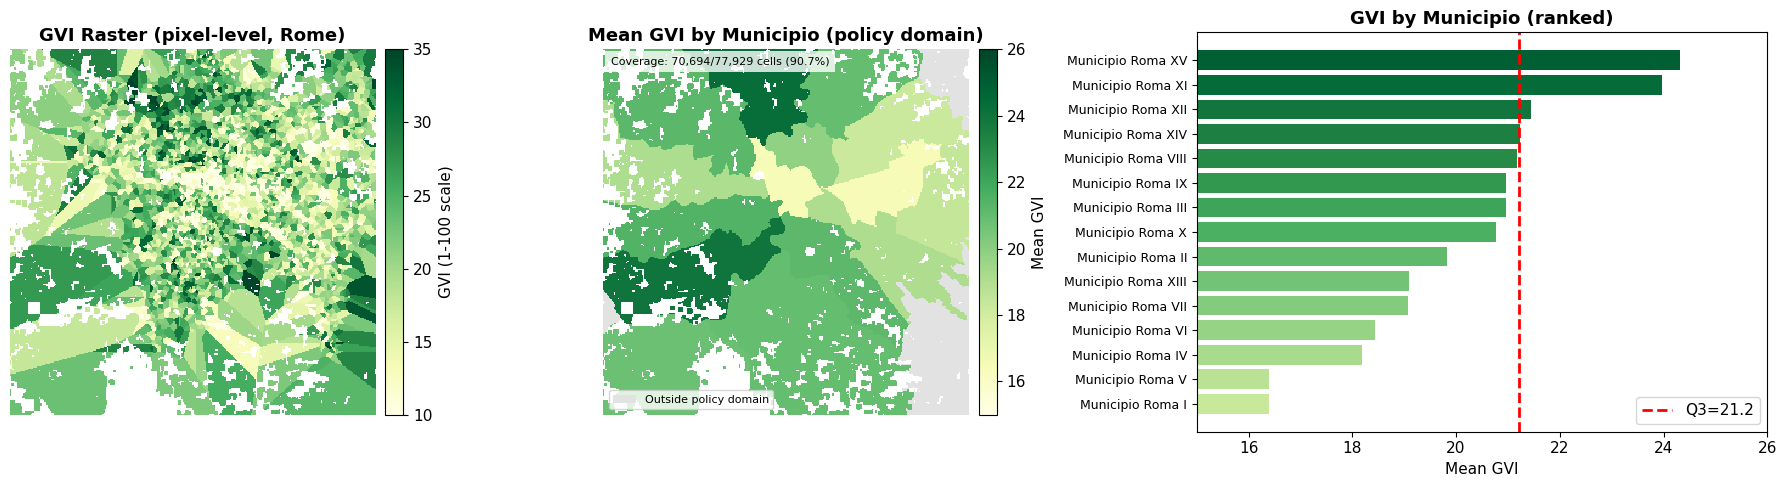

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/rome_gvi_baseline.png


In [16]:
# Diagnostic maps of the baseline pixel and regional greenness surfaces
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Plot styling for cross-city readability
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": False,
})

# Compute the observed Q3 greenness benchmark used later as the policy target
q3_gvi = float(region_gvi["gvi_mean"].quantile(0.75))

# Coverage diagnostics to show when the policy domain covers only part of the city mask
city_cells = int(np.sum(MASK_CITY))
policy_cells = int(np.sum(MASK_POLICY))
policy_cov_pct = 100.0 * policy_cells / max(city_cells, 1)

# Adapt the figure layout to the number of policy regions
n_regions = int(len(region_gvi))
fig_h = 6.8 if n_regions > 30 else 5.0
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, fig_h),
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.45]},
)

# 1. Pixel-level baseline GVI across the city mask
ax1 = axes[0]
gvi_plot = np.where(MASK_CITY, gvi_on_ref, np.nan)
im1 = ax1.imshow(gvi_plot, cmap="YlGn", vmin=10, vmax=35, interpolation="nearest")
ax1.set_title(f"GVI Raster (pixel-level, {CITY})", fontweight="bold")
ax1.axis("off")
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax1, label="GVI (1-100 scale)")

# 2. Regional mean GVI mapped back onto the city extent
ax2 = axes[1]
gvi_by_region = np.full_like(gvi_on_ref, np.nan, dtype=float)
for _, row in region_gvi.iterrows():
    rid = int(row["region_id"])
    gvi_by_region[region_on_ref == rid] = float(row["gvi_mean"])

# Gray out the part of the city mask that lies outside the vegetation policy domain
outside_policy = np.where(MASK_CITY & (~MASK_POLICY), 1.0, np.nan)
ax2.imshow(
    outside_policy,
    cmap=mcolors.ListedColormap(["#E2E2E2"]),
    vmin=0,
    vmax=1,
    interpolation="nearest",
)

# Overlay the policy-domain regional means
im2 = ax2.imshow(
    np.where(MASK_POLICY, gvi_by_region, np.nan),
    cmap="YlGn",
    vmin=15,
    vmax=26,
    interpolation="nearest",
)
ax2.set_title(f"Mean GVI by {VEG_REGION_LABEL} (policy domain)", fontweight="bold")
ax2.axis("off")
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im2, cax=cax2, label="Mean GVI")
ax2.legend(
    handles=[Patch(facecolor="#E2E2E2", edgecolor="none", label="Outside policy domain")],
    loc="lower left",
    frameon=True,
    fontsize=8,
)
ax2.text(
    0.02,
    0.98,
    f"Coverage: {policy_cells:,}/{city_cells:,} cells ({policy_cov_pct:.1f}%)",
    transform=ax2.transAxes,
    ha="left",
    va="top",
    fontsize=8,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
)

# 3. Ranked regional GVI chart, with truncation when there are many regions
ax3 = axes[2]
region_sorted = region_gvi.sort_values("gvi_mean").reset_index(drop=True)

max_labels = 24  # keep panel readable when N is large
if len(region_sorted) <= max_labels:
    plot_df = region_sorted.copy()
    title_suffix = "ranked"
    omitted_note = None
else:
    n_each = max_labels // 2
    low_df = region_sorted.head(n_each)
    high_df = region_sorted.tail(n_each)
    plot_df = pd.concat([low_df, high_df], ignore_index=True)
    omitted = len(region_sorted) - len(plot_df)
    title_suffix = f"ranked (lowest/highest {n_each})"
    omitted_note = f"{omitted} middle regions omitted"

colors = plt.cm.YlGn(np.linspace(0.3, 0.9, len(plot_df)))
ax3.barh(range(len(plot_df)), plot_df["gvi_mean"], color=colors)
ax3.set_yticks(range(len(plot_df)))
ax3.set_yticklabels(
    [str(n)[:32] for n in plot_df["region_name"]],
    fontsize=8 if len(plot_df) > 20 else 9,
)
ax3.axvline(q3_gvi, color="red", linestyle="--", linewidth=2, label=f"Q3={q3_gvi:.1f}")
ax3.set_xlabel("Mean GVI")
ax3.set_title(f"GVI by {VEG_REGION_LABEL} ({title_suffix})", fontweight="bold")
ax3.legend(loc="lower right")

# Use data-driven x-limits so the panel works across cities
x_min = float(np.floor(min(region_sorted["gvi_mean"].min(), q3_gvi) - 1))
x_max = float(np.ceil(max(region_sorted["gvi_mean"].max(), q3_gvi) + 1))
ax3.set_xlim(x_min, x_max)

if omitted_note is not None:
    ax3.text(
        0.02,
        0.02,
        omitted_note,
        transform=ax3.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_gvi_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT / f'{SLUG}_gvi_baseline.png'}")


## Emulator Bridge

The main cooling pathway in this notebook is **not** direct use of a T2M vegetation coefficient. The workflow is:
`ΔGVI -> ΔLST coefficients -> emulator-based translation -> ΔT2M`

For Rome, the notebook loads the Rome-specific emulator bundle declared in the config. Later in the notebook, the direct T2M coefficient table is used only as a **diagnostic bridge check**, not as the main mortality pathway.


In [17]:
import json
from pathlib import Path

# Load the city-configured emulator bundle used for the LST-to-T2M bridge
_emu_rel = trees_cfg.get("veg_emulator_bundle", f"emulator/bundles/emulator_bundle_{SLUG}_quadratic_holdout_safe.json")
EMU_PATH = OUT / _emu_rel
if not EMU_PATH.exists():
    # Fallback: search for any bundle
    _emu_dir = OUT / "emulator" / "bundles"
    if _emu_dir.exists():
        _candidates = sorted(_emu_dir.glob("emulator_bundle_*.json"))
        if _candidates:
            EMU_PATH = _candidates[0]
            print(f"⚠ Config bundle not found, using: {EMU_PATH.name}")
        else:
            raise FileNotFoundError(f"No emulator bundle found in {_emu_dir}")
    else:
        raise FileNotFoundError(f"Emulator bundle not found: {EMU_PATH}")

with open(EMU_PATH, "r") as f:
    EMU = json.load(f)

print(f"✓ Loaded emulator: {EMU_PATH.name}")
EMU

✓ Loaded emulator: emulator_bundle_pooled_all_quadratic_holdout_safe.json


{'model_name': 'pooled_all_quadratic_holdout_safe',
 'cities': ['addis_abeba',
  'alicante',
  'amman',
  'amsterdam',
  'antwerp',
  'auckland',
  'barcelona',
  'bari',
  'basel',
  'belgrado',
  'berlin',
  'bilbao',
  'birmingham',
  'bogota',
  'bordeaux',
  'brasov',
  'bratislava',
  'brussels',
  'bucharest',
  'buenos_aires',
  'cairo',
  'cape_town',
  'charleroi',
  'chennai',
  'cluj_napoca',
  'cologne',
  'copenhagen',
  'curitiba',
  'dakar',
  'debrecen',
  'dhaka',
  'dubai',
  'dublin',
  'dusseldorf',
  'edinburgh',
  'frankfurt_am_main',
  'gdansk',
  'geneva',
  'genoa',
  'ghent',
  'glasgow',
  'graz',
  'gyor',
  'hamburg',
  'helsinki',
  'ho_chi_minh',
  'hong_kong',
  'islamabad',
  'istanbul',
  'jakarta',
  'karachi',
  'klaipeda',
  'kosice',
  'krakow',
  'lagos',
  'leeds',
  'leipzig',
  'liege',
  'lille',
  'lima',
  'lisbon',
  'ljubljana',
  'lodz',
  'london',
  'los_angeles',
  'luxembourg',
  'lyon',
  'malaga',
  'marrakesh',
  'marseille',
  'm

## 2. Define the vegetation policy

The main policy in this notebook is a **uniform regional catch-up policy**. Each policy region below the current Q3 greenness level receives enough additional greening to reach the target, subject to any cap if one is provided. Later on, the notebook compares that main policy to an SVI-weighted allocation sensitivity, but the uniform Q3 policy is the primary vegetation scenario exported downstream.


The policy is deliberately simple and transparent: it closes greenness deficits region by region rather than solving a fine-grained optimization problem. That makes the intervention easy to describe, easy to compare across cities, and easy to carry forward into the CBA.


### 2.1 Policy Framework

The target is defined from the observed regional GVI distribution, not imposed externally. The notebook takes the current Q3 of regional mean GVI, rounds it upward, and uses that as the greenness benchmark to be reached by under-greened regions.


**Target:** raise under-greened policy regions to the current Q3 of regional mean GVI.

**Scope:** only built LCZ pixels inside the policy domain (`SCOPE_PHYS`).

**Allocation rule:** the baseline policy is uniform within each policy region rather than pixel-targeted.


In [18]:
# Derive the main uniform Q3-target policy parameters
# Target = observed Q3 of regional mean GVI, rounded upward to one decimal
Q3_RAW = float(region_gvi["gvi_mean"].quantile(0.75))
TARGET_GVI = float(np.ceil(Q3_RAW * 10) / 10)  # Round up to nearest 0.1

# Optional cap on regional ΔGVI; if absent, the current notebook leaves the intervention uncapped
trees_cfg = cfg.get("trees", {}) or {}
CAP_DGVI = float(trees_cfg.get("cap_pp", 100.0))  # Default: no cap

print(f"\n=== Uniform Policy Parameters ===")
print(f"Q3 (raw):     {Q3_RAW:.2f}")
print(f"Target GVI:   {TARGET_GVI:.2f}")
print(f"ΔGVI cap:     {CAP_DGVI:.2f}")

# Compute the regional greenness shortfall to the chosen target
def compute_policy_dgvi(region_gvi_df, target, cap=None):
    """
    Compute ΔGVI for each {VEG_REGION_LABEL} to reach target.
    ΔGVI = max(0, min(target - baseline, cap))
    """
    df = region_gvi_df.copy()
    
    # Raw shortfall
    df["shortfall"] = target - df["gvi_mean"]
    
    # ΔGVI: positive shortfall, capped
    df["dGVI"] = df["shortfall"].clip(lower=0.0)
    if cap is not None and cap < 100:
        df["dGVI"] = df["dGVI"].clip(upper=cap)
    
    # Post-policy GVI
    df["gvi_after"] = df["gvi_mean"] + df["dGVI"]
    
    # Hit target?
    df["hit_target"] = df["gvi_after"] >= target - 0.001
    
    return df

policy_df = compute_policy_dgvi(region_gvi, TARGET_GVI, CAP_DGVI)

print("\n=== Policy Result by {VEG_REGION_LABEL} ===")
cols = ["region_id", "region_name", "gvi_mean", "dGVI", "gvi_after", "hit_target"]
print(policy_df[cols].to_string(index=False))

# Summarise the size of the intervention before moving to cooling calculations
total_dGVI = float(policy_df["dGVI"].sum())
mean_dGVI = float(policy_df["dGVI"].mean())
n_treated = int((policy_df["dGVI"] > 0).sum())

print(f"\n=== Policy Summary ===")
print(f"{VEG_REGION_LABEL}s treated:  {n_treated} / {len(policy_df)}")
print(f"Total ΔGVI:        {total_dGVI:.2f} points")
print(f"Mean ΔGVI:         {mean_dGVI:.2f} points")
print(f"Estimated cost:    €{total_dGVI * 10:.1f}M")


=== Uniform Policy Parameters ===
Q3 (raw):     21.20
Target GVI:   21.30
ΔGVI cap:     100.00

=== Policy Result by {VEG_REGION_LABEL} ===
 region_id         region_name  gvi_mean     dGVI  gvi_after  hit_target
         1    Municipio Roma I 16.389982 4.910018  21.300000        True
         2   Municipio Roma II 19.833924 1.466076  21.300000        True
         3  Municipio Roma III 20.958814 0.341186  21.300000        True
         4   Municipio Roma IV 18.182835 3.117165  21.300000        True
         5    Municipio Roma V 16.397141 4.902859  21.300000        True
         6   Municipio Roma VI 18.434601 2.865399  21.300000        True
         7  Municipio Roma VII 19.070501 2.229499  21.300000        True
         8 Municipio Roma VIII 21.181942 0.118058  21.300000        True
         9   Municipio Roma IX 20.960515 0.339485  21.300000        True
        10    Municipio Roma X 20.777520 0.522480  21.300000        True
        11   Municipio Roma XI 23.968745 0.000000  23.96

### 2.2 Uniform Q3 Catch-Up Policy

Once the target is defined, each policy region receives a `ΔGVI` equal to its shortfall, clipped at zero and optionally capped if the config provides one. The result is a region-uniform greening increment that can be mapped back to the grid for the cooling calculations.


In other words, the main policy answers a simple question: *how much extra greenness would each under-greened region need in order to reach today’s upper-quartile benchmark?*


In [19]:
# Map the regional greenness increments back onto the reference grid
# The main policy is region-uniform: every treated pixel in a region receives the same regional ΔGVI
# Lookup from policy-region ID to assigned greenness increment

policy_df = region_gvi.copy()
policy_df["dGVI"] = np.clip(TARGET_GVI - policy_df["gvi_mean"], 0, None)
policy_df["gvi_after"] = policy_df["gvi_mean"] + policy_df["dGVI"]

# Expand the regional assignment to the full grid
dGVI_lut = dict(zip(policy_df["region_id"], policy_df["dGVI"]))
dGVI_map = np.zeros((HGT, WDT), dtype=float)
for mid, dgvi in dGVI_lut.items():
    dGVI_map[region_on_ref == mid] = dgvi

# Keep the intervention only where the vegetation policy is physically allowed to operate
dGVI_map = np.where(SCOPE_PHYS, dGVI_map, 0)

print("ΔGVI map created.")
print(f"  Treated pixels: {(dGVI_map > 0).sum():,}")
print(f"  Max ΔGVI:       {dGVI_map.max():.2f}")

ΔGVI map created.
  Treated pixels: 38,643
  Max ΔGVI:       4.91


### 2.3 Allocation Summary

The summary below reports the size of the intervention both as a total regional greenness increment and as a citywide population-weighted average. These are useful descriptive quantities before translating vegetation into cooling and health effects.


In [20]:
# Summarise the policy in both total and population-weighted terms
total_dGVI_raw = float(policy_df["dGVI"].sum())
citywide_dGVI_popw = float(np.average(dGVI_map[SCOPE_PHYS], weights=pop_on_ref[SCOPE_PHYS]))

print("=== Uniform Policy Summary ===")
print(f"Total ΔGVI (sum of {VEG_REGION_LABEL}):  {total_dGVI_raw:.2f} index points")
print(f"Citywide ΔGVI (pop-weighted):   {citywide_dGVI_popw:.4f} points")
print(f"\nMunicipality allocation:")
for _, row in policy_df.sort_values("dGVI", ascending=False).head(5).iterrows():
    print(f"  {row['region_name']}: GVI {row['gvi_mean']:.1f} → {row['gvi_after']:.1f} (Δ={row['dGVI']:.2f})")

=== Uniform Policy Summary ===
Total ΔGVI (sum of Municipio):  23.10 index points
Citywide ΔGVI (pop-weighted):   1.6503 points

Municipality allocation:
  Municipio Roma I: GVI 16.4 → 21.3 (Δ=4.91)
  Municipio Roma V: GVI 16.4 → 21.3 (Δ=4.90)
  Municipio Roma IV: GVI 18.2 → 21.3 (Δ=3.12)
  Municipio Roma VI: GVI 18.4 → 21.3 (Δ=2.87)
  Municipio Roma VII: GVI 19.1 → 21.3 (Δ=2.23)


### 2.4 Diagnostic Maps of the Main Policy

The figures in this section are descriptive checks: they show the baseline regional pattern, the post-policy target pattern, and the regions driving most of the intervention budget.


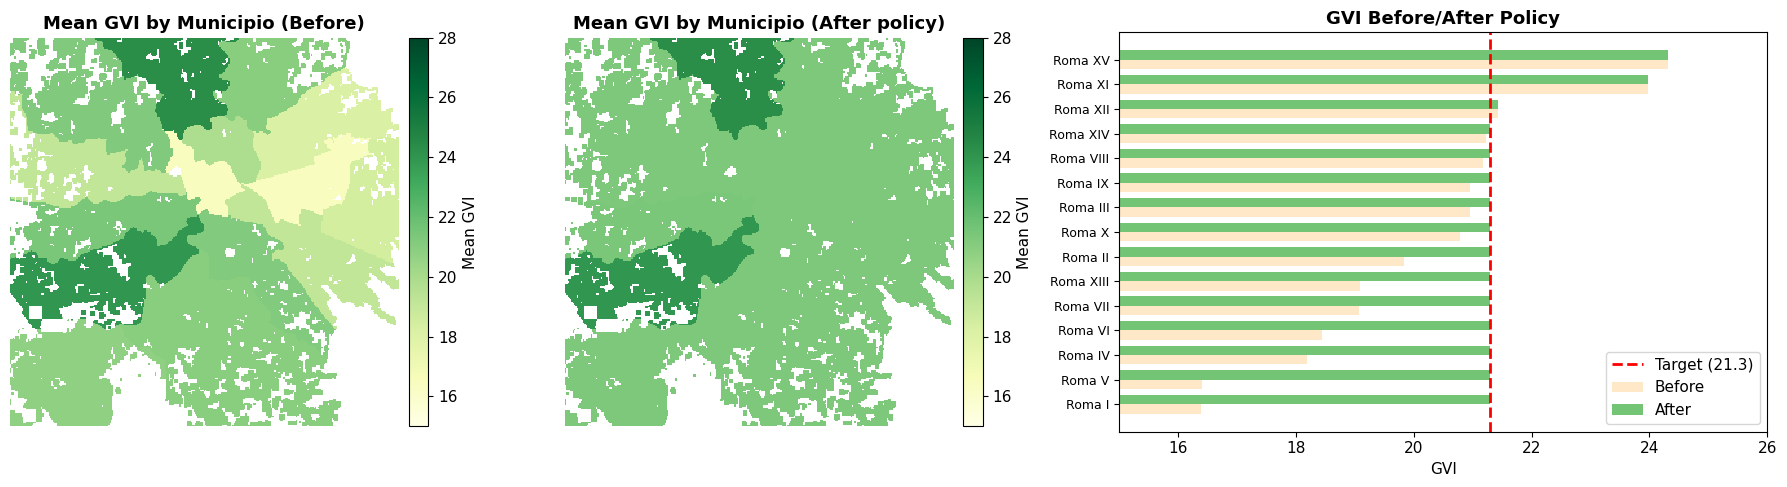

In [21]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_regions = int(len(policy_df))
fig_h = 6.8 if n_regions > 30 else 5.0
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, fig_h),
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.55]},
)

# Use a common color scale so the before/after maps can be compared directly
VMIN, VMAX = 15, 28

# 1) Regional mean GVI before the policy
ax1 = axes[0]
gvi_before_by_muni = np.full_like(gvi_on_ref, np.nan, dtype=float)
for _, row in region_gvi.iterrows():
    mid = int(row["region_id"])
    gvi_before_by_muni[region_on_ref == mid] = float(row["gvi_mean"])
gvi_before_by_muni = np.where(MASK_POLICY, gvi_before_by_muni, np.nan)

im1 = ax1.imshow(gvi_before_by_muni, cmap="YlGn", vmin=VMIN, vmax=VMAX, interpolation="nearest")
ax1.set_title(f"Mean GVI by {VEG_REGION_LABEL} (Before)", fontweight="bold")
ax1.axis("off")
div1 = make_axes_locatable(ax1)
cax1 = div1.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax1, label="Mean GVI")

# 2) Regional mean GVI after the policy
ax2 = axes[1]
gvi_after_by_muni = np.full_like(gvi_on_ref, np.nan, dtype=float)
for _, row in policy_df.iterrows():
    mid = int(row["region_id"])
    gvi_after_by_muni[region_on_ref == mid] = float(row["gvi_after"])
gvi_after_by_muni = np.where(MASK_POLICY, gvi_after_by_muni, np.nan)

im2 = ax2.imshow(gvi_after_by_muni, cmap="YlGn", vmin=VMIN, vmax=VMAX, interpolation="nearest")
ax2.set_title(f"Mean GVI by {VEG_REGION_LABEL} (After policy)", fontweight="bold")
ax2.axis("off")
div2 = make_axes_locatable(ax2)
cax2 = div2.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im2, cax=cax2, label="Mean GVI")

# 3) Ranked before/after comparison by policy region
ax3 = axes[2]
policy_sorted = policy_df.sort_values("gvi_mean").reset_index(drop=True)

max_labels = 24
if len(policy_sorted) <= max_labels:
    plot_df = policy_sorted.copy()
    title_suffix = ""
    omitted_note = None
else:
    n_each = max_labels // 2
    low_df = policy_sorted.head(n_each)
    high_df = policy_sorted.tail(n_each)
    plot_df = pd.concat([low_df, high_df], ignore_index=True)
    omitted = len(policy_sorted) - len(plot_df)
    title_suffix = f" (lowest/highest {n_each})"
    omitted_note = f"{omitted} middle regions omitted"

x = np.arange(len(plot_df))
width = 0.38

ax3.barh(x - width / 2, plot_df["gvi_mean"], width, label="Before", color="#fee8c8")
ax3.barh(x + width / 2, plot_df["gvi_after"], width, label="After", color="#74c476")

ax3.axvline(TARGET_GVI, color="red", linestyle="--", linewidth=2, label=f"Target ({TARGET_GVI:.1f})")

# Trim long prefixes so region labels stay readable across cities
labels = [str(n) for n in plot_df["region_name"]]
if isinstance(VEG_REGION_LABEL, str):
    pref = f"{VEG_REGION_LABEL} "
    labels = [lab.replace(pref, "") if lab.startswith(pref) else lab for lab in labels]
labels = [lab[:32] for lab in labels]

ax3.set_yticks(x)
ax3.set_yticklabels(labels, fontsize=8 if len(plot_df) > 20 else 9)
ax3.set_xlabel("GVI")
ax3.set_title(f"GVI Before/After Policy{title_suffix}", fontweight="bold")
ax3.legend(loc="lower right")

x_min = float(np.floor(min(plot_df["gvi_mean"].min(), plot_df["gvi_after"].min(), TARGET_GVI) - 1))
x_max = float(np.ceil(max(plot_df["gvi_mean"].max(), plot_df["gvi_after"].max(), TARGET_GVI) + 1))
ax3.set_xlim(x_min, x_max)

if omitted_note is not None:
    ax3.text(
        0.02,
        0.02,
        omitted_note,
        transform=ax3.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_muni_before_after_policy.png", dpi=150, bbox_inches="tight")
plt.show()


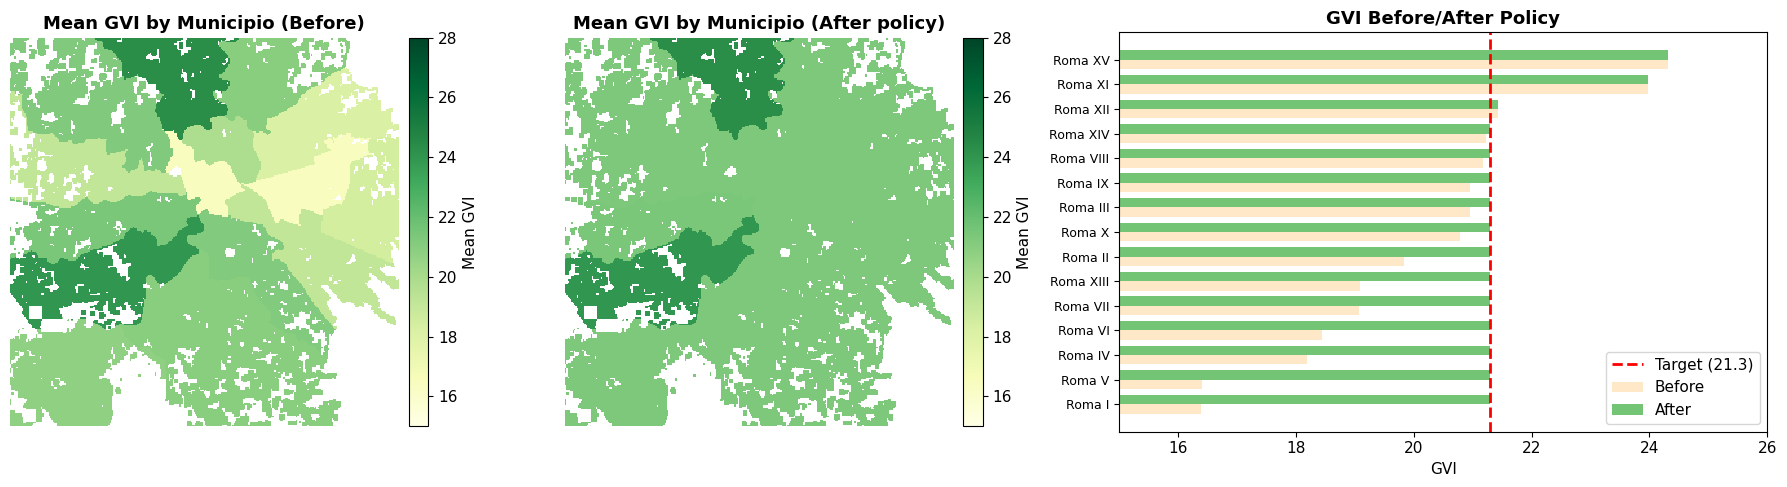

In [22]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

n_regions = int(len(policy_df))
fig_h = 6.8 if n_regions > 30 else 5.0
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, fig_h),
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.55]},
)

# Use a common color scale so the before/after maps can be compared directly
VMIN, VMAX = 15, 28

# 1) Regional mean GVI before the policy
ax1 = axes[0]
gvi_before_by_muni = np.full_like(gvi_on_ref, np.nan, dtype=float)
for _, row in region_gvi.iterrows():
    mid = int(row["region_id"])
    gvi_before_by_muni[region_on_ref == mid] = float(row["gvi_mean"])
gvi_before_by_muni = np.where(MASK_POLICY, gvi_before_by_muni, np.nan)

im1 = ax1.imshow(gvi_before_by_muni, cmap="YlGn", vmin=VMIN, vmax=VMAX, interpolation="nearest")
ax1.set_title(f"Mean GVI by {VEG_REGION_LABEL} (Before)", fontweight="bold")
ax1.axis("off")
div1 = make_axes_locatable(ax1)
cax1 = div1.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax1, label="Mean GVI")

# 2) Regional mean GVI after the policy
ax2 = axes[1]
gvi_after_by_muni = np.full_like(gvi_on_ref, np.nan, dtype=float)
for _, row in policy_df.iterrows():
    mid = int(row["region_id"])
    gvi_after_by_muni[region_on_ref == mid] = float(row["gvi_after"])
gvi_after_by_muni = np.where(MASK_POLICY, gvi_after_by_muni, np.nan)

im2 = ax2.imshow(gvi_after_by_muni, cmap="YlGn", vmin=VMIN, vmax=VMAX, interpolation="nearest")
ax2.set_title(f"Mean GVI by {VEG_REGION_LABEL} (After policy)", fontweight="bold")
ax2.axis("off")
div2 = make_axes_locatable(ax2)
cax2 = div2.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im2, cax=cax2, label="Mean GVI")

# 3) Ranked before/after comparison by policy region
ax3 = axes[2]
policy_sorted = policy_df.sort_values("gvi_mean").reset_index(drop=True)

max_labels = 24
if len(policy_sorted) <= max_labels:
    plot_df = policy_sorted.copy()
    title_suffix = ""
    omitted_note = None
else:
    n_each = max_labels // 2
    low_df = policy_sorted.head(n_each)
    high_df = policy_sorted.tail(n_each)
    plot_df = pd.concat([low_df, high_df], ignore_index=True)
    omitted = len(policy_sorted) - len(plot_df)
    title_suffix = f" (lowest/highest {n_each})"
    omitted_note = f"{omitted} middle regions omitted"

x = np.arange(len(plot_df))
width = 0.38

ax3.barh(x - width / 2, plot_df["gvi_mean"], width, label="Before", color="#fee8c8")
ax3.barh(x + width / 2, plot_df["gvi_after"], width, label="After", color="#74c476")

ax3.axvline(TARGET_GVI, color="red", linestyle="--", linewidth=2, label=f"Target ({TARGET_GVI:.1f})")

# Trim long prefixes so region labels stay readable across cities
labels = [str(n) for n in plot_df["region_name"]]
if isinstance(VEG_REGION_LABEL, str):
    pref = f"{VEG_REGION_LABEL} "
    labels = [lab.replace(pref, "") if lab.startswith(pref) else lab for lab in labels]
labels = [lab[:32] for lab in labels]

ax3.set_yticks(x)
ax3.set_yticklabels(labels, fontsize=8 if len(plot_df) > 20 else 9)
ax3.set_xlabel("GVI")
ax3.set_title(f"GVI Before/After Policy{title_suffix}", fontweight="bold")
ax3.legend(loc="lower right")

x_min = float(np.floor(min(plot_df["gvi_mean"].min(), plot_df["gvi_after"].min(), TARGET_GVI) - 1))
x_max = float(np.ceil(max(plot_df["gvi_mean"].max(), plot_df["gvi_after"].max(), TARGET_GVI) + 1))
ax3.set_xlim(x_min, x_max)

if omitted_note is not None:
    ax3.text(
        0.02,
        0.02,
        omitted_note,
        transform=ax3.transAxes,
        ha="left",
        va="bottom",
        fontsize=8,
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    )

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_muni_before_after_policy.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Translate greening into cooling and mortality benefits

This is the core modeling section. The notebook first converts `ΔGVI` into monthly `ΔLST` using the vegetation cooling coefficients, then translates `ΔLST` into **T2M-equivalent cooling** with the emulator, and finally reruns the mortality calculation under different AC and trees combinations.


The important conceptual point is that vegetation acts here as a **hazard modifier**: it changes the effective temperature field, which then changes heat mortality through the same impact-function machinery already prepared upstream.


### 3.1 Vegetation Cooling Coefficients

The current implementation first reads the **LST-based** greening coefficients and clips any positive values so the operational policy remains cooling-only. Direct T2M coefficients are not used for the main mortality pathway; they appear later only in the bridge diagnostic.


The coefficient table gives the monthly relationship between `ΔGVI` and `ΔLST` by LCZ class. That is the first step of the hazard-modification chain.


In [23]:
# Load the LST-based vegetation cooling coefficients; T2M translation happens later through the emulator
import unicodedata

def _norm(s):
    """Normalize string for matching."""
    return unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode().lower()

# Read the standard coefficient table from the CoolingEff folder
coef_path = P("CoolingEff") / "coefs_GVI_lst.csv"
if coef_path.exists():
    coef_df = pd.read_csv(coef_path)
    print(f"Loading cooling coefficients from: {coef_path}")
    print(f"Columns: {coef_df.columns.tolist()}")
    
    # Match city
    city_tokens = [_norm(CITY), _norm(SLUG)]
    print(f"City tokens: {city_tokens}")
    
    if "city" in coef_df.columns:
        cities_in_file = coef_df["city"].unique()
        matched = [c for c in cities_in_file if _norm(c) in city_tokens or any(t in _norm(c) for t in city_tokens)]
        if matched:
            coef_city = coef_df[coef_df["city"].isin(matched)]
            print(f"Selected city: {matched}, rows: {len(coef_city)}")
        else:
            coef_city = coef_df
    else:
        coef_city = coef_df
else:
    print(f" Cooling coefficient file not found: {coef_path}")
    coef_city = None

Loading cooling coefficients from: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/data/Rome/CoolingEff/coefs_GVI_lst.csv
Columns: ['city', 'lcz', 'month', 'month_name', 'coef', 'se', 't_stat']
City tokens: ['rome', 'rome']
Selected city: ['Rome'], rows: 46


### 3.2 Monthly Cooling Profile

The notebook converts the regional greenness increments into monthly `ΔLST` grids by LCZ, then summarizes the resulting summer cooling. These monthly `ΔLST` grids are the direct inputs to the emulator translation step.


Summer averages are used for reporting, but the mortality calculations retain the monthly structure so cooling is applied with seasonal variation rather than as a single annual constant.


In [24]:
# Summer months used for reporting and summary statistics
SUMMER_MONTHS = [5, 6, 7, 8, 9]  # May - September

def build_coef_lut(coef_df, mode="cooling_only"):
    """
    Build lookup table: (month, lcz) -> coefficient.
    """
    lut = {}
    
    for _, row in coef_df.iterrows():
        month = int(row["month"])
        lcz = int(row["lcz"]) if pd.notna(row["lcz"]) else None  # Changed from "lcz_code" to "lcz"
        coef = float(row["coef"])
        
        if lcz is None:
            continue
        
        if mode == "cooling_only":
            coef = min(coef, 0.0)
        
        lut[(month, lcz)] = coef
    
    return lut

def compute_monthly_dT(dGVI_grid, lcz_grid, scope_mask, coef_lut, months=range(1, 13)):
    """
    Compute monthly ΔT from vegetation policy.
    
    ΔT_pixel_month = ΔGVI_pixel × coef(LCZ_pixel, month)
    
    Returns: (n_months, H, W) array
    """
    h, w = dGVI_grid.shape
    max_lcz = int(np.nanmax(lcz_grid))
    
    dT_stack = []
    
    for m in months:
        # Build LCZ -> coef array for this month
        lcz_to_coef = np.zeros(max_lcz + 1, dtype=float)
        for lcz in range(1, max_lcz + 1):
            lcz_to_coef[lcz] = coef_lut.get((m, lcz), 0.0)
        
        # Get coef for each pixel
        coef_grid = lcz_to_coef[np.clip(lcz_grid, 0, max_lcz)]
        
        # ΔT = ΔGVI × coef
        dT = np.where(scope_mask, dGVI_grid * coef_grid, 0.0).astype("float32")
        dT_stack.append(dT)
    
    return np.stack(dT_stack, axis=0)

def compute_popw_mean(grid, pop_grid, mask):
    """Population-weighted mean within mask."""
    valid = mask & np.isfinite(grid) & (pop_grid > 0)
    if valid.sum() == 0:
        return np.nan
    return float(np.average(grid[valid], weights=pop_grid[valid]))

# Build a month x LCZ lookup table and clip any warming to zero
coef_lut = build_coef_lut(coef_city, mode="cooling_only")

# Convert the greening policy into monthly LST cooling fields
dLST_monthly = compute_monthly_dT(dGVI_map, lcz_on_ref, SCOPE_PHYS, coef_lut)
print(f"Monthly ΔLST computed: shape {dLST_monthly.shape}")

# Summarise the monthly stack into a summer-average cooling field for reporting
summer_indices = [m - 1 for m in SUMMER_MONTHS]
dLST_summer = dLST_monthly[summer_indices].mean(axis=0)

print(f"\nSummer ΔLST (May-Sep average):")
print(f"  Min:  {dLST_summer.min():.4f} °C")
print(f"  Mean: {dLST_summer[SCOPE_PHYS].mean():.4f} °C")
print(f"  Max:  {dLST_summer.max():.4f} °C")

# Report the population-weighted summer cooling signal
dLST_summer_popw = compute_popw_mean(dLST_summer, pop_on_ref, SCOPE_PHYS)
print(f"  Pop-weighted: {dLST_summer_popw:.4f} °C")

Monthly ΔLST computed: shape (12, 301, 301)

Summer ΔLST (May-Sep average):
  Min:  -1.1766 °C
  Mean: -0.0616 °C
  Max:  0.0000 °C
  Pop-weighted: -0.0710 °C


In [25]:
# Baseline greenness input required by the emulator bridge, on a 0-1 scale
out_b_on_ref = np.where(np.isfinite(gvi_on_ref), gvi_on_ref / 100.0, np.nan).astype("float32")

print("out_b_on_ref range within SCOPE_PHYS:")
print("  min:", float(np.nanmin(out_b_on_ref[SCOPE_PHYS])))
print("  mean:", float(np.nanmean(out_b_on_ref[SCOPE_PHYS])))
print("  max:", float(np.nanmax(out_b_on_ref[SCOPE_PHYS])))

out_b_on_ref range within SCOPE_PHYS:
  min: 0.05035214126110077
  mean: 0.2043304443359375
  max: 0.39105284214019775


### Translation Assumptions

The main mortality calculation does **not** apply `ΔLST` directly to T2M. Instead, the notebook uses the emulator to translate monthly `ΔLST` into **day-specific T2M-equivalent cooling**, using the local slope implied by the current daily T2M state and LCZ context.

In the current implementation:
- the bridge uses the emulator rather than a direct fixed `ΔLST -> ΔT2M` multiplier
- water interactions are not explicitly supplied (`water_grid=None`)
- the same bridge logic is used across all three cities


In [26]:
import numpy as np
import pandas as pd

def _row_to_grid(intensity, i_ev, grid_shape):
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()
    expected = grid_shape[0] * grid_shape[1]
    if row.size == expected:
        return row.reshape(grid_shape)
    if row.size == 1:
        return np.full(grid_shape, row[0], dtype=float)
    raise ValueError(f"Row size {row.size} != grid cells {expected} and != 1")

def build_lcz_interaction_grid(lcz_grid, beta_lcz_dict, reference_lcz):
    lcz_int = np.nan_to_num(lcz_grid, nan=-999).astype(int)
    out = np.zeros(lcz_grid.shape, dtype=np.float32)

    ref_int = int(reference_lcz)
    out[lcz_int == ref_int] = 0.0

    for k, v in beta_lcz_dict.items():
        out[lcz_int == int(k)] = float(v)

    # LCZs not listed keep 0.0 as conservative fallback
    return out

def local_dlst_dt2m_slope(t2m_grid, lcz_grid, out_b_grid, emu, water_grid=None):
    """
    Baseline local derivative dLST/dT2M at current T2M.
    This is the 'b' term in the quadratic translation equation.
    """
    t0_c = t2m_grid - float(emu["t2m_center"])

    beta1 = float(emu["beta_t2m_c"])
    beta2 = float(emu["beta_t2m_c2"])
    beta_outb = float(emu.get("beta_t2m_c_out_b", 0.0))
    beta_water = float(emu.get("beta_t2m_c_water", 0.0))

    if water_grid is None:
        water_grid = 0.0

    beta_lcz_grid = build_lcz_interaction_grid(
        lcz_grid=lcz_grid,
        beta_lcz_dict=emu.get("beta_t2m_c_lcz", {}),
        reference_lcz=emu["reference_lcz"]
    )

    slope = (
        beta1
        + 2.0 * beta2 * t0_c
        + beta_outb * out_b_grid
        + beta_water * water_grid
        + beta_lcz_grid
    ).astype(np.float32)

    return slope

def translate_dlst_to_dt2m(
    t2m_grid,
    dLST_grid,
    lcz_grid,
    out_b_grid,
    emu,
    scope_mask=None,
    water_grid=None
):
    """
    Exact quadratic inversion of the emulator bridge.

    We solve:
        a * dT^2 + b * dT - dLST = 0

    where:
        a = beta_t2m_c2
        b = local baseline slope dLST/dT2M

    Returns
    -------
    dT : np.ndarray
        T2M-equivalent cooling/heating
    slope : np.ndarray
        baseline local slope dLST/dT2M (= b term)
    """
    beta2 = float(emu["beta_t2m_c2"])

    slope = local_dlst_dt2m_slope(
        t2m_grid=t2m_grid,
        lcz_grid=lcz_grid,
        out_b_grid=out_b_grid,
        emu=emu,
        water_grid=water_grid
    ).astype(np.float32)

    dLST_grid = np.asarray(dLST_grid, dtype=np.float32)

    # Linear reference solution, used to choose the sensible quadratic root
    lin = np.full(dLST_grid.shape, np.nan, dtype=np.float32)
    good_lin = np.isfinite(slope) & (np.abs(slope) > 1e-8)
    lin[good_lin] = dLST_grid[good_lin] / slope[good_lin]

    # Exact quadratic inversion
    if abs(beta2) < 1e-12:
        dT = lin.copy()
    else:
        disc = slope**2 + 4.0 * beta2 * dLST_grid
        disc = np.maximum(disc, 0.0)

        sqrt_disc = np.sqrt(disc, dtype=np.float32)
        r1 = (-slope + sqrt_disc) / (2.0 * beta2)
        r2 = (-slope - sqrt_disc) / (2.0 * beta2)

        # Choose the root closest to the linear approximation
        d1 = np.abs(r1 - lin)
        d2 = np.abs(r2 - lin)
        dT = np.where(d1 <= d2, r1, r2).astype(np.float32)

    # Guardrails
    bad = (~np.isfinite(dT)) | (~np.isfinite(slope)) | (slope <= 0)

    # Cooling sign sanity: if dLST <= 0, translated dT should not become positive
    bad |= ((dLST_grid < 0) & (dT > 1e-6))
    bad |= ((dLST_grid > 0) & (dT < -1e-6))

    # Extreme values are suspicious
    bad |= (np.abs(dT) > 10)

    slope_fallback = np.nanmedian(slope[np.isfinite(slope) & (slope > 0)])
    if not np.isfinite(slope_fallback) or slope_fallback <= 0:
        slope_fallback = 1.5  # conservative final fallback

    dT[bad] = dLST_grid[bad] / slope_fallback

    if scope_mask is not None:
        dT = np.where(scope_mask, dT, 0.0)
        slope = np.where(scope_mask, slope, np.nan)

    return dT.astype(np.float32), slope.astype(np.float32)

In [27]:
# Diagnostic check of the LST-to-T2M bridge on a representative hot day
dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))

focus_candidates = np.where((dates.dt.year == 2050) & (dates.dt.month.isin([7, 8])))[0]
assert len(focus_candidates) > 0, "No July/August 2050 days found in H."

# Choose the hottest July/August candidate by city-mean T2M
mean_temps = []
for idx in focus_candidates:
    I_tmp = _row_to_grid(H.intensity, idx, MASK_POLICY.shape)
    mean_temps.append(np.nanmean(I_tmp[MASK_POLICY]))

i_test = focus_candidates[int(np.argmax(mean_temps))]
test_date = pd.Timestamp(dates.iloc[i_test])

I_test = _row_to_grid(H.intensity, i_test, MASK_POLICY.shape)
focus_month = int(test_date.month)

dLST_test = dLST_monthly[focus_month - 1]

dT2M_test, slope_test = translate_dlst_to_dt2m(
    t2m_grid=I_test,
    dLST_grid=dLST_test,
    lcz_grid=lcz_on_ref,
    out_b_grid=out_b_on_ref,
    emu=EMU,
    scope_mask=SCOPE_PHYS
)

print("Test date:", test_date.strftime("%Y-%m-%d"))
print("Slope min / median / max:",
      float(np.nanmin(slope_test[SCOPE_PHYS])),
      float(np.nanmedian(slope_test[SCOPE_PHYS])),
      float(np.nanmax(slope_test[SCOPE_PHYS])))

print("ΔLST min / mean / max:",
      float(np.nanmin(dLST_test[SCOPE_PHYS])),
      float(np.nanmean(dLST_test[SCOPE_PHYS])),
      float(np.nanmax(dLST_test[SCOPE_PHYS])))

print("ΔT2M min / mean / max:",
      float(np.nanmin(dT2M_test[SCOPE_PHYS])),
      float(np.nanmean(dT2M_test[SCOPE_PHYS])),
      float(np.nanmax(dT2M_test[SCOPE_PHYS])))

Test date: 2050-08-07
Slope min / median / max: 1.3130731582641602 1.5493276119232178 1.6376910209655762
ΔLST min / mean / max: -1.0877662897109985 -0.055065955966711044 0.0
ΔT2M min / mean / max: -0.7934355735778809 -0.03658219799399376 0.0


### Translator Diagnostic

The diagnostic below checks whether the emulator bridge is behaving sensibly before the deaths are recomputed. In practice we want the local slope to stay mostly positive, the translated `|ΔT2M|` to remain smaller than `|ΔLST|`, and the overall cooling field to look physically plausible on a hot summer day.


### 3.3 Cooling Diagnostics

These plots summarize the spatial and seasonal cooling signal before it is passed into the mortality model.


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/rome_cooling_effect.png


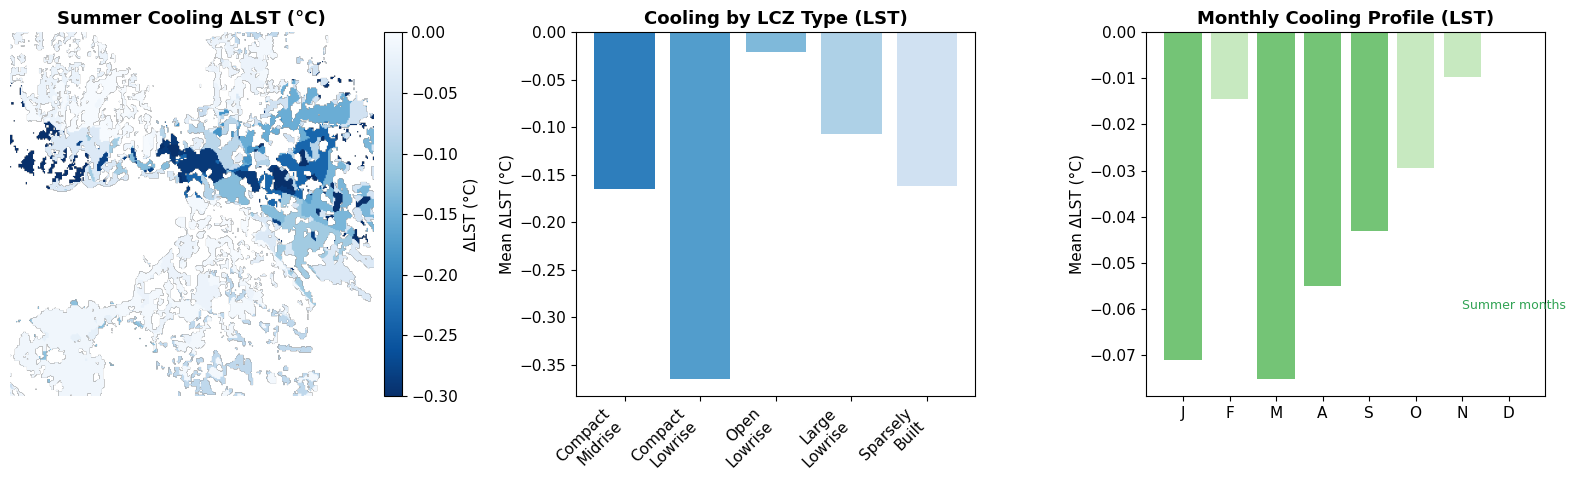

In [28]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pyplot as plt

# Restrict the LCZ summary to the codes present in the coefficient table
available_lcz = sorted(coef_city["lcz"].dropna().unique().astype(int))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Map of the summer-average LST cooling field
ax1 = axes[0]
dt_plot = np.where(SCOPE_PHYS & (dLST_summer < 0), dLST_summer, np.nan)
im1 = ax1.imshow(dt_plot, cmap='Blues_r', vmin=-0.3, vmax=0)
ax1.set_title('Summer Cooling ΔLST (°C)', fontweight='bold')
ax1.axis('off')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="5%", pad=0.1)
plt.colorbar(im1, cax=cax1, label='ΔLST (°C)')

# 2. Mean cooling by LCZ class
ax2 = axes[1]
lcz_names = {2: 'Compact\nMidrise', 3: 'Compact\nLowrise', 4: 'Open\nHighrise',
             5: 'Open\nMidrise', 6: 'Open\nLowrise', 8: 'Large\nLowrise', 9: 'Sparsely\nBuilt'}
lcz_dt = []
lcz_labels = []
for lcz_code in sorted(available_lcz):
    mask = (lcz_on_ref == lcz_code) & SCOPE_PHYS & (dLST_summer < 0)
    if mask.sum() > 0:
        mean_dt = dLST_summer[mask].mean()
        lcz_dt.append(mean_dt)
        lcz_labels.append(lcz_names.get(lcz_code, f'LCZ {lcz_code}'))

colors = plt.cm.Blues_r(np.linspace(0.3, 0.8, len(lcz_dt)))
ax2.bar(range(len(lcz_dt)), lcz_dt, color=colors)
ax2.set_xticks(range(len(lcz_dt)))
ax2.set_xticklabels(lcz_labels, rotation=45, ha='right')
ax2.set_ylabel('Mean ΔLST (°C)')
ax2.set_title('Cooling by LCZ Type (LST)', fontweight='bold')
ax2.axhline(0, color='black', linewidth=0.5)

# 3. Citywide monthly cooling profile
ax3 = axes[2]
monthly_dt_city = [float(dLST_monthly[m-1][SCOPE_PHYS].mean()) for m in range(1, 13)]
months = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
colors_monthly = ['#74c476' if m in SUMMER_MONTHS else '#c7e9c0' for m in range(1, 13)]
ax3.bar(months, monthly_dt_city, color=colors_monthly)
ax3.axhline(0, color='black', linewidth=0.5)
ax3.set_ylabel('Mean ΔLST (°C)')
ax3.set_title('Monthly Cooling Profile (LST)', fontweight='bold')
ax3.annotate('Summer months', xy=(6, min(monthly_dt_city)*0.8), fontsize=9, color='#31a354')

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_cooling_effect.png", dpi=150, bbox_inches='tight')
print(f"Saved: {OUT / f'{SLUG}_cooling_effect.png'}")
plt.show()

### 3.4 Hazard and AC Inputs for the Mortality Runs

The mortality comparison reuses the daily T2M hazard from `NB03` and the baseline/policy AC coverage from `NB05`. That is what makes the vegetation results directly comparable to the AC results and to the combined-policy scenario.


The baseline throughout this section is **current AC with no trees**, not a no-adaptation world. Vegetation benefits are therefore measured relative to the residual heat burden after baseline AC protection is already in place.


In [29]:
# Reuse the daily T2M hazard saved earlier in the workflow
from climada.hazard import Hazard

haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
H = Hazard.from_hdf5(haz_path)

# Restore the daily calendar so cooling can be applied day by day
events_csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
if events_csv.exists():
    ev_df = pd.read_csv(events_csv)
    H.event_id = ev_df["event_id"].to_numpy(int)
    H.date = pd.to_datetime(ev_df["date"]).to_numpy("datetime64[ns]")
    H.event_name = np.array([f"T2M_{d}" for d in ev_df["date"]], dtype=object)
    
    def days_in_year(y):
        return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365
    yrs = pd.to_datetime(ev_df["date"]).dt.year.to_numpy(int)
    H.frequency = np.array([1.0 / days_in_year(y) for y in yrs], dtype=float)

H.haz_type = "T2M"
H.units = "degC (daily mean)"

dates_h = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
YEARS_H = sorted(dates_h.dt.year.unique().astype(int).tolist())
print(f"Hazard loaded: {H.intensity.shape[0]} events, years {YEARS_H}")

# Load baseline and policy AC coverage from NB5 so trees can be compared to AC on the same footing
# Search both current and legacy save locations for the AC outputs
_ac_candidates = [
    OUT / f"ac_coverage_maps_{SLUG}.npz",
    INT / f"ac_coverage_maps_{SLUG}.npz",
    INT / "ac_coverage_maps.npz",
]
ac_maps_path = next((p for p in _ac_candidates if p.exists()), None)

if ac_maps_path is None:
    raise FileNotFoundError(
        f"AC coverage maps not found. Searched:\n" +
        "\n".join(f"  {p}" for p in _ac_candidates)
    )

npz = np.load(ac_maps_path)
print(f"Loaded: {ac_maps_path.name}")
print(f"Keys: {npz.files}")

# Prefer the AC efficacy metadata saved by NB5; if missing, rebuild it from the current config.
eff_cfg_default = float((cfg.get("efficacy", {}) or {}).get("default", 0.30))
EFF_DEFAULT = float(np.atleast_1d(npz["EFF_DEFAULT"])[0]) if "EFF_DEFAULT" in npz.files else eff_cfg_default
EFF_MAP = {"default": EFF_DEFAULT}

_saved_bucket_keys = {
    "<15": "EFF_BUCKETS_LT15",
    "15-64": "EFF_BUCKETS_15_64",
    "65+": "EFF_BUCKETS_65P",
}
for age_lbl, key in _saved_bucket_keys.items():
    if key in npz.files:
        EFF_MAP[age_lbl] = float(np.atleast_1d(npz[key])[0])

if any(age_lbl not in EFF_MAP for age_lbl in ["<15", "15-64", "65+"]):
    eff_scenario = globals().get("EFF_SCENARIO", "moderate")
    scenarios = cfg.get("efficacy_scenarios", {}) or {}
    if eff_scenario in scenarios:
        eff_cfg = {k: float(v) for k, v in scenarios[eff_scenario].items()}
    else:
        eff_cfg = {k: float(v) for k, v in (cfg.get("efficacy", {}) or {}).items() if k != "default"}

    for age_lbl in ["<15", "15-64", "65+"]:
        if age_lbl in eff_cfg:
            EFF_MAP.setdefault(age_lbl, float(eff_cfg[age_lbl]))

for age_lbl in ["<15", "15-64", "65+"]:
    EFF_MAP.setdefault(age_lbl, EFF_DEFAULT)

print(f"EFF_MAP (aligned with NB5): {EFF_MAP}")


def get_eff_for_age(age_label):
    """Get AC efficacy for age group (aligned with NB5)."""
    if age_label in EFF_MAP:
        return float(EFF_MAP[age_label])
    for k, v in EFF_MAP.items():
        if k == "default":
            continue
        if k in str(age_label):
            return float(v)
    return float(EFF_DEFAULT)

# Support either year-specific cubes or single coverage maps saved in legacy runs
cov_base_raw = npz["coverage_base_3d"] if "coverage_base_3d" in npz.files else npz.get("coverage_base")
cov_policy_raw = npz["coverage_policy_3d"] if "coverage_policy_3d" in npz.files else npz.get("coverage_policy")

# Resolve the years associated with the saved AC coverage cubes
if "YEARS_AC" in npz.files:
    YEARS_AC = npz["YEARS_AC"].astype(int).tolist()
elif "years" in npz.files:
    YEARS_AC = npz["years"].astype(int).tolist()
else:
    YEARS_AC = YEARS_H


def _build_cov_by_year(arr, years_in_file):
    """Convert a 2D or 3D coverage array to a {year: 2D grid} dict without zero-filling city holes."""
    if arr is None:
        return {int(y): np.zeros((HGT, WDT), dtype="float32") for y in YEARS_H}
    if arr.ndim == 2:
        # Same 2D map for all hazard years
        return {int(y): arr.astype("float32").copy() for y in YEARS_H}
    if arr.ndim == 3:
        assert years_in_file is not None, "3D coverage cube but missing YEARS_AC in NPZ"
        assert arr.shape[0] == len(years_in_file), f"cube length {arr.shape[0]} != YEARS_AC length {len(years_in_file)}"
        return {int(y): arr[i].astype("float32").copy() for i, y in enumerate(years_in_file)}
    raise ValueError(f"Unexpected coverage array dim {arr.ndim}")


coverage_base_by_year = _build_cov_by_year(cov_base_raw, YEARS_AC)
coverage_policy_by_year = _build_cov_by_year(cov_policy_raw, YEARS_AC)

print(f"Coverage base years: {sorted(coverage_base_by_year.keys())}")
print(f"Coverage policy years: {sorted(coverage_policy_by_year.keys())}")
print(f"Base grid shape: {next(iter(coverage_base_by_year.values())).shape}")


Hazard loaded: 1462 events, years [2020, 2030, 2040, 2050]
Loaded: ac_coverage_maps_rome.npz
Keys: ['years', 'coverage_base_3d', 'EFF_DEFAULT', 'EFF_BUCKETS_LT15', 'EFF_BUCKETS_15_64', 'EFF_BUCKETS_65P', 'coverage_policy_3d', 'coverage_uniform_3d']
EFF_MAP (aligned with NB5): {'default': 0.30000001192092896, '<15': 0.20000000298023224, '15-64': 0.30000001192092896, '65+': 0.4000000059604645}
Coverage base years: [2020, 2030, 2040, 2050]
Coverage policy years: [2020, 2030, 2040, 2050]
Base grid shape: (301, 301)


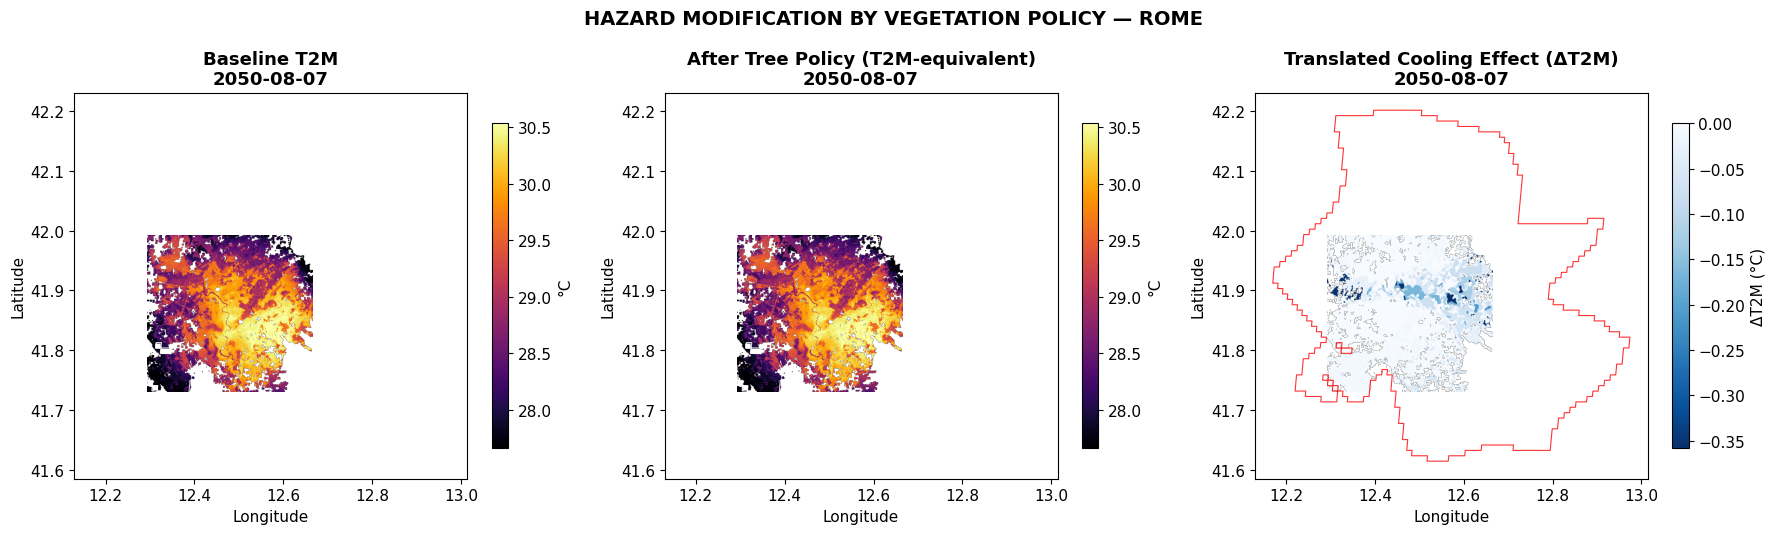


Focus date: 2050-08-07 (hottest summer day in 2050)
Baseline mean T2M: 29.212°C
After-trees mean T2M: 29.187°C
Mean translated cooling (ΔT2M): -0.0251°C
Max translated cooling (ΔT2M): -0.7934°C
Mean raw ΔLST used: -0.0378°C
Median local slope dLST/dT2M: 1.5493

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/rome_hazard_before_after.png


In [30]:
# Diagnostic figure showing how the translated tree cooling modifies the daily T2M field

# Re-declare the helper locally for this self-contained diagnostic block
def _row_to_grid(intensity, i_ev, grid_shape):
    """Extract intensity for one event and reshape to grid."""
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()
    expected = grid_shape[0] * grid_shape[1]
    if row.size == expected:
        return row.reshape(grid_shape)
    if row.size == 1:
        return np.full(grid_shape, row[0], dtype=float)
    raise ValueError(f"Row size {row.size} != grid cells {expected} and != 1")

# Select a hot-day snapshot for the hazard diagnostic figure
dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
FOCUS_YEAR = 2050

# Use the hottest July/August day in the focus year
year_mask = dates.dt.year == FOCUS_YEAR
summer_mask = dates.dt.month.isin([7, 8])
combined_mask = year_mask & summer_mask
summer_indices_h = np.where(combined_mask)[0]

if len(summer_indices_h) > 0:
    # Get mean temperature for each summer day
    summer_temps = []
    for idx in summer_indices_h:
        I_grid = _row_to_grid(H.intensity, idx, MASK_POLICY.shape)
        summer_temps.append(np.nanmean(I_grid[MASK_POLICY]))

    # Pick the hottest day
    hottest_idx = summer_indices_h[np.argmax(summer_temps)]
    focus_date = pd.Timestamp(dates.iloc[hottest_idx]).strftime("%Y-%m-%d")

    # Extract baseline T2M hazard for this day
    I_base = _row_to_grid(H.intensity, hottest_idx, MASK_POLICY.shape)
    I_base_m = np.where(MASK_POLICY, I_base, np.nan)

    # Monthly raw LST cooling for that month
    focus_month = pd.Timestamp(dates.iloc[hottest_idx]).month
    dLST_focus = dLST_monthly[focus_month - 1]

    # Translate LST cooling -> T2M-equivalent cooling for this specific day
    dT2M_focus, slope_focus = translate_dlst_to_dt2m(
        t2m_grid=I_base,
        dLST_grid=dLST_focus,
        lcz_grid=lcz_on_ref,
        out_b_grid=out_b_on_ref,
        emu=EMU,
        scope_mask=SCOPE_PHYS
    )

    # Apply translated cooling to T2M hazard
    I_tree = I_base + dT2M_focus
    I_tree_m = np.where(MASK_POLICY, I_tree, np.nan)

    # Difference in T2M space
    dT_map = I_tree_m - I_base_m

    # Compute extent in lon/lat for nice axes
    left = ref_transform.c
    top = ref_transform.f
    right = left + ref_transform.a * WDT
    bottom = top + ref_transform.e * HGT

    # Transform corners to WGS84
    from pyproj import Transformer
    transformer = Transformer.from_crs(ref_crs, "EPSG:4326", always_xy=True)
    lon_min, lat_min = transformer.transform(left, bottom)
    lon_max, lat_max = transformer.transform(right, top)
    extent = [lon_min, lon_max, lat_min, lat_max]

    # Load FUA boundary
    fua_ref = gpd.read_file(fua_gpkg, layer="fua").to_crs(ref_crs)
    fua_4326 = fua_ref.to_crs("EPSG:4326")

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    vmin, vmax = np.nanpercentile(I_base_m, [2, 98])

    # Use translated T2M cooling range for color limits
    cool_vals = dT_map[MASK_POLICY & np.isfinite(dT_map)]
    cool_vmin = float(np.nanpercentile(cool_vals, 1)) if cool_vals.size else -0.3
    cool_vmin = min(cool_vmin, -0.01)  # ensure visible scale
    cool_vmax = 0.0

    # 1. Baseline hazard
    ax1 = axes[0]
    im1 = ax1.imshow(I_base_m, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
    fua_4326.boundary.plot(ax=ax1, color="white", linewidth=0.8, alpha=0.8)
    ax1.set_title(f"Baseline T2M\n{focus_date}", fontweight="bold")
    ax1.set_xlabel("Longitude")
    ax1.set_ylabel("Latitude")
    plt.colorbar(im1, ax=ax1, label="°C", shrink=0.8)

    # 2. After trees (translated into T2M space)
    ax2 = axes[1]
    im2 = ax2.imshow(I_tree_m, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
    fua_4326.boundary.plot(ax=ax2, color="white", linewidth=0.8, alpha=0.8)
    ax2.set_title(f"After Tree Policy (T2M-equivalent)\n{focus_date}", fontweight="bold")
    ax2.set_xlabel("Longitude")
    ax2.set_ylabel("Latitude")
    plt.colorbar(im2, ax=ax2, label="°C", shrink=0.8)

    # 3. Cooling effect in translated T2M space
    ax3 = axes[2]
    im3 = ax3.imshow(dT_map, origin="upper", extent=extent, vmin=cool_vmin, vmax=cool_vmax, cmap="Blues_r")
    fua_4326.boundary.plot(ax=ax3, color="red", linewidth=0.8, alpha=0.8)
    ax3.set_title(f"Translated Cooling Effect (ΔT2M)\n{focus_date}", fontweight="bold")
    ax3.set_xlabel("Longitude")
    ax3.set_ylabel("Latitude")
    plt.colorbar(im3, ax=ax3, label="ΔT2M (°C)", shrink=0.8)

    plt.suptitle(
        f"HAZARD MODIFICATION BY VEGETATION POLICY — {CITY.upper()}",
        fontsize=14,
        fontweight="bold",
        y=1.02
    )
    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_hazard_before_after.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nFocus date: {focus_date} (hottest summer day in {FOCUS_YEAR})")
    print(f"Baseline mean T2M: {np.nanmean(I_base_m):.3f}°C")
    print(f"After-trees mean T2M: {np.nanmean(I_tree_m):.3f}°C")
    print(f"Mean translated cooling (ΔT2M): {np.nanmean(dT_map[MASK_POLICY]):.4f}°C")
    print(f"Max translated cooling (ΔT2M): {np.nanmin(dT_map[MASK_POLICY]):.4f}°C")
    print(f"Mean raw ΔLST used: {np.nanmean(dLST_focus[MASK_POLICY]):.4f}°C")
    print(f"Median local slope dLST/dT2M: {np.nanmedian(slope_focus[MASK_POLICY]):.4f}")
    print(f"\nSaved: {OUT / f'{SLUG}_hazard_before_after.png'}")

else:
    print(f"[WARN] No summer days found for year {FOCUS_YEAR}")

### 3.5 Impact Functions from `NB04`

The notebook loads the year-specific scaled impact functions generated in `NB04`. It does not recalibrate or respecify them here.


This keeps the vegetation pathway on exactly the same mortality-response basis as the AC and EWS pathways.


In [31]:
# Load the year-specific scaled impact functions produced in NB4
import json
from pathlib import Path
from climada.entity.impact_funcs import ImpactFunc

def _mk_if(haz_type: str, v: dict) -> ImpactFunc:
    """Create ImpactFunc from dict with id, intensity, mdd, name."""
    f = ImpactFunc(
        haz_type=haz_type,
        id=int(v["id"]),
        intensity=np.asarray(v["intensity"], float),
        mdd=np.asarray(v["mdd"], float),  # Already SCALED in NB4 output
        paa=np.ones(len(v["intensity"]), float),
        name=v.get("name", "IF"),
    )
    f.check()
    return f

def load_scaled_ifs_by_year_nb4(interim_path, slug, haz_type="T2M"):
    """
    Load NB4's year-specific SCALED MDD bundle.
    Expected file: if_curves_by_year_{slug}.json
    """
    interim_path = Path(interim_path)
    path = interim_path / f"if_curves_by_year_{slug}.json"
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path.name} in {interim_path}.\n"
            "Re-run NB4 and save the YEAR-SPECIFIC SCALED IF bundle."
        )
    
    with open(path, "r") as fh:
        obj = json.load(fh)
    
    raw = obj.get("ifs_by_year", {})
    if not raw:
        raise ValueError(f"{path.name} has no 'ifs_by_year'.")
    
    ifs_by_year = {}
    for y_key, d in raw.items():
        y = int(y_key)
        ifs_by_year[y] = {age: _mk_if(haz_type, v) for age, v in d.items()}
    
    meta = {
        "reference_year": obj.get("reference_year", None),
        "years": obj.get("years", sorted(ifs_by_year.keys())),
        "scaling_source": obj.get("scaling_source", None),
    }
    
    return ifs_by_year, path, meta

# Initialize the impact-function lookup used in the scenario runs
IFS_BY_YEAR, IF_SRC, IF_META = load_scaled_ifs_by_year_nb4(INT, SLUG, haz_type="T2M")
print(f" Loaded SCALED IFs from: {IF_SRC.name}")
print(f"  Years: {sorted(IFS_BY_YEAR.keys())}")
print(f"  Age groups: {list(IFS_BY_YEAR[list(IFS_BY_YEAR.keys())[0]].keys())}")
print(f"  Meta: {IF_META}")

def get_age_ifs_for_year(year: int):
    """Get age-specific impact functions for a given year."""
    year = int(year)
    if year not in IFS_BY_YEAR:
        raise KeyError(f"No SCALED IFs for year {year}. Available: {sorted(IFS_BY_YEAR.keys())}")
    return IFS_BY_YEAR[year]

 Loaded SCALED IFs from: if_curves_by_year_rome.json
  Years: [2020, 2030, 2040, 2050]
  Age groups: ['<15', '15-64', '65+']
  Meta: {'reference_year': 2020, 'years': [2020, 2030, 2040, 2050], 'scaling_source': 'Wittgenstein ASSR baseline mortality'}


### 3.6 Mortality Model

The death engine applies the temperature field, the year-specific impact functions, and the relevant AC coverage to compute annual deaths by age group. The only thing that changes across scenarios is the temperature offset and/or the AC coverage map.


Because the same mortality function is used in all scenarios, the scenario comparison isolates the incremental role of trees, AC expansion, and their combination.


In [32]:
# Shared death engine for the baseline, trees, AC, and combined scenarios

def _eff_for_age(age_lbl, eff_map=EFF_MAP, eff_default=EFF_DEFAULT):
    """Get AC efficacy for age group."""
    if age_lbl in eff_map:
        return float(eff_map[age_lbl])
    for k, v in eff_map.items():
        if k == "default":
            continue
        if k in str(age_lbl):
            return float(v)
    return float(eff_default)


def annual_deaths_with_ac_and_dT(
    H,
    dT_monthly,
    coverage_by_year,
    age_by_year,
    pop_by_year,
    mask=None,
    use_emulator=False,
    emu=None,
    lcz_grid=None,
    out_b_grid=None
):
    """
    Annual heat deaths per age group, applying monthly temperature offsets and AC coverage.

    Parameters
    ----------
    H : Hazard object
    dT_monthly : array
        Either:
        - (12, H, W) monthly cooling grids
        - (H, W) fixed cooling grid
    use_emulator : bool
        If True, interpret dT_monthly as monthly ΔLST and translate to ΔT2M
        day-by-day using the emulator.
    """
    dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
    years = np.sort(np.unique(dates.dt.year.astype(int)))

    age_labels = list(get_age_ifs_for_year(int(years[0])).keys())

    if mask is None:
        mask = globals().get("MASK_POLICY", globals().get("mask"))
    mask = mask.astype(bool)

    grid_shape = mask.shape
    totals = {a: pd.Series(0.0, index=years, dtype=float) for a in age_labels}

    if dT_monthly.ndim == 3:
        use_monthly = True
    else:
        use_monthly = False
        dT_fixed = dT_monthly

    for i_ev, d in enumerate(dates):
        y = int(d.year)
        age_ifs_y = get_age_ifs_for_year(y)

        cov_y = coverage_by_year.get(y)
        if cov_y is None:
            raise KeyError(f"No AC coverage for year {y}")
        cov_y = cov_y.astype(float)

        pop_y = np.nan_to_num(pop_by_year[y], 0.0)
        m_pop = mask & np.isfinite(pop_y)

        I_grid = _row_to_grid(H.intensity, i_ev, grid_shape)

        # get raw offset for this day/month
        if use_monthly:
            month_idx = d.month - 1
            dT_raw = dT_monthly[month_idx]
        else:
            dT_raw = dT_fixed

        # translate if needed
        if use_emulator:
            if emu is None or lcz_grid is None or out_b_grid is None:
                raise ValueError("When use_emulator=True, emu/lcz_grid/out_b_grid must be provided.")
            dT_offset, _ = translate_dlst_to_dt2m(
                t2m_grid=I_grid,
                dLST_grid=dT_raw,
                lcz_grid=lcz_grid,
                out_b_grid=out_b_grid,
                emu=emu,
                scope_mask=mask
            )
        else:
            dT_offset = dT_raw

        I_policy = I_grid + dT_offset
        m_city = m_pop & np.isfinite(I_grid)
        if not np.any(m_city):
            continue

        # Match NB05: fill any remaining coverage holes inside the modeled city with a pop-weighted city mean.
        cov_grid = np.where(m_pop & np.isfinite(cov_y), cov_y, np.nan)
        if np.isnan(cov_grid[m_city]).any():
            w = pop_y[m_city].astype(float)
            x = np.nan_to_num(cov_grid[m_city], nan=0.0).astype(float)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)
        cov = np.where(m_city, cov_grid, 0.0)

        for age_lbl in age_labels:
            f = age_ifs_y[age_lbl]
            mdd = np.interp(I_policy, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
            eff_a = _eff_for_age(age_lbl)
            mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
            pop_a_grid = np.nan_to_num(age_by_year[y][age_lbl], 0.0)
            totals[age_lbl].loc[y] += float(np.nansum(np.where(m_city, pop_a_grid * mdd * mult, 0.0)))

    yr_totals = pd.DataFrame(totals).sort_index()
    yr_totals["overall"] = yr_totals[age_labels].sum(axis=1)

    age_pops = {
        int(y): {
            a: float(np.nansum(np.nan_to_num(age_by_year[int(y)][a], 0.0)[mask]))
            for a in age_labels
        }
        for y in years
    }
    city_pop = {int(y): sum(age_pops[int(y)][a] for a in age_labels) for y in years}

    yr_rates = yr_totals.copy()
    for a in age_labels:
        denom = np.array([age_pops[int(y)][a] for y in years], dtype=float)
        yr_rates[a] = np.where(denom > 0, yr_totals[a].to_numpy(float) / denom * 1e5, np.nan)

    denom_all = np.array([city_pop[int(y)] for y in years], dtype=float)
    yr_rates["overall"] = np.where(denom_all > 0, yr_totals["overall"].to_numpy(float) / denom_all * 1e5, np.nan)

    return yr_rates, yr_totals


### 3.7 Four Policy Scenarios

The notebook compares four scenarios on the same hazard years:
1. baseline: current AC, no trees
2. trees only: current AC plus vegetation cooling
3. AC policy only: expanded AC from `NB05`, no trees
4. both policies: expanded AC plus vegetation cooling


This setup allows the notebook to report both the stand-alone benefit of trees and the **incremental benefit of trees on top of AC expansion**.


In [33]:
# Use a zero temperature offset for the scenarios without vegetation cooling
dT_zero = np.zeros((HGT, WDT), dtype="float32")
print("Computing 4 scenarios...")

# 1. Baseline = current AC, no trees
print("  1/4: Baseline (current AC, no trees)...")
yr_rates_base, yr_totals_base = annual_deaths_with_ac_and_dT(
    H, dT_zero, coverage_base_by_year, age_on_ref_by_year, pop_on_ref_by_year,
    mask=MASK_CITY,
    use_emulator=False
)

# 2. Trees only = current AC plus vegetation cooling
print("  2/4: Trees only (current AC + trees)...")
yr_rates_trees, yr_totals_trees = annual_deaths_with_ac_and_dT(
    H, dLST_monthly, coverage_base_by_year, age_on_ref_by_year, pop_on_ref_by_year,
    mask=MASK_CITY,
    use_emulator=True,
    emu=EMU,
    lcz_grid=lcz_on_ref,
    out_b_grid=out_b_on_ref
)

# 3. AC policy only = expanded AC, no trees
print("  3/4: AC policy only (no trees)...")
yr_rates_acpol, yr_totals_acpol = annual_deaths_with_ac_and_dT(
    H, dT_zero, coverage_policy_by_year, age_on_ref_by_year, pop_on_ref_by_year,
    mask=MASK_CITY,
    use_emulator=False
)

# 4. Both policies = expanded AC plus vegetation cooling
print("  4/4: Both policies (AC policy + trees)...")
yr_rates_both, yr_totals_both = annual_deaths_with_ac_and_dT(
    H, dLST_monthly, coverage_policy_by_year, age_on_ref_by_year, pop_on_ref_by_year,
    mask=MASK_CITY,
    use_emulator=True,
    emu=EMU,
    lcz_grid=lcz_on_ref,
    out_b_grid=out_b_on_ref
)

print("\n✓ All scenarios computed.")
print(f"\nBaseline deaths (current AC):\n{yr_totals_base.round(1)}")

print("\nDeaths with trees (current AC):")
print(yr_totals_trees.round(1))

print("\nDeaths with AC policy (no trees):")
print(yr_totals_acpol.round(1))

print("\nDeaths with both policies:")
print(yr_totals_both.round(1))

Computing 4 scenarios...
  1/4: Baseline (current AC, no trees)...
  2/4: Trees only (current AC + trees)...
  3/4: AC policy only (no trees)...
  4/4: Both policies (AC policy + trees)...

✓ All scenarios computed.

Baseline deaths (current AC):
      <15  15-64    65+  overall
2020  2.8   38.2  346.7    387.7
2030  1.7   35.3  426.2    463.1
2040  1.0   22.4  470.0    493.4
2050  0.6   14.7  554.0    569.3

Deaths with trees (current AC):
      <15  15-64    65+  overall
2020  2.8   37.4  340.5    380.7
2030  1.6   34.6  419.0    455.3
2040  1.0   22.0  462.2    485.1
2050  0.6   14.5  545.0    560.0

Deaths with AC policy (no trees):
      <15  15-64    65+  overall
2020  2.8   37.0  330.7    370.5
2030  1.6   34.2  407.4    443.2
2040  1.0   21.8  452.5    475.3
2050  0.6   14.3  533.4    548.3

Deaths with both policies:
      <15  15-64    65+  overall
2020  2.7   36.3  324.9    363.9
2030  1.6   33.6  400.6    435.9
2040  0.9   21.4  445.2    467.5
2050  0.5   14.1  524.9    539

### 3.8 Avoided-Deaths Summary

The avoided-deaths tables below are all calculated relative to the **current-AC baseline**. This is the benchmark that should be kept in mind when reading the vegetation results.


In [34]:
# Compare each scenario back to the current-AC baseline
print("\n" + "="*80)
print("AVOIDED DEATHS SUMMARY")
print("="*80)

# Avoided deaths from trees alone relative to the current-AC baseline
avo_trees = yr_totals_base - yr_totals_trees
avo_trees.columns = [f"avo_{c}" for c in avo_trees.columns]

# Avoided deaths from AC expansion alone relative to the current-AC baseline
avo_ac = yr_totals_base - yr_totals_acpol
avo_ac.columns = [f"avo_{c}" for c in avo_ac.columns]

# Avoided deaths from the combined policy relative to the current-AC baseline
avo_both = yr_totals_base - yr_totals_both
avo_both.columns = [f"avo_{c}" for c in avo_both.columns]

# Incremental tree benefit once AC expansion is already in place
avo_trees_cond = yr_totals_acpol - yr_totals_both
avo_trees_cond.columns = [f"avo_{c}" for c in avo_trees_cond.columns]

print("\n--- Avoided by Trees Only (vs current AC baseline) ---")
print(avo_trees.round(2))

print("\n--- Avoided by AC Policy Only (vs current AC baseline) ---")
print(avo_ac.round(2))

print("\n--- Avoided by Both Policies (vs current AC baseline) ---")
print(avo_both.round(2))

print("\n--- Incremental Benefit of Trees (given AC policy) ---")
print(avo_trees_cond.round(2))

# Compact overall comparison table
print("\n--- Summary: Overall Avoided Deaths ---")
summary = pd.DataFrame({
    "baseline": yr_totals_base["overall"],
    "trees_only": yr_totals_trees["overall"],
    "ac_policy_only": yr_totals_acpol["overall"],
    "both_policies": yr_totals_both["overall"],
    "avo_trees": avo_trees["avo_overall"],
    "avo_ac": avo_ac["avo_overall"],
    "avo_both": avo_both["avo_overall"],
    "avo_trees_cond": avo_trees_cond["avo_overall"],
})
print(summary.round(2))


AVOIDED DEATHS SUMMARY

--- Avoided by Trees Only (vs current AC baseline) ---
      avo_<15  avo_15-64  avo_65+  avo_overall
2020     0.05       0.71     6.25         7.01
2030     0.02       0.64     7.21         7.87
2040     0.01       0.40     7.82         8.23
2050     0.01       0.26     9.03         9.30

--- Avoided by AC Policy Only (vs current AC baseline) ---
      avo_<15  avo_15-64  avo_65+  avo_overall
2020     0.05       1.19    16.00        17.25
2030     0.03       1.05    18.85        19.93
2040     0.01       0.56    17.51        18.09
2050     0.01       0.37    20.65        21.03

--- Avoided by Both Policies (vs current AC baseline) ---
      avo_<15  avo_15-64  avo_65+  avo_overall
2020     0.10       1.87    21.82        23.79
2030     0.05       1.66    25.58        27.29
2040     0.03       0.95    24.87        25.85
2050     0.02       0.62    29.15        29.79

--- Incremental Benefit of Trees (given AC policy) ---
      avo_<15  avo_15-64  avo_65+  avo_o

### 3.9 Scenario Diagnostics

These figures compare the deaths and avoided deaths produced by the four scenarios over time.


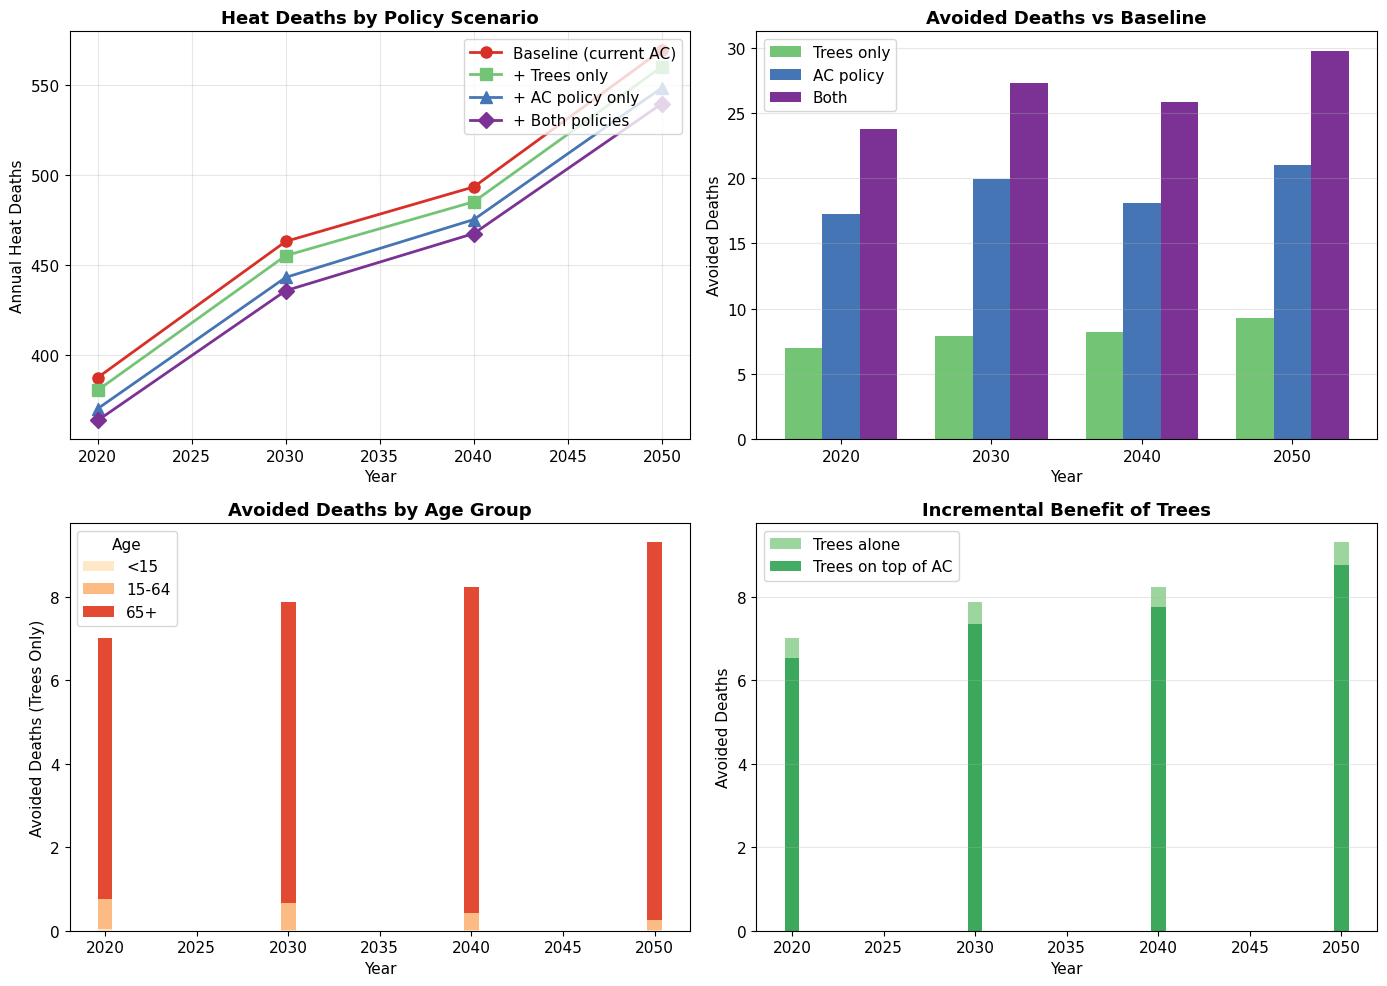

In [35]:
# Diagnostic figures for deaths and avoided deaths across scenarios
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Death totals by scenario over time
ax1 = axes[0, 0]
years = yr_totals_base.index.tolist()
ax1.plot(years, yr_totals_base['overall'], 'o-', label='Baseline (current AC)', 
         color='#d73027', linewidth=2, markersize=8)
ax1.plot(years, yr_totals_trees['overall'], 's-', label='+ Trees only', 
         color='#74c476', linewidth=2, markersize=8)
ax1.plot(years, yr_totals_acpol['overall'], '^-', label='+ AC policy only', 
         color='#4575b4', linewidth=2, markersize=8)
ax1.plot(years, yr_totals_both['overall'], 'D-', label='+ Both policies', 
         color='#7b3294', linewidth=2, markersize=8)
ax1.set_xlabel('Year')
ax1.set_ylabel('Annual Heat Deaths')
ax1.set_title('Heat Deaths by Policy Scenario', fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# 2. Overall avoided-death comparison
ax2 = axes[0, 1]
x = np.arange(len(years))
width = 0.25
ax2.bar(x - width, avo_trees['avo_overall'], width, label='Trees only', color='#74c476')
ax2.bar(x, avo_ac['avo_overall'], width, label='AC policy', color='#4575b4')
ax2.bar(x + width, avo_both['avo_overall'], width, label='Both', color='#7b3294')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.set_xlabel('Year')
ax2.set_ylabel('Avoided Deaths')
ax2.set_title('Avoided Deaths vs Baseline', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# 3. Tree-only avoided deaths by age group
ax3 = axes[1, 0]
age_cols = ['avo_<15', 'avo_15-64', 'avo_65+']
age_labels = ['<15', '15-64', '65+']
age_colors = ['#fee8c8', '#fdbb84', '#e34a33']

bottom = np.zeros(len(years))
for col, label, color in zip(age_cols, age_labels, age_colors):
    vals = avo_trees[col].values
    ax3.bar(years, vals, bottom=bottom, label=label, color=color)
    bottom += vals

ax3.set_xlabel('Year')
ax3.set_ylabel('Avoided Deaths (Trees Only)')
ax3.set_title('Avoided Deaths by Age Group', fontweight='bold')
ax3.legend(title='Age')

# 4. Marginal tree benefit with and without AC expansion
ax4 = axes[1, 1]
ax4.bar(years, avo_trees['avo_overall'], label='Trees alone', color='#74c476', alpha=0.7)
ax4.bar(years, avo_trees_cond['avo_overall'], label='Trees on top of AC', 
        color='#31a354', alpha=0.9)
ax4.set_xlabel('Year')
ax4.set_ylabel('Avoided Deaths')
ax4.set_title('Incremental Benefit of Trees', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_avoided_deaths.png", dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# Keep the main scenario tables available for the later sections
tables = {
    "yr_totals_base": yr_totals_base,
    "yr_totals_trees": yr_totals_trees,
    "yr_totals_acpol": yr_totals_acpol,
    "yr_totals_both": yr_totals_both,
    "yr_rates_base": yr_rates_base,
    "yr_rates_trees": yr_rates_trees,
    "yr_rates_acpol": yr_rates_acpol,
    "yr_rates_both": yr_rates_both,
    "avo_trees": avo_trees,
    "avo_ac": avo_ac,
    "avo_both": avo_both,
    "avo_trees_cond": avo_trees_cond,
}

print(f"\nStored {len(tables)} tables for downstream analysis.")


Stored 12 tables for downstream analysis.


## 4. Equity Analysis

The main vegetation policy is the uniform Q3 catch-up allocation. This section adds an equity lens by checking how the benefits line up with the spatial vulnerability layer and by testing an SVI-weighted reallocation that preserves the same total greening budget.


Equity diagnostics only run if the vulnerability layer prepared upstream is available for the city.


In [37]:
# Load the vulnerability layer for the notebook focus year/scenario so the
# equity analysis uses the same projected SVI surface as the rest of the workflow.
from cityheat.vulnerability_layer import load_vulnerability

SVI_FOCUS_YEAR = max(YEARS_H)
SVI_FOCUS_SCENARIO = None if SVI_FOCUS_YEAR <= 2030 else SCEN_CODE


def load_svi_grid_for_year(year, scenario=SCEN_CODE):
    year = int(year)
    scenario_arg = None if year <= 2030 else scenario
    try:
        return load_vulnerability(INT, SLUG, year=year, scenario=scenario_arg)["svi"]
    except FileNotFoundError:
        if year != 2020:
            try:
                return load_vulnerability(INT, SLUG, year=2020)["svi"]
            except FileNotFoundError:
                pass
        return load_vulnerability(INT, SLUG)["svi"]

try:
    svi_on_ref = load_svi_grid_for_year(SVI_FOCUS_YEAR, scenario=SVI_FOCUS_SCENARIO)
    HAS_VULN = True
    valid_svi = MASK_POLICY & np.isfinite(svi_on_ref)
    print(f"SVI loaded for year {SVI_FOCUS_YEAR} ({SVI_FOCUS_SCENARIO or 'direct'}). Valid pixels: {valid_svi.sum():,}")
    print(f"SVI range: {svi_on_ref[valid_svi].min():.3f} – {svi_on_ref[valid_svi].max():.3f}")
except FileNotFoundError:
    HAS_VULN = False
    svi_on_ref = None
    print("SVI data not found. Skipping equity analysis.")

print(f"HAS_VULN: {HAS_VULN}")


SVI loaded for year 2050 (SSP2). Valid pixels: 68,600
SVI range: 0.053 – 0.825
HAS_VULN: True


## Reminder: Dynamic Vulnerability in Vegetation Targeting

The `SVI` used in this notebook is loaded for the **focus year and scenario** of the analysis, rather than from one static baseline surface. Any vulnerability-weighted targeting, benefit summary, or equity diagnostic below therefore reflects the projected vulnerability layer that is consistent with the same future year/scenario as the hazard and population inputs.


### 4.2 SVI by Policy Region

The notebook first aggregates the pixel vulnerability layer to the policy geography using population weights. This gives a region-level SVI summary that can be compared directly with baseline greenness.


In [38]:
# Aggregate population-weighted SVI to the policy geography for the focus year.
if HAS_VULN:
    pop_on_ref_focus = np.nan_to_num(pop_on_ref_by_year.get(SVI_FOCUS_YEAR, pop_on_ref), 0.0)

    def compute_region_svi(svi_grid, region_grid, scope_mask, region_df, pop_grid):
        """Compute pop-weighted SVI by {VEG_REGION_LABEL}."""
        rows = []
        for _, row in region_df.iterrows():
            mid = row["region_id"]
            mname = row["region_name"]
            mask = (region_grid == mid) & scope_mask & np.isfinite(svi_grid)
            if mask.sum() == 0:
                continue
            vals = svi_grid[mask]
            pop = pop_grid[mask]
            svi_popw = np.average(vals, weights=pop) if pop.sum() > 0 else np.nan
            rows.append({
                "region_id": mid,
                "region_name": mname,
                "svi_popw": svi_popw,
            })
        return pd.DataFrame(rows)

    region_svi = compute_region_svi(svi_on_ref, region_on_ref, SCOPE_PHYS, region_gdf, pop_on_ref_focus)

    # Merge with policy_df
    policy_df = policy_df.merge(region_svi[["region_id", "svi_popw"]], on="region_id", how="left")

    print(f"=== SVI by {{VEG_REGION_LABEL}} for {SVI_FOCUS_YEAR} ===")
    print(policy_df[["region_id", "region_name", "gvi_mean", "svi_popw"]].head(10).to_string())


=== SVI by {VEG_REGION_LABEL} for 2050 ===
   region_id          region_name   gvi_mean  svi_popw
0          1     Municipio Roma I  16.389982  0.607816
1          2    Municipio Roma II  19.833924  0.532160
2          3   Municipio Roma III  20.958814  0.472489
3          4    Municipio Roma IV  18.182835  0.494516
4          5     Municipio Roma V  16.397141  0.559740
5          6    Municipio Roma VI  18.434601  0.575538
6          7   Municipio Roma VII  19.070501  0.493925
7          8  Municipio Roma VIII  21.181942  0.490887
8          9    Municipio Roma IX  20.960515  0.461082
9         10     Municipio Roma X  20.777520  0.494745


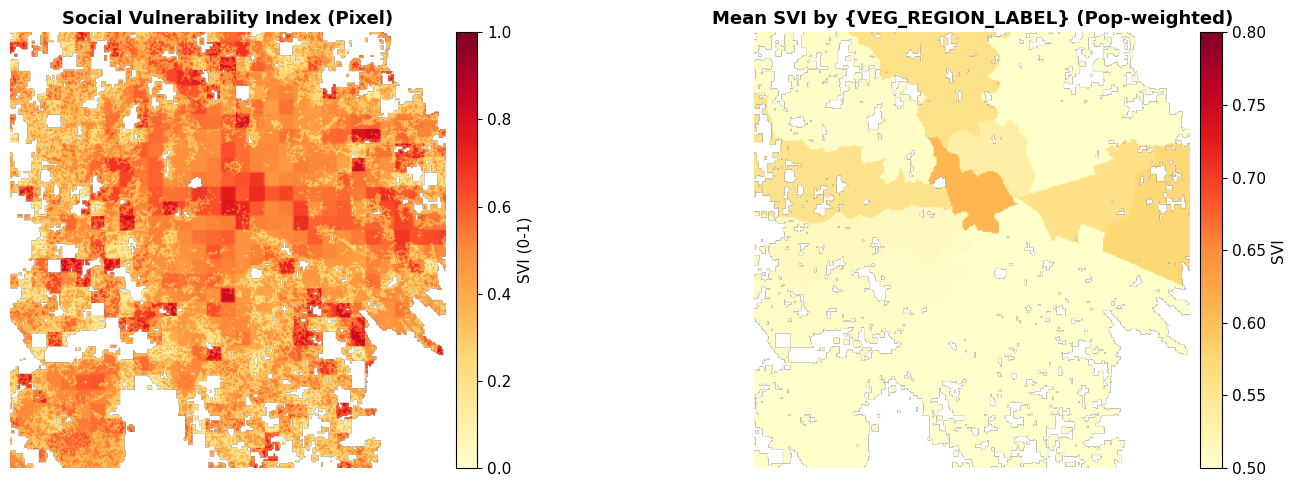

In [39]:
# Diagnostic maps of pixel and regional SVI
if HAS_VULN:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # 1. SVI Raster
    ax1 = axes[0]
    svi_plot = np.where(MASK_POLICY & np.isfinite(svi_on_ref), svi_on_ref, np.nan)
    im1 = ax1.imshow(svi_plot, cmap='YlOrRd', vmin=0, vmax=1)
    ax1.set_title('Social Vulnerability Index (Pixel)', fontweight='bold')
    ax1.axis('off')
    divider1 = make_axes_locatable(ax1)
    cax1 = divider1.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im1, cax=cax1, label='SVI (0-1)')
    
    # 2. SVI by {VEG_REGION_LABEL}
    ax2 = axes[1]
    svi_by_muni = np.full_like(svi_on_ref, np.nan)
    for _, row in policy_df.iterrows():
        mid = int(row["region_id"])
        svi_by_muni[region_on_ref == mid] = row["svi_popw"]
    svi_by_muni = np.where(MASK_POLICY, svi_by_muni, np.nan)
    im2 = ax2.imshow(svi_by_muni, cmap='YlOrRd', vmin=0.5, vmax=0.8)
    ax2.set_title('Mean SVI by {VEG_REGION_LABEL} (Pop-weighted)', fontweight='bold')
    ax2.axis('off')
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im2, cax=cax2, label='SVI')
    
    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_svi_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()

### 4.3 SVI-Weighted Allocation Sensitivity

This is a **sensitivity allocation**, not the main exported policy. The total greening budget is held fixed at the same citywide `ΔGVI` as the uniform policy, but the distribution of that budget is shifted toward regions that are both vulnerable and under-greened.


The purpose is to test whether a more explicitly equity-oriented allocation improves targeting or instead gives up too much cooling and mortality benefit.


In [40]:
# Budget-preserving sensitivity allocation toward vulnerable and under-greened regions

equity_df = None
yr_totals_equity = None
dGVI_map_equity = None
dLST_monthly_eq = None
dLST_summer_eq = None
avo_equity = None

if HAS_VULN and "svi_popw" in policy_df.columns:
    
    TOTAL_BUDGET = float(policy_df["dGVI"].sum())
    
    def allocate_equity_smart(region_df, total_budget):
        """
        Smart equity allocation: prioritize areas with high SVI AND low GVI.
        
        Logic: 
        - Only allocate to areas below target GVI (like uniform)
        - Among those, prioritize by SVI
        """
        df = region_df.copy()
        
        # Identify areas that need greening (below target)
        needs_greening = df["gvi_mean"] < TARGET_GVI
        
        if needs_greening.sum() == 0:
            df["dGVI_equity"] = 0.0
            df["gvi_after_equity"] = df["gvi_mean"]
            return df
        
        # Among areas needing greening, weight by SVI (higher SVI = higher priority)
        df["needs_greening"] = needs_greening
        df["svi_weight"] = np.where(needs_greening, df["svi_popw"], 0.0)
        
        # Normalize weights
        weight_sum = df["svi_weight"].sum()
        if weight_sum > 0:
            df["weight_norm"] = df["svi_weight"] / weight_sum
        else:
            df["weight_norm"] = 0.0
        
        # Allocate budget proportionally to SVI weight (only to needy areas)
        df["dGVI_equity"] = df["weight_norm"] * total_budget
        df["gvi_after_equity"] = df["gvi_mean"] + df["dGVI_equity"]
        
        return df.drop(columns=["needs_greening", "svi_weight", "weight_norm"]).sort_values("region_id").reset_index(drop=True)
    
    # Apply smart equity allocation
    equity_df = allocate_equity_smart(policy_df, TOTAL_BUDGET)
    
    print(f"\n=== Smart Equity Policy (High-SVI among low-GVI areas) ===")
    print(f"Total ΔGVI budget: {TOTAL_BUDGET:.2f} points (same as uniform)")
    print(f"Target GVI: {TARGET_GVI:.2f}")
    
    cols_eq = ["region_id", "region_name", "gvi_mean", "svi_popw", "dGVI", "dGVI_equity"]
    print(equity_df[cols_eq].round(3).to_string(index=False))
    
    # Compare allocations
    print("\n--- Allocation Comparison ---")
    print("{VEG_REGION_LABEL}          | GVI   | SVI   | dGVI_uniform | dGVI_equity")
    print("-" * 65)
    for _, row in equity_df.iterrows():
        print(f"{row['region_name']:18s} | {row['gvi_mean']:5.1f} | {row['svi_popw']:.3f} | {row['dGVI']:12.2f} | {row['dGVI_equity']:.2f}")
    
    # Build equity ΔGVI map
    dgvi_lut_eq = {int(row.region_id): float(row.dGVI_equity) for row in equity_df.itertuples()}
    lut_size = int(region_on_ref.max()) + 1
    dgvi_lut_eq_arr = np.zeros(lut_size, dtype=float)
    for mid, dg in dgvi_lut_eq.items():
        if mid < lut_size:
            dgvi_lut_eq_arr[mid] = dg
    
    dGVI_map_equity = np.where(SCOPE_PHYS, dgvi_lut_eq_arr[region_on_ref], 0.0)
    
    # Compute cooling for equity policy (monthly by LCZ)
    dLST_monthly_eq = compute_monthly_dT(dGVI_map_equity, lcz_on_ref, SCOPE_PHYS, coef_lut)
    dLST_summer_eq = dLST_monthly_eq[summer_indices].mean(axis=0)  # For reporting
    
    dT_equity_popw = compute_popw_mean(dLST_summer_eq, pop_on_ref, SCOPE_PHYS)
    dT_uniform_popw = compute_popw_mean(dLST_summer, pop_on_ref, SCOPE_PHYS)
    
    print(f"\nSummer ΔT (pop-weighted):")
    print(f"  Uniform: {dT_uniform_popw:.4f} °C")
    print(f"  Equity:  {dT_equity_popw:.4f} °C")
    
    # Compute deaths for equity policy (using monthly cooling)
    print("\nComputing equity policy deaths...")
    yr_rates_equity, yr_totals_equity = annual_deaths_with_ac_and_dT(
        H, dLST_monthly_eq, coverage_base_by_year, age_on_ref_by_year, pop_on_ref_by_year,
        mask=MASK_CITY, use_emulator=True, emu=EMU, lcz_grid=lcz_on_ref, out_b_grid=out_b_on_ref
    )
    
    # Avoided deaths comparison
    avo_equity = yr_totals_base - yr_totals_equity
    
    print("\n=== Avoided Deaths: Uniform vs Smart Equity ===")
    comparison = pd.DataFrame({
        "year": yr_totals_base.index,
        "baseline": yr_totals_base["overall"].values,
        "uniform": yr_totals_trees["overall"].values,
        "equity": yr_totals_equity["overall"].values,
        "avo_uniform": avo_trees["avo_overall"].values,
        "avo_equity": avo_equity["overall"].values,
    })
    comparison["diff"] = comparison["avo_equity"] - comparison["avo_uniform"]
    comparison["pct_diff"] = (comparison["diff"] / comparison["avo_uniform"] * 100).round(1)
    print(comparison.round(3).to_string(index=False))
    
    # Update tables dict
    tables["yr_totals_equity"] = yr_totals_equity
    tables["yr_rates_equity"] = yr_rates_equity
    tables["avo_equity"] = avo_equity
    tables["equity_df"] = equity_df
    tables["dGVI_map_equity"] = dGVI_map_equity
    tables["dLST_monthly_eq"] = dLST_monthly_eq   # (full monthly data)
    tables["dLST_summer_eq"] = dLST_summer_eq      # Keep (for reporting/viz)

else:
    print("\n[SKIP] Equity policy not computed (SVI not available)")


=== Smart Equity Policy (High-SVI among low-GVI areas) ===
Total ΔGVI budget: 23.10 points (same as uniform)
Target GVI: 21.30
 region_id         region_name  gvi_mean  svi_popw  dGVI  dGVI_equity
         1    Municipio Roma I    16.390     0.608 4.910        2.249
         2   Municipio Roma II    19.834     0.532 1.466        1.969
         3  Municipio Roma III    20.959     0.472 0.341        1.749
         4   Municipio Roma IV    18.183     0.495 3.117        1.830
         5    Municipio Roma V    16.397     0.560 4.903        2.071
         6   Municipio Roma VI    18.435     0.576 2.865        2.130
         7  Municipio Roma VII    19.071     0.494 2.229        1.828
         8 Municipio Roma VIII    21.182     0.491 0.118        1.817
         9   Municipio Roma IX    20.961     0.461 0.339        1.706
        10    Municipio Roma X    20.778     0.495 0.522        1.831
        11   Municipio Roma XI    23.969     0.505 0.000        0.000
        12  Municipio Roma XII  

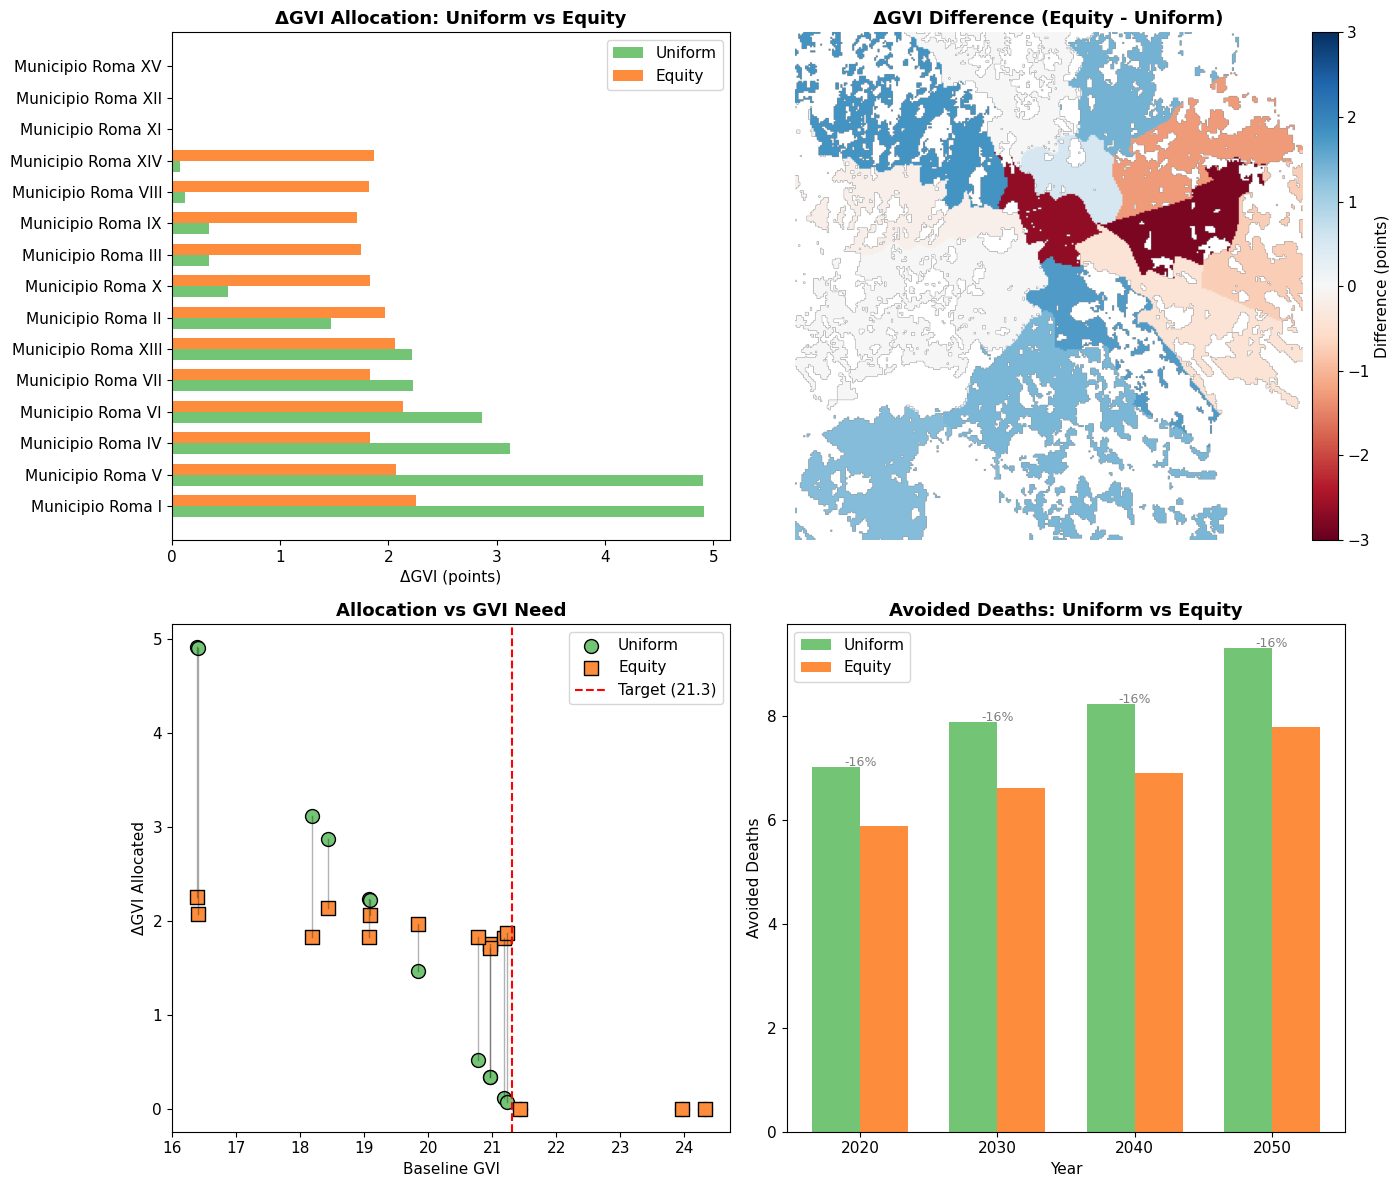

In [41]:
# Compare the main uniform policy with the SVI-weighted sensitivity allocation

if HAS_VULN and equity_df is not None and dGVI_map_equity is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    
    # 1. ΔGVI comparison bar chart
    ax1 = axes[0, 0]
    x = np.arange(len(equity_df))
    width = 0.35
    
    eq_sorted = equity_df.sort_values('dGVI', ascending=False)
    bars1 = ax1.barh(x - width/2, eq_sorted['dGVI'], width, 
                     label='Uniform', color='#74c476')
    bars2 = ax1.barh(x + width/2, eq_sorted['dGVI_equity'], width, 
                     label='Equity', color='#fd8d3c')
    
    ax1.set_yticks(x)
    ax1.set_yticklabels([n.replace('{VEG_REGION_LABEL} Roma ', '') for n in eq_sorted['region_name']])
    ax1.set_xlabel('ΔGVI (points)')
    ax1.set_title('ΔGVI Allocation: Uniform vs Equity', fontweight='bold')
    ax1.legend()
    ax1.axvline(0, color='black', linewidth=0.5)
    
    # 2. Maps comparison - Difference map (Equity - Uniform)
    ax2 = axes[0, 1]
    
    dgvi_diff = dGVI_map_equity - dGVI_map
    dgvi_diff_plot = np.where(SCOPE_PHYS, dgvi_diff, np.nan)
    im2 = ax2.imshow(dgvi_diff_plot, cmap='RdBu', vmin=-3, vmax=3)
    ax2.set_title('ΔGVI Difference (Equity - Uniform)', fontweight='bold')
    ax2.axis('off')
    divider2 = make_axes_locatable(ax2)
    cax2 = divider2.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(im2, cax=cax2, label='Difference (points)')
    
    # 3. Allocation vs Need scatter
    ax3 = axes[1, 0]
    ax3.scatter(equity_df['gvi_mean'], equity_df['dGVI'], s=100, 
                label='Uniform', color='#74c476', edgecolors='black', marker='o')
    ax3.scatter(equity_df['gvi_mean'], equity_df['dGVI_equity'], s=100, 
                label='Equity', color='#fd8d3c', edgecolors='black', marker='s')
    
    # Connect with lines
    for _, row in equity_df.iterrows():
        ax3.plot([row['gvi_mean'], row['gvi_mean']], 
                [row['dGVI'], row['dGVI_equity']], 
                'k-', alpha=0.3, linewidth=1)
    
    ax3.axvline(TARGET_GVI, color='red', linestyle='--', label=f'Target ({TARGET_GVI:.1f})')
    ax3.set_xlabel('Baseline GVI')
    ax3.set_ylabel('ΔGVI Allocated')
    ax3.set_title('Allocation vs GVI Need', fontweight='bold')
    ax3.legend()
    
    # 4. Avoided deaths comparison
    ax4 = axes[1, 1]
    years = yr_totals_base.index.tolist()
    x = np.arange(len(years))
    width = 0.35
    
    ax4.bar(x - width/2, avo_trees['avo_overall'], width, 
            label='Uniform', color='#74c476')
    ax4.bar(x + width/2, avo_equity['overall'], width, 
            label='Equity', color='#fd8d3c')
    
    ax4.set_xticks(x)
    ax4.set_xticklabels(years)
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Avoided Deaths')
    ax4.set_title('Avoided Deaths: Uniform vs Equity', fontweight='bold')
    ax4.legend()
    
    # Add percentage difference
    for i, (u, e) in enumerate(zip(avo_trees['avo_overall'], avo_equity['overall'])):
        pct = (e - u) / u * 100
        ax4.annotate(f'{pct:.0f}%', (i, max(u, e) + 0.02), 
                    ha='center', fontsize=9, color='gray')
    
    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_uniform_vs_equity.png", dpi=150, bbox_inches='tight')
    plt.show()
    
else:
    print("[SKIP] Equity visualization not available (missing data)")

### 4.4 Disparity Analysis

Disparity is assessed on **population-weighted SVI quintiles** in the focus year. The notebook compares baseline death rates and avoided deaths across quintiles for the uniform and equity-weighted tree allocations.


This is where the notebook moves from “who receives greening?” to “who receives the health benefit?”.


In [42]:
# Compare death rates and avoided deaths across population-weighted SVI quintiles
if HAS_VULN and yr_totals_equity is not None:

    print("\n" + "="*80)
    print("DISPARITY ANALYSIS: Deaths by SVI Quintile (Population-Weighted)")
    print("="*80)

    FOCUS_YEAR = SVI_FOCUS_YEAR
    pop_on_ref_focus = np.nan_to_num(pop_on_ref_by_year.get(FOCUS_YEAR, pop_on_ref), 0.0)

    # Build POPULATION-WEIGHTED SVI quintiles for the same focus year as the SVI layer.
    mask_valid = SCOPE_PHYS & np.isfinite(svi_on_ref) & (pop_on_ref_focus > 0)

    rows_valid, cols_valid = np.where(mask_valid)
    svi_flat = svi_on_ref[mask_valid]
    pop_flat = pop_on_ref_focus[mask_valid]

    sort_idx = np.argsort(svi_flat)
    svi_sorted = svi_flat[sort_idx]
    pop_sorted = pop_flat[sort_idx]
    rows_sorted = rows_valid[sort_idx]
    cols_sorted = cols_valid[sort_idx]

    cumsum_pop = np.cumsum(pop_sorted)
    total_pop = cumsum_pop[-1]
    cumfrac = cumsum_pop / total_pop

    quintile_flat = np.zeros(len(svi_sorted), dtype=int)
    for i, frac in enumerate(cumfrac):
        if frac <= 0.2:
            quintile_flat[i] = 1
        elif frac <= 0.4:
            quintile_flat[i] = 2
        elif frac <= 0.6:
            quintile_flat[i] = 3
        elif frac <= 0.8:
            quintile_flat[i] = 4
        else:
            quintile_flat[i] = 5

    svi_quintile = np.zeros_like(svi_on_ref, dtype=int)
    for idx in range(len(rows_sorted)):
        svi_quintile[rows_sorted[idx], cols_sorted[idx]] = quintile_flat[idx]

    # SVI thresholds
    quintile_thresholds_pop = []
    for q in range(1, 5):
        mask_q = quintile_flat == q
        if mask_q.any():
            quintile_thresholds_pop.append(svi_sorted[mask_q].max())
    quintile_thresholds_pop = np.array(quintile_thresholds_pop)

    print(f"\nPopulation-weighted SVI quintile thresholds: {quintile_thresholds_pop.round(3)}")

    pop_per_q = [float(np.nansum(pop_on_ref_focus[svi_quintile == q])) for q in range(1, 6)]
    print(f"Population per quintile: {[f'{p/1e3:.0f}k' for p in pop_per_q]}")

    # Compute deaths by quintile
    def compute_deaths_by_quintile(
        H,
        dT_monthly,
        coverage_by_year,
        age_by_year,
        quintile_grid,
        year,
        use_emulator=False,
        emu=None,
        lcz_grid=None,
        out_b_grid=None
    ):
        """
        Compute deaths by SVI quintile for a specific year.

        Parameters
        ----------
        dT_monthly : array
            Either:
            - (12, H, W) monthly cooling grids
            - (H, W) fixed cooling grid
        use_emulator : bool
            If True, interpret dT_monthly as monthly ΔLST and translate
            to ΔT2M day-by-day using the emulator.
        """
        dates = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
        rows_year = np.where(dates.dt.year.to_numpy(int) == int(year))[0]

        grid_shape = MASK_POLICY.shape
        deaths_by_q = {q: 0.0 for q in range(1, 6)}
        pop_by_q = {q: 0.0 for q in range(1, 6)}

        for q in range(1, 6):
            mask_q = (quintile_grid == q) & SCOPE_PHYS
            pop_by_q[q] = float(np.nansum(np.nan_to_num(pop_on_ref_by_year[year], 0.0)[mask_q]))

        cov_y = coverage_by_year.get(year)
        if cov_y is None:
            cov_y = np.full(grid_shape, np.nan, dtype=float)
        else:
            cov_y = np.asarray(cov_y, float).copy()

        pop_grid_y = np.nan_to_num(pop_on_ref_by_year[year], 0.0)
        m_cov = SCOPE_PHYS & np.isfinite(pop_grid_y) & (pop_grid_y > 0)
        if np.any(m_cov) and np.isnan(cov_y[m_cov]).any():
            w = pop_grid_y[m_cov].astype(float)
            x = np.nan_to_num(cov_y[m_cov], nan=0.0).astype(float)
            mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
            cov_y = np.where(m_cov & np.isnan(cov_y), mean_cov, cov_y)
        cov_y = np.where(SCOPE_PHYS & np.isfinite(cov_y), cov_y, 0.0)

        age_ifs_y = get_age_ifs_for_year(year)

        if dT_monthly.ndim == 3:
            use_monthly = True
        else:
            use_monthly = False
            dT_fixed = dT_monthly

        for i_ev in rows_year:
            d = dates.iloc[i_ev]
            I_grid = _row_to_grid(H.intensity, i_ev, grid_shape)

            if use_monthly:
                month_idx = d.month - 1
                dT_raw = dT_monthly[month_idx]
            else:
                dT_raw = dT_fixed

            if use_emulator:
                if emu is None or lcz_grid is None or out_b_grid is None:
                    raise ValueError("When use_emulator=True, emu/lcz_grid/out_b_grid must be provided.")
                dT_offset, _ = translate_dlst_to_dt2m(
                    t2m_grid=I_grid,
                    dLST_grid=dT_raw,
                    lcz_grid=lcz_grid,
                    out_b_grid=out_b_grid,
                    emu=emu,
                    scope_mask=SCOPE_PHYS
                )
            else:
                dT_offset = dT_raw

            I_policy = I_grid + dT_offset

            for age_lbl, f in age_ifs_y.items():
                mdd = np.interp(I_policy, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
                eff_a = _eff_for_age(age_lbl)
                mult = np.clip(1.0 - eff_a * cov_y, 0.0, 1.0)
                pop_a = np.nan_to_num(age_by_year[year][age_lbl], 0.0)
                deaths_grid = np.where(SCOPE_PHYS, pop_a * mdd * mult, 0.0)

                for q in range(1, 6):
                    mask_q = (quintile_grid == q) & SCOPE_PHYS
                    deaths_by_q[q] += float(np.nansum(deaths_grid[mask_q]))

        return deaths_by_q, pop_by_q

    print(f"\nAnalyzing year: {FOCUS_YEAR}")


    deaths_base_q, pop_by_q = compute_deaths_by_quintile(
        H, dT_zero, coverage_base_by_year, age_on_ref_by_year, svi_quintile, FOCUS_YEAR,
        use_emulator=False
    )
    deaths_uniform_q, _ = compute_deaths_by_quintile(
        H, dLST_monthly, coverage_base_by_year, age_on_ref_by_year, svi_quintile, FOCUS_YEAR,
        use_emulator=True, emu=EMU, lcz_grid=lcz_on_ref, out_b_grid=out_b_on_ref
    )
    deaths_equity_q, _ = compute_deaths_by_quintile(
        H, dLST_monthly_eq, coverage_base_by_year, age_on_ref_by_year, svi_quintile, FOCUS_YEAR,
        use_emulator=True, emu=EMU, lcz_grid=lcz_on_ref, out_b_grid=out_b_on_ref
    )

    disp_rows = []
    for q in range(1, 6):
        pop_q = pop_by_q[q]
        deaths_base_qi = deaths_base_q[q]
        deaths_uniform_qi = deaths_uniform_q[q]
        deaths_equity_qi = deaths_equity_q[q]
        disp_rows.append({
            "quintile": q,
            "population": pop_q,
            "deaths_baseline": deaths_base_qi,
            "deaths_uniform": deaths_uniform_qi,
            "deaths_equity": deaths_equity_qi,
            "rate_baseline": deaths_base_qi / pop_q * 1e5 if pop_q > 0 else np.nan,
            "rate_uniform": deaths_uniform_qi / pop_q * 1e5 if pop_q > 0 else np.nan,
            "rate_equity": deaths_equity_qi / pop_q * 1e5 if pop_q > 0 else np.nan,
            "avo_uniform": deaths_base_qi - deaths_uniform_qi,
            "avo_equity": deaths_base_qi - deaths_equity_qi,
        })

    disp_df = pd.DataFrame(disp_rows)
    total_avo_unif = float(disp_df["avo_uniform"].sum())
    total_avo_equity = float(disp_df["avo_equity"].sum())
    disp_df["share_uniform"] = np.where(total_avo_unif > 0, disp_df["avo_uniform"] / total_avo_unif * 100.0, 0.0)
    disp_df["share_equity"] = np.where(total_avo_equity > 0, disp_df["avo_equity"] / total_avo_equity * 100.0, 0.0)

    def _q5q1_ratio(col):
        q1 = float(disp_df.loc[disp_df["quintile"] == 1, col].iloc[0])
        q5 = float(disp_df.loc[disp_df["quintile"] == 5, col].iloc[0])
        return q5 / q1 if q1 != 0 else np.nan

    ratio_baseline = _q5q1_ratio("rate_baseline")
    ratio_uniform = _q5q1_ratio("rate_uniform")
    ratio_equity = _q5q1_ratio("rate_equity")

    high_vuln_unif = float(disp_df.loc[disp_df["quintile"].isin([4, 5]), "avo_uniform"].sum())
    high_vuln_equity = float(disp_df.loc[disp_df["quintile"].isin([4, 5]), "avo_equity"].sum())

    print("\nDisparity ratios (Q5/Q1):")
    print(f"  Baseline: {ratio_baseline:.3f}")
    print(f"  Uniform:  {ratio_uniform:.3f}")
    print(f"  Equity:   {ratio_equity:.3f}")
    if total_avo_unif > 0:
        print(f"  Uniform benefits in Q4+Q5: {high_vuln_unif / total_avo_unif * 100:.1f}%")
    if total_avo_equity > 0:
        print(f"  Equity benefits in Q4+Q5:  {high_vuln_equity / total_avo_equity * 100:.1f}%")

    tables["disparity_df"] = disp_df
    tables["ratio_baseline"] = ratio_baseline
    tables["ratio_uniform"] = ratio_uniform
    tables["ratio_equity"] = ratio_equity
    tables["high_vuln_unif"] = high_vuln_unif
    tables["total_avo_unif"] = total_avo_unif
    tables["high_vuln_equity"] = high_vuln_equity
    tables["total_avo_equity"] = total_avo_equity



DISPARITY ANALYSIS: Deaths by SVI Quintile (Population-Weighted)

Population-weighted SVI quintile thresholds: [0.464 0.504 0.535 0.583]
Population per quintile: ['446k', '446k', '446k', '446k', '446k']

Analyzing year: 2050

Disparity ratios (Q5/Q1):
  Baseline: 1.090
  Uniform:  1.064
  Equity:   1.081
  Uniform benefits in Q4+Q5: 62.9%
  Equity benefits in Q4+Q5:  51.9%


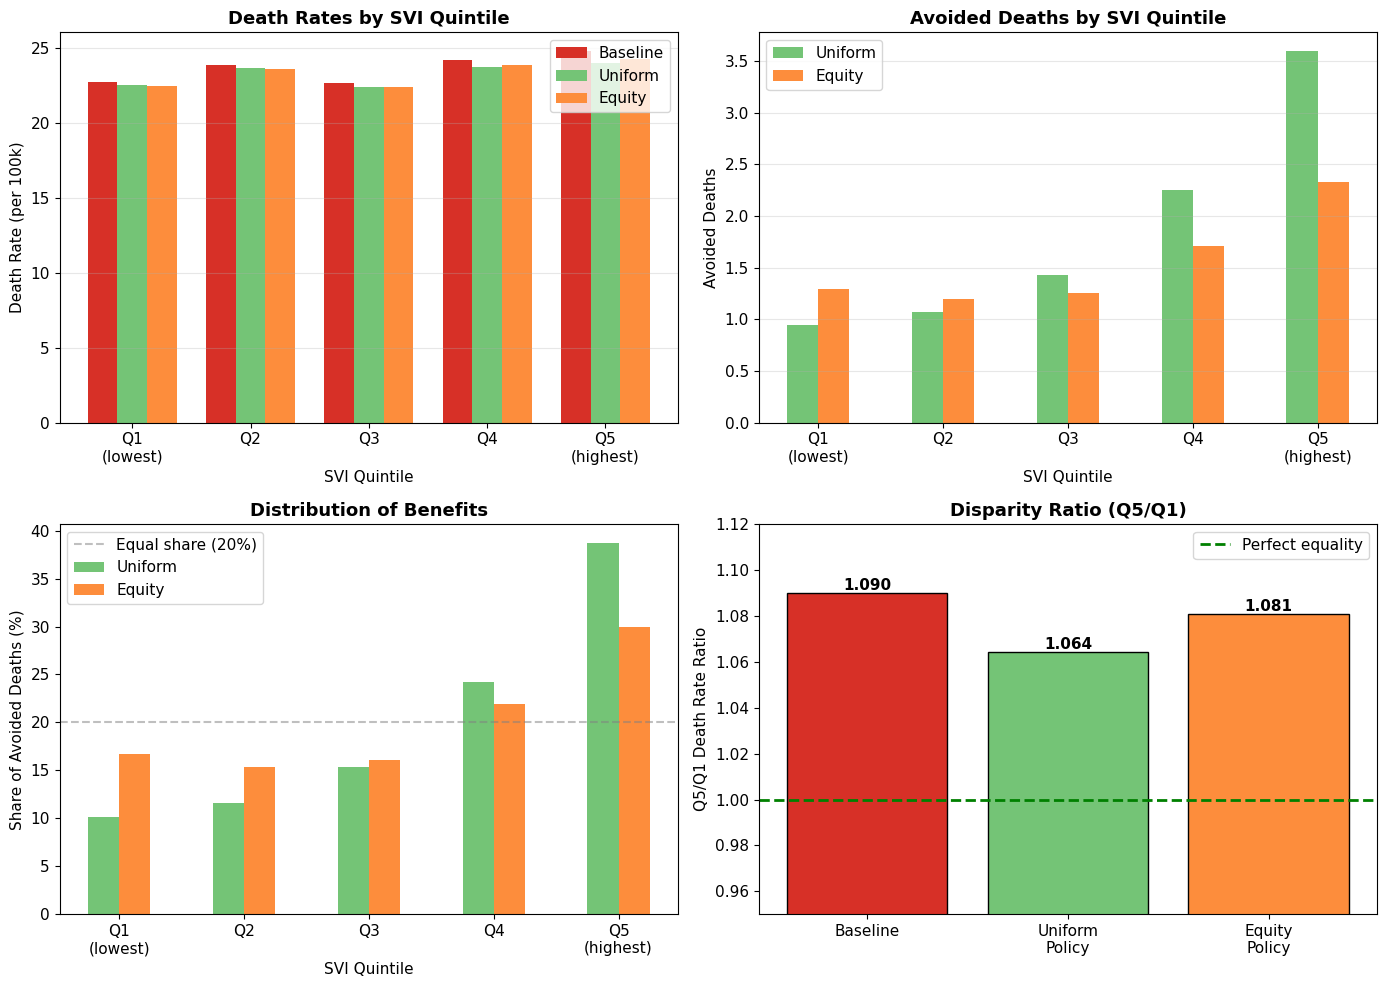

In [43]:
# Diagnostic figures for the disparity analysis
if HAS_VULN and 'disparity_df' in tables:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    disp_df = tables['disparity_df'].copy()

    def _q5q1_ratio(col):
        q1 = float(disp_df.loc[disp_df['quintile'] == 1, col].iloc[0])
        q5 = float(disp_df.loc[disp_df['quintile'] == 5, col].iloc[0])
        return q5 / q1 if q1 != 0 else np.nan

    ratio_baseline = float(tables.get('ratio_baseline', _q5q1_ratio('rate_baseline')))
    ratio_uniform = float(tables.get('ratio_uniform', _q5q1_ratio('rate_uniform')))
    ratio_equity = float(tables.get('ratio_equity', _q5q1_ratio('rate_equity')))

    ax1 = axes[0, 0]
    x = np.arange(5)
    width = 0.25

    ax1.bar(x - width, disp_df['rate_baseline'], width, label='Baseline', color='#d73027')
    ax1.bar(x, disp_df['rate_uniform'], width, label='Uniform', color='#74c476')
    ax1.bar(x + width, disp_df['rate_equity'], width, label='Equity', color='#fd8d3c')

    ax1.set_xticks(x)
    ax1.set_xticklabels(['Q1\n(lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(highest)'])
    ax1.set_xlabel('SVI Quintile')
    ax1.set_ylabel('Death Rate (per 100k)')
    ax1.set_title('Death Rates by SVI Quintile', fontweight='bold')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')

    ax2 = axes[0, 1]
    ax2.bar(x - width/2, disp_df['avo_uniform'], width, label='Uniform', color='#74c476')
    ax2.bar(x + width/2, disp_df['avo_equity'], width, label='Equity', color='#fd8d3c')

    ax2.set_xticks(x)
    ax2.set_xticklabels(['Q1\n(lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(highest)'])
    ax2.set_xlabel('SVI Quintile')
    ax2.set_ylabel('Avoided Deaths')
    ax2.set_title('Avoided Deaths by SVI Quintile', fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    ax3 = axes[1, 0]
    share_unif = disp_df['share_uniform'].values
    share_eq = disp_df['share_equity'].values

    ax3.bar(x - width/2, share_unif, width, label='Uniform', color='#74c476')
    ax3.bar(x + width/2, share_eq, width, label='Equity', color='#fd8d3c')

    ax3.axhline(20, color='gray', linestyle='--', alpha=0.5, label='Equal share (20%)')
    ax3.set_xticks(x)
    ax3.set_xticklabels(['Q1\n(lowest)', 'Q2', 'Q3', 'Q4', 'Q5\n(highest)'])
    ax3.set_xlabel('SVI Quintile')
    ax3.set_ylabel('Share of Avoided Deaths (%)')
    ax3.set_title('Distribution of Benefits', fontweight='bold')
    ax3.legend()

    ax4 = axes[1, 1]
    ratios = [ratio_baseline, ratio_uniform, ratio_equity]
    labels = ['Baseline', 'Uniform\nPolicy', 'Equity\nPolicy']
    colors = ['#d73027', '#74c476', '#fd8d3c']

    bars = ax4.bar(labels, ratios, color=colors, edgecolor='black', linewidth=1)
    ax4.axhline(1.0, color='green', linestyle='--', linewidth=2, label='Perfect equality')
    ax4.set_ylabel('Q5/Q1 Death Rate Ratio')
    ax4.set_title('Disparity Ratio (Q5/Q1)', fontweight='bold')
    ax4.set_ylim(0.95, 1.12)
    ax4.legend()

    for bar, ratio in zip(bars, ratios):
        ax4.annotate(f'{ratio:.3f}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.savefig(OUT / f"{SLUG}_disparity_analysis.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('[SKIP] Disparity diagnostic figure needs disparity_df.')


### 4.5 Greenness-Vulnerability Correlation

The GVI-SVI correlation is a compact way to understand whether low-greenness areas already overlap with high vulnerability. That empirical relationship is what determines whether the uniform policy already behaves as an equity-oriented allocation or whether explicit reweighting may be useful.


The printed interpretation below is the city-specific result; it should be read from the computed correlation and disparity outputs rather than assumed in advance.


In [44]:
# Quantify the empirical overlap between greenness deficit and vulnerability
if HAS_VULN and "svi_popw" in policy_df.columns:
    corr = policy_df[["gvi_mean", "svi_popw"]].corr().iloc[0, 1]
    print(f"GVI-SVI correlation: {corr:.3f}")
    
    print("\n" + "="*70)
    print("KEY FINDING: GVI-SVI SPATIAL CORRELATION")
    print("="*70)
    print(f"  Correlation ({VEG_REGION_LABEL}-level): ρ = {corr:.3f}")
    
    if corr < -0.2:
        print("  Interpretation: NEGATIVE correlation")
        print("  → Low-GVI areas tend to have high SVI (vulnerable populations)")
        print("  → Uniform policy naturally benefits vulnerable areas")
    elif corr > 0.2:
        print("  Interpretation: POSITIVE correlation")
        print("  → High-GVI areas have high SVI (unexpected)")
        print("  → Equity policy needed to redirect benefits")
    else:
        print("  Interpretation: WEAK correlation")
        print("  → GVI and SVI are spatially independent")
        print("  → Equity weighting can improve targeting")

GVI-SVI correlation: -0.445

KEY FINDING: GVI-SVI SPATIAL CORRELATION
  Correlation (Municipio-level): ρ = -0.445
  Interpretation: NEGATIVE correlation
  → Low-GVI areas tend to have high SVI (vulnerable populations)
  → Uniform policy naturally benefits vulnerable areas


In [45]:
# Interpret the city-specific GVI-SVI correlation
corr_gvi_svi = policy_df[["gvi_mean", "svi_popw"]].corr().iloc[0, 1]
disp_df = tables.get("disparity_df")

ratio_baseline = tables.get("ratio_baseline")
ratio_uniform = tables.get("ratio_uniform")
high_vuln_unif = tables.get("high_vuln_unif")
total_avo_unif = tables.get("total_avo_unif")
if disp_df is not None:
    if ratio_baseline is None:
        q1 = float(disp_df.loc[disp_df["quintile"] == 1, "rate_baseline"].iloc[0])
        q5 = float(disp_df.loc[disp_df["quintile"] == 5, "rate_baseline"].iloc[0])
        ratio_baseline = q5 / q1 if q1 != 0 else np.nan
    if ratio_uniform is None:
        q1 = float(disp_df.loc[disp_df["quintile"] == 1, "rate_uniform"].iloc[0])
        q5 = float(disp_df.loc[disp_df["quintile"] == 5, "rate_uniform"].iloc[0])
        ratio_uniform = q5 / q1 if q1 != 0 else np.nan
    if high_vuln_unif is None:
        high_vuln_unif = float(disp_df.loc[disp_df["quintile"].isin([4, 5]), "avo_uniform"].sum())
    if total_avo_unif is None:
        total_avo_unif = float(disp_df["avo_uniform"].sum())

print("\n" + "="*70)
print("KEY FINDING: GVI-SVI SPATIAL CORRELATION")
print("="*70)
print(f"\n  Correlation ({VEG_REGION_LABEL}-level): rho = {corr_gvi_svi:.3f}")

if corr_gvi_svi < -0.2:
    print(f"\n  Interpretation: NEGATIVE correlation")
    print(f"    -> Low greenery areas have higher social vulnerability")
    print(f"    -> Uniform GVI policy naturally targets vulnerable populations")
    print(f"    -> the uniform policy tends to align efficiency and equity")
elif corr_gvi_svi > 0.2:
    print(f"\n  Interpretation: POSITIVE correlation")
    print(f"    -> High greenery areas have higher social vulnerability")
    print(f"    -> Uniform GVI policy may miss vulnerable populations")
    print(f"    -> Explicit equity targeting may be needed")
else:
    print(f"\n  Interpretation: WEAK correlation")
    print(f"    -> GVI and SVI are spatially independent")
    print(f"    -> Policy choice depends on priorities")

print(f"\n  Policy recommendation for {CITY}:")
print(f"    -> Use uniform 'close-the-gap' policy (target = Q3 GVI)")
if ratio_baseline is not None and ratio_uniform is not None and np.isfinite(ratio_baseline) and np.isfinite(ratio_uniform):
    print(f"    -> Achieves {ratio_baseline - ratio_uniform:.4f} disparity reduction")
if high_vuln_unif is not None and total_avo_unif is not None and total_avo_unif > 0:
    print(f"    -> Concentrates {high_vuln_unif/total_avo_unif*100:.0f}% of benefits in Q4+Q5")

tables["gvi_svi_correlation"] = corr_gvi_svi



KEY FINDING: GVI-SVI SPATIAL CORRELATION

  Correlation (Municipio-level): rho = -0.445

  Interpretation: NEGATIVE correlation
    -> Low greenery areas have higher social vulnerability
    -> Uniform GVI policy naturally targets vulnerable populations
    -> the uniform policy tends to align efficiency and equity

  Policy recommendation for Rome:
    -> Use uniform 'close-the-gap' policy (target = Q3 GVI)
    -> Achieves 0.0256 disparity reduction
    -> Concentrates 63% of benefits in Q4+Q5


The conclusion of the equity comparison is city-specific. In some cities the uniform “close-the-gap” policy may already concentrate benefits in vulnerable areas because greenness deficits and social vulnerability overlap spatially; in others, an explicit vulnerability-weighted allocation may change the targeting pattern. The operative conclusion is the one produced by the computed correlation, disparity ratios, and avoided-death tables above.


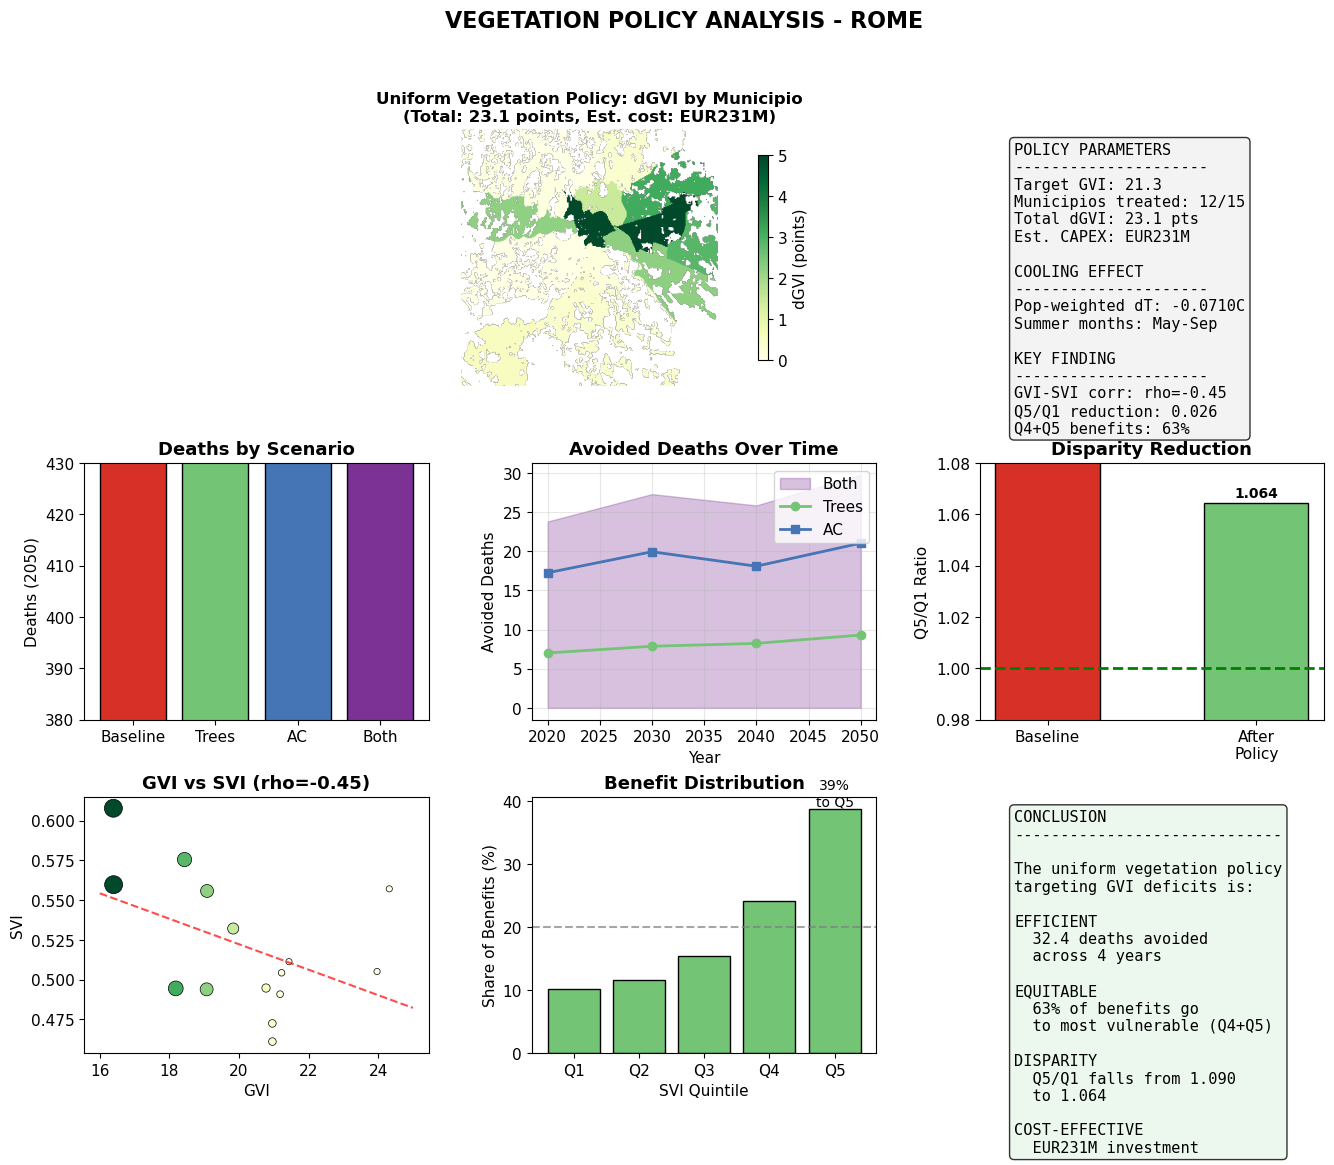


Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/rome_policy_summary.png


In [46]:
# Diagnostic summary figure of the vegetation pathway
if HAS_VULN and 'disparity_df' in tables:
    disp_df = tables['disparity_df'].copy()
    ratio_baseline = float(tables.get('ratio_baseline', np.nan))
    ratio_uniform = float(tables.get('ratio_uniform', np.nan))
    high_vuln_unif = float(tables.get('high_vuln_unif', np.nan))
    total_avo_unif = float(tables.get('total_avo_unif', np.nan))

    if not np.isfinite(ratio_baseline):
        q1 = float(disp_df.loc[disp_df['quintile'] == 1, 'rate_baseline'].iloc[0])
        q5 = float(disp_df.loc[disp_df['quintile'] == 5, 'rate_baseline'].iloc[0])
        ratio_baseline = q5 / q1 if q1 != 0 else np.nan
    if not np.isfinite(ratio_uniform):
        q1 = float(disp_df.loc[disp_df['quintile'] == 1, 'rate_uniform'].iloc[0])
        q5 = float(disp_df.loc[disp_df['quintile'] == 5, 'rate_uniform'].iloc[0])
        ratio_uniform = q5 / q1 if q1 != 0 else np.nan
    if not np.isfinite(high_vuln_unif):
        high_vuln_unif = float(disp_df.loc[disp_df['quintile'].isin([4, 5]), 'avo_uniform'].sum())
    if not np.isfinite(total_avo_unif):
        total_avo_unif = float(disp_df['avo_uniform'].sum())

    benefit_share_unif = high_vuln_unif / total_avo_unif * 100 if total_avo_unif > 0 else np.nan

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

    ax1 = fig.add_subplot(gs[0, :2])
    dgvi_plot = np.where(SCOPE_PHYS, dGVI_map, np.nan)
    im1 = ax1.imshow(dgvi_plot, cmap='YlGn', vmin=0, vmax=5)
    ax1.set_title(f'Uniform Vegetation Policy: dGVI by {VEG_REGION_LABEL}\n(Total: {total_dGVI:.1f} points, Est. cost: EUR{total_dGVI*10:.0f}M)', 
                  fontweight='bold', fontsize=12)
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, label='dGVI (points)', shrink=0.8)

    ax2 = fig.add_subplot(gs[0, 2])
    ax2.axis('off')
    metrics_text = f'''POLICY PARAMETERS
---------------------
Target GVI: {TARGET_GVI:.1f}
{VEG_REGION_LABEL}s treated: {n_treated}/15
Total dGVI: {total_dGVI:.1f} pts
Est. CAPEX: EUR{total_dGVI*10:.0f}M

COOLING EFFECT
---------------------
Pop-weighted dT: {dLST_summer_popw:.4f}C
Summer months: May-Sep

KEY FINDING
---------------------
GVI-SVI corr: rho={corr_gvi_svi:.2f}
Q5/Q1 reduction: {ratio_baseline - ratio_uniform:.3f}
Q4+Q5 benefits: {benefit_share_unif:.0f}%'''
    ax2.text(0.1, 0.95, metrics_text, transform=ax2.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

    ax3 = fig.add_subplot(gs[1, 0])
    scenarios = ['Baseline', 'Trees', 'AC', 'Both']
    deaths_2050 = [yr_totals_base.loc[2050, 'overall'],
                   yr_totals_trees.loc[2050, 'overall'],
                   yr_totals_acpol.loc[2050, 'overall'],
                   yr_totals_both.loc[2050, 'overall']]
    colors = ['#d73027', '#74c476', '#4575b4', '#7b3294']
    ax3.bar(scenarios, deaths_2050, color=colors, edgecolor='black')
    ax3.set_ylabel('Deaths (2050)')
    ax3.set_title('Deaths by Scenario', fontweight='bold')
    ax3.set_ylim(380, 430)

    ax4 = fig.add_subplot(gs[1, 1])
    years = yr_totals_base.index.tolist()
    ax4.fill_between(years, 0, avo_both['avo_overall'], alpha=0.3, color='#7b3294', label='Both')
    ax4.plot(years, avo_trees['avo_overall'], 'o-', color='#74c476', label='Trees', linewidth=2)
    ax4.plot(years, avo_ac['avo_overall'], 's-', color='#4575b4', label='AC', linewidth=2)
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Avoided Deaths')
    ax4.set_title('Avoided Deaths Over Time', fontweight='bold')
    ax4.legend(loc='upper right')
    ax4.grid(True, alpha=0.3)

    ax5 = fig.add_subplot(gs[1, 2])
    ratios = [ratio_baseline, ratio_uniform]
    labels = ['Baseline', 'After\nPolicy']
    colors = ['#d73027', '#74c476']
    bars = ax5.bar(labels, ratios, color=colors, edgecolor='black', width=0.5)
    ax5.axhline(1.0, color='green', linestyle='--', linewidth=2)
    ax5.set_ylabel('Q5/Q1 Ratio')
    ax5.set_title('Disparity Reduction', fontweight='bold')
    ax5.set_ylim(0.98, 1.08)
    for bar, ratio in zip(bars, ratios):
        ax5.annotate(f'{ratio:.3f}', (bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002),
                    ha='center', fontsize=10, fontweight='bold')

    ax6 = fig.add_subplot(gs[2, 0])
    ax6.scatter(policy_df['gvi_mean'], policy_df['svi_popw'], 
                s=policy_df['dGVI']*30 + 20, c=policy_df['dGVI'], 
                cmap='YlGn', edgecolors='black', linewidth=0.5,
                vmin=0, vmax=5)
    z = np.polyfit(policy_df['gvi_mean'], policy_df['svi_popw'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(16, 25, 100)
    ax6.plot(x_line, p(x_line), 'r--', alpha=0.7)
    ax6.set_xlabel('GVI')
    ax6.set_ylabel('SVI')
    ax6.set_title(f'GVI vs SVI (rho={corr_gvi_svi:.2f})', fontweight='bold')

    ax7 = fig.add_subplot(gs[2, 1])
    quintiles = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
    ax7.bar(quintiles, disp_df['share_uniform'], color='#74c476', edgecolor='black')
    ax7.axhline(20, color='gray', linestyle='--', alpha=0.7)
    ax7.set_ylabel('Share of Benefits (%)')
    ax7.set_xlabel('SVI Quintile')
    ax7.set_title('Benefit Distribution', fontweight='bold')
    ax7.annotate(f'{disp_df["share_uniform"].iloc[4]:.0f}%\nto Q5', 
                 xy=(4, disp_df['share_uniform'].iloc[4]), 
                 fontsize=10, ha='center', va='bottom')

    ax8 = fig.add_subplot(gs[2, 2])
    ax8.axis('off')
    conclusion = f'''CONCLUSION
-----------------------------

The uniform vegetation policy
targeting GVI deficits is:

EFFICIENT
  {avo_trees["avo_overall"].sum():.1f} deaths avoided
  across {len(YEARS_H)} years

EQUITABLE
  {benefit_share_unif:.0f}% of benefits go
  to most vulnerable (Q4+Q5)

DISPARITY
  Q5/Q1 falls from {ratio_baseline:.3f}
  to {ratio_uniform:.3f}

COST-EFFECTIVE
  EUR{total_dGVI*10:.0f}M investment'''
    ax8.text(0.1, 0.95, conclusion, transform=ax8.transAxes, fontsize=11,
             verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#e8f5e9', alpha=0.8))

    plt.suptitle(f'VEGETATION POLICY ANALYSIS - {CITY.upper()}', fontsize=16, fontweight='bold', y=0.98)
    plt.savefig(OUT / f"{SLUG}_policy_summary.png", dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nSaved: {OUT / f'{SLUG}_policy_summary.png'}")
else:
    print('[SKIP] Summary figure needs disparity_df.')


In [47]:
TBL = OUT / "tables"
TBL.mkdir(parents=True, exist_ok=True)

# Optional region-level comparison between the uniform and equity-weighted allocations
if HAS_VULN and equity_df is not None:
    
    # Create comprehensive comparison table
    comparison_tbl = equity_df[['region_id', 'region_name', 'gvi_mean', 'svi_popw', 
                                 'population', 'dGVI', 'dGVI_equity']].copy()
    comparison_tbl = comparison_tbl.rename(columns={
        'gvi_mean': 'GVI_baseline',
        'svi_popw': 'SVI',
        'dGVI': 'ΔGVI_uniform',
        'dGVI_equity': 'ΔGVI_equity'
    })
    comparison_tbl['GVI_after_uniform'] = comparison_tbl['GVI_baseline'] + comparison_tbl['ΔGVI_uniform']
    comparison_tbl['GVI_after_equity'] = comparison_tbl['GVI_baseline'] + comparison_tbl['ΔGVI_equity']
    comparison_tbl['Δallocation'] = comparison_tbl['ΔGVI_equity'] - comparison_tbl['ΔGVI_uniform']
    
    # Format for display
    display_tbl = comparison_tbl.copy()
    display_tbl['region_name'] = display_tbl['region_name'].str.replace('{VEG_REGION_LABEL} Roma ', '')
    display_tbl['population'] = (display_tbl['population'] / 1000).round(1).astype(str) + 'k'
    
    print("\n" + "="*100)
    print("POLICY COMPARISON TABLE: Uniform vs Smart Equity")
    print("="*100)
    print(display_tbl.round(2).to_string(index=False))
    
    # Save the target-sensitivity table for later use table
    comparison_tbl.to_csv(TBL / f"{SLUG}_policy_comparison.csv", index=False)
    print(f"\nSaved: {TBL / f'{SLUG}_policy_comparison.csv'}")
    
    # Summary stats
    print("\n" + "-"*50)
    print("SUMMARY STATISTICS")
    print("-"*50)
    print(f"Total ΔGVI (both policies): {comparison_tbl['ΔGVI_uniform'].sum():.2f} points")
    print(f"Correlation GVI-SVI: {corr_gvi_svi:.3f}")
    print(f"\nMunicipalities gaining from equity allocation: {(comparison_tbl['Δallocation'] > 0).sum()}")
    print(f"Municipalities losing from equity allocation: {(comparison_tbl['Δallocation'] < 0).sum()}")


POLICY COMPARISON TABLE: Uniform vs Smart Equity
 region_id         region_name  GVI_baseline  SVI population  ΔGVI_uniform  ΔGVI_equity  GVI_after_uniform  GVI_after_equity  Δallocation
         1    Municipio Roma I         16.39 0.61     169.1k          4.91         2.25              21.30             18.64        -2.66
         2   Municipio Roma II         19.83 0.53     165.5k          1.47         1.97              21.30             21.80         0.50
         3  Municipio Roma III         20.96 0.47     144.7k          0.34         1.75              21.30             22.71         1.41
         4   Municipio Roma IV         18.18 0.49     173.7k          3.12         1.83              21.30             20.01        -1.29
         5    Municipio Roma V         16.40 0.56     177.1k          4.90         2.07              21.30             18.47        -2.83
         6   Municipio Roma VI         18.43 0.58     125.8k          2.87         2.13              21.30             20.

## 5. Parameterize vegetation costs

This section converts the greening intervention into discounted cost streams that are comparable with the AC and EWS pathways in later CBA work.


### 5.1 Common CBA Settings

The vegetation notebook uses the same discounting framework and time horizon as the downstream policy comparison.


In [48]:
import numpy as np
import json

# Common discounting settings for later CBA comparison
cba_cfg = cfg.get("cba", {})
R = cba_cfg.get("discount_rate", 0.03)  # discount rate
T = cba_cfg.get("horizon_years", 25)     # time horizon

def annuity_factor(r=R, T=T):
    """Present value of €1/year for T years at rate r."""
    return (1 - (1 + r) ** (-T)) / r

AF = annuity_factor(R, T)

print("="*60)
print("CBA FRAMEWORK PARAMETERS")
print("="*60)
print(f"Discount rate:    {R:.1%}")
print(f"Horizon:          {T} years")
print(f"Annuity factor:   {AF:.3f}")

CBA FRAMEWORK PARAMETERS
Discount rate:    3.0%
Horizon:          25 years
Annuity factor:   17.413


### 5.2 Tree Cost Assumptions

The numerical assumptions used below are the current notebook defaults, and they coincide with the documented city assumptions at present:
- `€10M` per GVI index point
- `€210` CAPEX per tree
- `€27` O&M per tree per year
- `25`-year lifetime

The notebook then converts the per-tree O&M reference into a per-index-point O&M stream so the greenness intervention and the cost calculation stay on the same policy scale.


The current implementation also assumes a `12`-year maturity ramp and uses a central case with pre-grown trees (`5`-year head start), plus a seedling sensitivity case later on.


In [49]:
tree_cost_cfg = cfg.get("tree_costs", {})

CAPEX_PER_INDEX_PT = tree_cost_cfg.get("capex_per_index_pt", 10_000_000.0)
CAPEX_PER_TREE = tree_cost_cfg.get("capex_per_tree", 210.0)
OM_PER_TREE_YR = tree_cost_cfg.get("om_per_tree_yr", 27.0)
LIFETIME_YEARS = tree_cost_cfg.get("lifetime_years", 25)

# Convert per-tree annual O&M into the per-index-point scale used by the policy
OM_PER_INDEX_PT_YR = (OM_PER_TREE_YR / CAPEX_PER_TREE) * CAPEX_PER_INDEX_PT

# Central maturity and starting-age assumptions used in the current notebook
TREE_RAMP_YEARS = 12  # Years to full maturity
TREE_START_AGE_YEARS = 5  # Pre-grown trees (central case)
TREE_START_AGE_CENTRAL = 5
TREE_START_AGE_SENS = 0  # Seedlings (sensitivity)

# Total greening intervention size used in the cost calculations
DELTA_INDEX = float(policy_df["dGVI"].clip(lower=0).sum())

print(f"Horizon:              {T} years")
print(f"Discount rate:        {R*100:.0f}%")
print(f"Annuity factor:       {AF:.4f}")
print(f"\nCAPEX per GVI point:  €{CAPEX_PER_INDEX_PT:,.0f}")
print(f"O&M per GVI pt/yr:    €{OM_PER_INDEX_PT_YR:,.0f}")
print(f"Tree lifetime:        {LIFETIME_YEARS} years")
print(f"Ramp to maturity:     {TREE_RAMP_YEARS} years")
print(f"Tree start age:       {TREE_START_AGE_YEARS} years (pre-grown)")
print(f"\nTotal ΔGVI:           {DELTA_INDEX:.2f} index points")

Horizon:              25 years
Discount rate:        3%
Annuity factor:       17.4131

CAPEX per GVI point:  €10,000,000
O&M per GVI pt/yr:    €1,285,714
Tree lifetime:        25 years
Ramp to maturity:     12 years
Tree start age:       5 years (pre-grown)

Total ΔGVI:           23.10 index points


### 5.3 CAPEX Over the Horizon

CAPEX is represented as a linear rollout over the analysis horizon rather than as a single fully upfront purchase.


That choice keeps the cost timing aligned with the gradual planting logic used later for benefit maturity.


In [50]:
def npv_capex_linear(delta_index_total, years=T, r=R, capex_per_index=CAPEX_PER_INDEX_PT):
    """PV of CAPEX with linear rollout over years."""
    inc = delta_index_total / years
    pv = 0.0
    for t in range(1, years + 1):
        capex_t = capex_per_index * inc
        pv += capex_t / ((1 + r) ** t)
    return float(pv)

TREES_CAPEX_T0 = CAPEX_PER_INDEX_PT * DELTA_INDEX
PV_trees_capex = npv_capex_linear(DELTA_INDEX)

print(f"\n{'='*60}")
print("CAPEX CALCULATION")
print(f"{'='*60}")
print(f"Upfront equivalent (t=0): €{TREES_CAPEX_T0:,.0f}")
print(f"PV (linear rollout):      €{PV_trees_capex:,.0f}") # linear ramp


CAPEX CALCULATION
Upfront equivalent (t=0): €231,042,270
PV (linear rollout):      €160,926,927


### 5.4 O&M with Tree Maturity

O&M is not treated as flat from year zero. The stream is scaled by a maturity profile so young plantings do not immediately generate full annual maintenance requirements.


In [51]:
def cohort_rollout_maturity_factor_om(T, ramp_years, plant_share=None, lifetime=25, start_age_years=0):
    """
    O&M maturity factor using convolution.
    EXACT copy from NB9 - DO NOT MODIFY.
    
    factor[t] = sum_i plant_share[i] * maturity(age=t-i), where
      - planting year (age=0) has maturity forced to 0 => O&M starts at t+1
      - from age>=1, maturity is shifted by start_age_years (pre-grown trees)
    """
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T
    max_age = min(T, lifetime)
    ages = np.arange(max_age + 1, dtype=float)  # 0..max_age
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # no O&M in planting year
    return np.convolve(plant_share, maturity)[:T]

def npv_om_cohorts_scaled(delta_index_total, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
                         ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS, start_age_years=0):
    """
    NPV of O&M with maturity scaling.
    EXACT copy from NB9 - DO NOT MODIFY.
    """
    plant_share = np.ones(years, dtype=float) / years
    factor_om = cohort_rollout_maturity_factor_om(
        T=years, ramp_years=ramp_years, plant_share=plant_share,
        lifetime=lifetime, start_age_years=start_age_years
    )
    om_stream = om_per_index_per_year * delta_index_total * factor_om
    yrs = np.arange(1, years + 1, dtype=float)
    pv = float(np.sum(om_stream * (1 + r) ** (-yrs)))
    return pv, om_stream

# Central O&M case: pre-grown trees with a five-year head start
PV_trees_om, om_stream = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR,
    ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS,
    start_age_years=TREE_START_AGE_YEARS  # =5
)

print(f"\n{'='*60}")
print("O&M CALCULATION (Base Scenario)")
print(f"{'='*60}")
print(f"O&M per GVI point/year:   €{OM_PER_INDEX_PT_YR:,.0f} (at full maturity)")
print(f"Start age:                {TREE_START_AGE_YEARS} years")
print(f"Ramp to maturity:         {TREE_RAMP_YEARS} years")
print(f"\nPV of O&M:                €{PV_trees_om:,.0f}")
print(f"O&M stream (first 5 yrs): {np.round(om_stream[:5]/1e6, 2)} M€")


O&M CALCULATION (Base Scenario)
O&M per GVI point/year:   €1,285,714 (at full maturity)
Start age:                5 years
Ramp to maturity:         12 years

PV of O&M:                €185,754,244
O&M stream (first 5 yrs): [0.   0.59 1.29 2.08 2.97] M€


### 5.5 High-O&M Sensitivity

This sensitivity tests a much larger O&M burden by scaling the maintenance stream up to a five-times case.


The point is not to claim that 5x is the most likely value, but to test how strongly maintenance assumptions drive vegetation cost-effectiveness.


In [52]:
TARGET_OM_TO_CAPEX_PV_RATIO = 5.0
k = (TARGET_OM_TO_CAPEX_PV_RATIO * PV_trees_capex) / PV_trees_om
OM_PER_INDEX_PT_YR_5x = OM_PER_INDEX_PT_YR * k

PV_trees_om_5x, om_stream_5x = npv_om_cohorts_scaled(
    DELTA_INDEX, years=T, r=R, om_per_index_per_year=OM_PER_INDEX_PT_YR_5x,
    ramp_years=TREE_RAMP_YEARS, lifetime=LIFETIME_YEARS,
    start_age_years=TREE_START_AGE_YEARS
)

print(f"\n{'='*60}")
print("O&M SENSITIVITY (5× Scenario)")
print(f"{'='*60}")
print(f"Scale factor k:           {k:.2f}×")
print(f"PV of O&M (5×):           €{PV_trees_om_5x:,.0f}")


O&M SENSITIVITY (5× Scenario)
Scale factor k:           4.33×
PV of O&M (5×):           €804,634,634


### 5.6 Total Cost Summary

CAPEX and O&M are combined into present-value and equivalent-annual-cost summaries.


In [53]:
PV_trees_total = PV_trees_capex + PV_trees_om
PV_trees_total_5x = PV_trees_capex + PV_trees_om_5x

EAC_trees = PV_trees_total / AF
EAC_trees_5x = PV_trees_total_5x / AF

print(f"\n{'='*60}")
print("TOTAL VEGETATION POLICY COSTS")
print(f"{'='*60}")
print(f"{'Component':<25} {'Base O&M':>18} {'5× O&M':>18}")
print("-"*61)
print(f"{'PV CAPEX':<25} €{PV_trees_capex:>15,.0f} €{PV_trees_capex:>15,.0f}")
print(f"{'PV O&M':<25} €{PV_trees_om:>15,.0f} €{PV_trees_om_5x:>15,.0f}")
print("-"*61)
print(f"{'PV TOTAL':<25} €{PV_trees_total:>15,.0f} €{PV_trees_total_5x:>15,.0f}")
print(f"{'EAC':<25} €{EAC_trees:>15,.0f}/yr €{EAC_trees_5x:>15,.0f}/yr")


TOTAL VEGETATION POLICY COSTS
Component                           Base O&M             5× O&M
-------------------------------------------------------------
PV CAPEX                  €    160,926,927 €    160,926,927
PV O&M                    €    185,754,244 €    804,634,634
-------------------------------------------------------------
PV TOTAL                  €    346,681,171 €    965,561,560
EAC                       €     19,909,162/yr €     55,450,145/yr


## 6. Cost-Effectiveness and Sensitivities

The focus here is the vegetation pathway. AC values are shown only as contextual gross benefits because the full AC comparison must be done later with waste-heat-adjusted net benefits.


In [54]:
# This section computes cost-effectiveness for the VEGETATION policy only.
# AC benefits are shown for CONTEXT but should NOT be used for cost-effectiveness
# because:
#   - AC has a waste heat penalty (computed in NB5 Section 7)
#   - NET AC benefits = GROSS - waste heat penalty
#   - Full policy comparison with NET values is done in NB8 CBA

### 6.1 Extend Avoided Deaths to the 25-Year CBA Horizon

The mortality model is run on the anchor years. To compare policies in `NB08`, those anchor-year tree benefits are interpolated to the common 25-year horizon and then scaled by the tree maturity rollout.


In [55]:
# Extract the anchor-year avoided-death series used for the 25-year interpolation
avoided_trees_only = avo_trees["avo_overall"]
avoided_ac_only = avo_ac["avo_overall"]
avoided_both = avo_both["avo_overall"]
avoided_trees_on_top = avo_trees_cond["avo_overall"]

print("\n6.1 Anchor Year Values (from Section 3)")
print("-" * 50)
print(f"  Trees only:\n{avoided_trees_only.round(3)}")
print(f"\n  Sum (4 anchor years): {avoided_trees_only.sum():.2f}")

# Helpers for horizon interpolation and tree maturity scaling
def interpolate_to_horizon(s: pd.Series, years: np.ndarray) -> np.ndarray:
    """Interpolate anchor years to full horizon."""
    s = s.sort_index()
    known = s.index.to_numpy(int)
    vals = s.to_numpy(float)
    out = np.interp(years, known, vals)
    out[years <= known[0]] = vals[0]
    out[years >= known[-1]] = vals[-1]
    return out

def cohort_rollout_maturity_factor(T, ramp_years, plant_share=None, start_age_years=0):
    """Linear planting + maturity ramp for tree benefits."""
    if plant_share is None:
        plant_share = np.ones(T, dtype=float) / T
    ages = np.arange(T + 1, dtype=float)
    maturity = np.minimum((ages + start_age_years) / ramp_years, 1.0)
    maturity[0] = 0.0  # no benefits in planting year
    return np.convolve(plant_share, maturity)[:T]

# Build the common 25-year horizon used later in NB8
START_YEAR = int(avoided_trees_only.index.min())
YEARS_ALL = np.arange(START_YEAR, START_YEAR + T, dtype=int)

print(f"\n6.2 25-Year Interpolation")
print("-" * 50)
print(f"  Horizon: {YEARS_ALL[0]} to {YEARS_ALL[-1]} ({T} years)")

# Interpolate the anchor-year tree benefits across the full horizon
trees_only_25y_raw = interpolate_to_horizon(avoided_trees_only, YEARS_ALL)
trees_on_top_25y_raw = interpolate_to_horizon(avoided_trees_on_top, YEARS_ALL)

# Scale the interpolated tree benefits by the rollout/maturity profile
trees_factor = cohort_rollout_maturity_factor(
    T=T, 
    ramp_years=TREE_RAMP_YEARS,
    start_age_years=TREE_START_AGE_YEARS
)

trees_only_25y = trees_only_25y_raw * trees_factor
trees_on_top_25y = trees_on_top_25y_raw * trees_factor

# Summarise the resulting 25-year tree benefits
CUM_trees_only = float(np.sum(trees_only_25y))
CUM_trees_on_top = float(np.sum(trees_on_top_25y))

print(f"\n  Trees - 25-Year Avoided Deaths (DYNAMIC rollout):")
print(f"    Raw interpolated sum:    {trees_only_25y_raw.sum():.2f}")
print(f"    After maturity factor:   {CUM_trees_only:.2f}")
print(f"    Trees on top of AC:      {CUM_trees_on_top:.2f}")
print(f"\n  Maturity factor effect: {CUM_trees_only / trees_only_25y_raw.sum():.2%} of raw")


6.1 Anchor Year Values (from Section 3)
--------------------------------------------------
  Trees only:
2020    7.010
2030    7.872
2040    8.234
2050    9.300
Name: avo_overall, dtype: float64

  Sum (4 anchor years): 32.42

6.2 25-Year Interpolation
--------------------------------------------------
  Horizon: 2020 to 2044 (25 years)

  Trees - 25-Year Avoided Deaths (DYNAMIC rollout):
    Raw interpolated sum:    196.57
    After maturity factor:   85.10
    Trees on top of AC:      79.96

  Maturity factor effect: 43.29% of raw


### 6.2 Trees Cost-Effectiveness

The cost-effectiveness calculation uses the dynamically matured 25-year tree-benefit series rather than the raw anchor-year sums.


In [56]:
print(f"\n" + "=" * 60)
print("6.3 TREES COST-EFFECTIVENESS")
print("=" * 60)

if CUM_trees_only > 0:
    cost_per_death_base = PV_trees_total / CUM_trees_only
    cost_per_death_5x = PV_trees_total_5x / CUM_trees_only
    
    print(f"\n  PV Total Cost (base O&M):   €{PV_trees_total:,.0f}")
    print(f"  PV Total Cost (5× O&M):     €{PV_trees_total_5x:,.0f}")
    print(f"\n  Avoided Deaths (25-yr):     {CUM_trees_only:.2f}")
    print(f"\n  Cost per Avoided Death:")
    print(f"    Base O&M:  €{cost_per_death_base:,.0f}")
    print(f"    5× O&M:    €{cost_per_death_5x:,.0f}")
    
    # Annualized
    avg_avoided_per_year = CUM_trees_only / T
    print(f"\n  Annualized:")
    print(f"    Avg avoided deaths/yr: {avg_avoided_per_year:.2f}")
    print(f"    EAC (base):            €{EAC_trees:,.0f}/yr")
else:
    cost_per_death_base = np.inf
    cost_per_death_5x = np.inf
    print("\n  ⚠ Cannot compute: no avoided deaths")


6.3 TREES COST-EFFECTIVENESS

  PV Total Cost (base O&M):   €346,681,171
  PV Total Cost (5× O&M):     €965,561,560

  Avoided Deaths (25-yr):     85.10

  Cost per Avoided Death:
    Base O&M:  €4,073,672
    5× O&M:    €11,345,817

  Annualized:
    Avg avoided deaths/yr: 3.40
    EAC (base):            €19,909,162/yr


### 6.3 Tree-Age Sensitivity

This sensitivity asks how much the results depend on assuming pre-grown trees versus newly planted seedlings.


In [57]:
print(f"\n" + "=" * 60)
print("6.4 TREE AGE SENSITIVITY")
print("=" * 60)

def run_tree_age_case(start_age_years):
    """Run cost calculation with different tree starting age."""
    pv_om_case, _ = npv_om_cohorts_scaled(
        DELTA_INDEX, T, R, OM_PER_INDEX_PT_YR,
        TREE_RAMP_YEARS, LIFETIME_YEARS, start_age_years
    )
    pv_total_case = PV_trees_capex + pv_om_case
    
    # Also compute maturity factor for benefits
    factor_case = cohort_rollout_maturity_factor(T, TREE_RAMP_YEARS, start_age_years=start_age_years)
    trees_25y_case = trees_only_25y_raw * factor_case
    cum_case = float(np.sum(trees_25y_case))
    
    return {
        "start_age": start_age_years,
        "pv_om": pv_om_case,
        "pv_total": pv_total_case,
        "eac": pv_total_case / AF,
        "avoided_deaths": cum_case,
        "cost_per_death": pv_total_case / cum_case if cum_case > 0 else np.inf,
    }

case_central = run_tree_age_case(TREE_START_AGE_CENTRAL)
case_sens = run_tree_age_case(TREE_START_AGE_SENS)

print(f"\n  {'Case':<20} {'Start Age':<10} {'PV Total':<16} {'Avoided':<10} {'€/Death':<16}")
print("-" * 75)
print(f"  {'Central (pre-grown)':<20} {case_central['start_age']:<10} "
      f"€{case_central['pv_total']/1e6:>10.1f}M {case_central['avoided_deaths']:>10.1f} "
      f"€{case_central['cost_per_death']/1e6:>10.1f}M")
print(f"  {'Sensitivity (seed)':<20} {case_sens['start_age']:<10} "
      f"€{case_sens['pv_total']/1e6:>10.1f}M {case_sens['avoided_deaths']:>10.1f} "
      f"€{case_sens['cost_per_death']/1e6:>10.1f}M")


6.4 TREE AGE SENSITIVITY

  Case                 Start Age  PV Total         Avoided    €/Death         
---------------------------------------------------------------------------
  Central (pre-grown)  5          €     346.7M       85.1 €       4.1M
  Sensitivity (seed)   0          €     289.5M       61.2 €       4.7M


### 6.4 AC Benefits for Context Only

AC is shown here only as a gross reference series. The full AC comparison belongs in `NB08`, where waste-heat penalties are subtracted and all policies are put on the same net-benefit basis.


In [58]:
print(f"\n" + "=" * 60)
print("6.5 AC BENEFITS (CONTEXT ONLY - NOT FOR CEA)")
print("=" * 60)

print("""
  IMPORTANT: Values below are GROSS (before waste heat penalty)
  
  AC waste heat causes additional deaths that must be subtracted:
    - Waste heat penalty computed in NB5 Section 7
    - NET AC benefits = GROSS AC benefits - waste heat penalty
    - Full cost-effectiveness with NET values in NB8 CBA
""")

# AC is shown only as a contextual gross series without tree-style maturity scaling
ac_only_25y = interpolate_to_horizon(avoided_ac_only, YEARS_ALL)
CUM_ac_gross = float(np.sum(ac_only_25y))

# Combined gross series = AC gross benefit plus the marginal trees-on-top benefit
both_25y = ac_only_25y + trees_on_top_25y
CUM_both_gross = float(np.sum(both_25y))

print(f"  AC GROSS Benefits (25-year):")
print(f"    Anchor years sum:  {avoided_ac_only.sum():.2f}")
print(f"    25-year GROSS:     {CUM_ac_gross:.2f}")
print(f"\n  Both (AC + Trees) GROSS: {CUM_both_gross:.2f}")
print(f"\n  → NET AC and full comparison available in NB8 CBA")


6.5 AC BENEFITS (CONTEXT ONLY - NOT FOR CEA)

  IMPORTANT: Values below are GROSS (before waste heat penalty)
  
  AC waste heat causes additional deaths that must be subtracted:
    - Waste heat penalty computed in NB5 Section 7
    - NET AC benefits = GROSS AC benefits - waste heat penalty
    - Full cost-effectiveness with NET values in NB8 CBA

  AC GROSS Benefits (25-year):
    Anchor years sum:  76.30
    25-year GROSS:     468.98

  Both (AC + Trees) GROSS: 548.94

  → NET AC and full comparison available in NB8 CBA


### 6.5 Compact Summary Table

The table below condenses the main tree cost-effectiveness results and sensitivities into the form that is easiest to carry into the CBA notebook.


In [59]:
print(f"\n" + "=" * 70)
print("COST-EFFECTIVENESS SUMMARY (TREES ONLY)")
print("=" * 70)

cea_trees_df = pd.DataFrame([
    {
        "Policy": "Trees (base O&M, pre-grown)",
        "PV_Cost_M€": PV_trees_total / 1e6,
        "Avoided_Deaths": CUM_trees_only,
        "€_per_Death_M": cost_per_death_base / 1e6,
    },
    {
        "Policy": "Trees (5× O&M, pre-grown)",
        "PV_Cost_M€": PV_trees_total_5x / 1e6,
        "Avoided_Deaths": CUM_trees_only,
        "€_per_Death_M": cost_per_death_5x / 1e6,
    },
    {
        "Policy": "Trees (base O&M, from seed)",
        "PV_Cost_M€": case_sens['pv_total'] / 1e6,
        "Avoided_Deaths": case_sens['avoided_deaths'],
        "€_per_Death_M": case_sens['cost_per_death'] / 1e6,
    },
])

print("\n")
print(cea_trees_df.round(2).to_string(index=False))

print("""
Note: 
  - Tree benefits use DYNAMIC rollout with 12-year maturity ramp
  - Pre-grown trees (5-year head start) reach maturity faster
  - AC cost-effectiveness requires NET benefits (computed in NB8)
""")

# Store for export
tables["cea_trees_df"] = cea_trees_df
tables["trees_25y_series"] = trees_only_25y
tables["trees_on_top_25y_series"] = trees_on_top_25y
tables["ac_gross_25y_series"] = ac_only_25y
tables["CUM_trees_only"] = CUM_trees_only
tables["CUM_trees_on_top"] = CUM_trees_on_top
tables["CUM_ac_gross"] = CUM_ac_gross
tables["cost_per_death_trees_base"] = cost_per_death_base
tables["cost_per_death_trees_5x"] = cost_per_death_5x


COST-EFFECTIVENESS SUMMARY (TREES ONLY)


                     Policy  PV_Cost_M€  Avoided_Deaths  €_per_Death_M
Trees (base O&M, pre-grown)      346.68           85.10           4.07
  Trees (5× O&M, pre-grown)      965.56           85.10          11.35
Trees (base O&M, from seed)      289.49           61.18           4.73

Note: 
  - Tree benefits use DYNAMIC rollout with 12-year maturity ramp
  - Pre-grown trees (5-year head start) reach maturity faster
  - AC cost-effectiveness requires NET benefits (computed in NB8)



In [60]:
# Sensitivity analysis for alternative vegetation targets

print("\n" + "="*70)
print("SENSITIVITY ANALYSIS: TARGET GVI")
print("="*70)

# Test a small set of alternative target-GVI levels
TARGET_GVI_SCENARIOS = {
    "Q3 (baseline)": TARGET_GVI,      # current: 21.3
    "Q3 + 5": TARGET_GVI + 5.0,       # 26.3
    "Q3 + 10": TARGET_GVI + 10.0,     # 31.3
    "Max observed": 35.0,              # Ambitious
}

# Use the hazard years as the anchor years for the sensitivity runs
anchor_years = np.array([2020, 2030, 2040, 2050])

sensitivity_results = []

for scenario_name, target_gvi in TARGET_GVI_SCENARIOS.items():
    
    # Recompute ΔGVI for this target
    dgvi_sens = np.clip(target_gvi - policy_df["gvi_mean"].values, 0, None)
    total_dgvi = dgvi_sens.sum()
    
    # Expand the regional assignment to the full grid
    dgvi_map_sens = np.zeros((HGT, WDT), dtype=float)
    for mid, dg in zip(policy_df["region_id"], dgvi_sens):
        dgvi_map_sens[region_on_ref == mid] = dg
    dgvi_map_sens = np.where(SCOPE_PHYS, dgvi_map_sens, 0)
    
    # Compute cooling
    dLST_monthly_sens = compute_monthly_dT(dgvi_map_sens, lcz_on_ref, SCOPE_PHYS, coef_lut)
    dLST_summer_sens = dLST_monthly_sens[summer_indices].mean(axis=0)
    dLST_popw_sens = compute_popw_mean(dLST_summer_sens, pop_on_ref, SCOPE_PHYS)
    
    # Compute avoided deaths at anchor years
    dT_zero = np.zeros((HGT, WDT), dtype="float32")
    
    _, yr_totals_base_sens = annual_deaths_with_ac_and_dT(
        H,
        dT_zero,
        coverage_base_by_year,
        age_on_ref_by_year,
        pop_on_ref_by_year,
        mask=MASK_CITY,
        use_emulator=False
    )
    _, yr_totals_trees_sens = annual_deaths_with_ac_and_dT(
        H,
        dLST_monthly_sens,
        coverage_base_by_year,
        age_on_ref_by_year,
        pop_on_ref_by_year,
        mask=MASK_CITY,
        use_emulator=True,
        emu=EMU,
        lcz_grid=lcz_on_ref,
        out_b_grid=out_b_on_ref
    )
    
    # Avoided deaths at anchor years (per year)
    anchor_avoided = yr_totals_base_sens["overall"].values - yr_totals_trees_sens["overall"].values
    avoided_deaths_anchor = float(anchor_avoided.sum())
    
    # Step 1: Interpolate to 25 years
    avoided_25y_raw = np.interp(YEARS_ALL, anchor_years, anchor_avoided)
    
    # Step 2: Apply maturity factor (trees grow over time)
    avoided_25y = avoided_25y_raw * trees_factor
    avoided_deaths = float(avoided_25y.sum())
    
    # Estimate cost
    capex = total_dgvi * CAPEX_PER_INDEX_PT
    
    sensitivity_results.append({
        "scenario": scenario_name,
        "target_gvi": target_gvi,
        "total_dGVI": total_dgvi,
        "n_treated": int((dgvi_sens > 0).sum()),
        "dLST_popw_C": float(dLST_popw_sens),
        "avoided_deaths_anchor": avoided_deaths_anchor,
        "avoided_deaths_25y_raw": float(avoided_25y_raw.sum()),
        "avoided_deaths_25y": avoided_deaths,
        "capex_eur": capex,
        "cost_per_death": capex / avoided_deaths if avoided_deaths > 0 else np.inf
    })
    
    print(f"\n  {scenario_name} (Target = {target_gvi:.1f}):")
    print(f"    Treated {VEG_REGION_LABEL}s:     {int((dgvi_sens > 0).sum())}/15")
    print(f"    Total ΔGVI:           {total_dgvi:.1f} points")
    print(f"    Pop-weighted ΔT:      {dLST_popw_sens:.4f} °C")
    print(f"    Avoided deaths:")
    print(f"      Anchor years (4):   {avoided_deaths_anchor:.1f}")
    print(f"      Interpolated (25y): {avoided_25y_raw.sum():.1f}")
    print(f"      With maturity:      {avoided_deaths:.1f}")
    print(f"    Est. CAPEX:           €{capex/1e6:.0f}M")
    print(f"    Cost per death:       €{capex/avoided_deaths/1e6:.1f}M" if avoided_deaths > 0 else "    Cost per death:       N/A")

# Collect the target-sensitivity outputs into one table
sensitivity_df = pd.DataFrame(sensitivity_results)

print("\n" + "─"*70)
print("SENSITIVITY SUMMARY TABLE")
print("─"*70)
print(sensitivity_df[["scenario", "target_gvi", "total_dGVI", "dLST_popw_C", 
                       "avoided_deaths_25y", "capex_eur", "cost_per_death"]].to_string(index=False))

# Save the target-sensitivity table for later use
sensitivity_df.to_csv(INT / f"{SLUG}_trees_target_sensitivity.csv", index=False)
print(f"\n✓ Saved: {SLUG}_trees_target_sensitivity.csv")


SENSITIVITY ANALYSIS: TARGET GVI

  Q3 (baseline) (Target = 21.3):
    Treated Municipios:     12/15
    Total ΔGVI:           23.1 points
    Pop-weighted ΔT:      -0.0710 °C
    Avoided deaths:
      Anchor years (4):   32.4
      Interpolated (25y): 196.6
      With maturity:      85.1
    Est. CAPEX:           €231M
    Cost per death:       €2.7M

  Q3 + 5 (Target = 26.3):
    Treated Municipios:     15/15
    Total ΔGVI:           92.3 points
    Pop-weighted ΔT:      -0.2409 °C
    Avoided deaths:
      Anchor years (4):   104.9
      Interpolated (25y): 636.1
      With maturity:      275.3
    Est. CAPEX:           €923M
    Cost per death:       €3.4M

  Q3 + 10 (Target = 31.3):
    Treated Municipios:     15/15
    Total ΔGVI:           167.3 points
    Pop-weighted ΔT:      -0.4185 °C
    Avoided deaths:
      Anchor years (4):   175.5
      Interpolated (25y): 1064.8
      With maturity:      460.8
    Est. CAPEX:           €1673M
    Cost per death:       €3.6M

  Max ob

## 7. Export NB8-Ready Outputs and Diagnostics

This section writes the regional policy table, avoided-death tables, cost objects, auxiliary cooling arrays, and diagnostic artifacts that will be used later in the synthesis notebook.


In [61]:
print("\n" + "="*70)
print("SECTION 7: OUTPUTS & EXPORTS")
print("="*70)

TBL = OUT / "tables"
TBL.mkdir(parents=True, exist_ok=True)

figures_dir = OUT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"  Tables dir: {TBL}")
print(f"  Figures dir: {figures_dir}")


SECTION 7: OUTPUTS & EXPORTS
  Tables dir: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/tables
  Figures dir: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/figures


### 7.1 Policy Table by Region

The regional policy table stores the baseline greenness, the assigned `ΔGVI`, and the post-policy greenness level for each policy region.


In [62]:
trees_tbl = policy_df[[
    "region_id", "region_name", "gvi_mean", "dGVI", "gvi_after", "n_pixels", "population"
]].copy()
trees_tbl = trees_tbl.rename(columns={
    "gvi_mean": "gvi_baseline",
    "dGVI": "dGVI_points",
    "gvi_after": "gvi_policy"
})
trees_tbl.to_csv(TBL / f"{SLUG}_trees_{VEG_REGION_LABEL.lower()}.csv", index=False)
print(f"✓ Saved: {SLUG}_trees_{VEG_REGION_LABEL.lower()}.csv")

✓ Saved: rome_trees_municipio.csv


### 7.2 Mortality Tables

The mortality exports provide the baseline deaths, the vegetation-only benefits, the AC-only benefits, the combined-policy benefits, and the marginal benefit of trees on top of AC.


In [63]:
def save_avoided_table(df, path):
    out = df.copy()
    out.index.name = "year"
    out.columns = [c.replace("avo_", "") for c in out.columns]
    out.to_csv(path)
    print(f"✓ Saved: {path.name}")

save_avoided_table(avo_trees, INT / f"avoided_deaths_trees_only_{SLUG}.csv")
save_avoided_table(avo_ac, INT / f"avoided_deaths_ac_only_{SLUG}.csv")
save_avoided_table(avo_trees_cond, INT / f"avoided_deaths_trees_on_top_of_AC_{SLUG}.csv")
save_avoided_table(avo_both, INT / f"avoided_deaths_both_{SLUG}.csv")

# Export the baseline current-AC deaths needed in NB8
baseline_deaths_df = pd.DataFrame({
    "year": yr_totals_base.index,
    "total": yr_totals_base["overall"].values,
    "<15": yr_totals_base["<15"].values if "<15" in yr_totals_base.columns else 0,
    "15-64": yr_totals_base["15-64"].values if "15-64" in yr_totals_base.columns else 0,
    "65+": yr_totals_base["65+"].values if "65+" in yr_totals_base.columns else 0,
}).set_index("year")
baseline_deaths_df.to_csv(INT / f"baseline_heat_deaths_currentAC_{SLUG}.csv")
print(f"✓ Saved: baseline_heat_deaths_currentAC_{SLUG}.csv")

# Save the main tree-cost assumptions in machine-readable form
tree_cost_params = {
    "capex_per_index_pt": CAPEX_PER_INDEX_PT,
    "capex_per_tree": CAPEX_PER_TREE,
    "om_per_tree_yr": OM_PER_TREE_YR,
    "om_per_index_pt_yr": OM_PER_INDEX_PT_YR,
    "lifetime_years": LIFETIME_YEARS,
    "ramp_years": TREE_RAMP_YEARS,
    "start_age_central": TREE_START_AGE_CENTRAL,
    "start_age_sens": TREE_START_AGE_SENS,
    "discount_rate": R,
    "horizon_years": T,
    "annuity_factor": AF,
    "delta_index_total": DELTA_INDEX,
    "pv_capex": PV_trees_capex,
    "pv_om_base": PV_trees_om,
    "pv_om_5x": PV_trees_om_5x,
    "pv_total_base": PV_trees_total,
    "pv_total_5x": PV_trees_total_5x,
    "eac_base": EAC_trees,
    "eac_5x": EAC_trees_5x,
}

with open(INT / f"tree_cost_params_{SLUG}.json", "w") as f:
    json.dump(tree_cost_params, f, indent=2)
print(f"✓ Saved: tree_cost_params_{SLUG}.json")

# Save the annual O&M streams for downstream use
np.savez_compressed(
    INT / f"tree_om_streams_{SLUG}.npz",
    om_stream_base=om_stream,
    om_stream_5x=om_stream_5x,
    years=np.arange(1, T+1),
)
print(f"✓ Saved: tree_om_streams_{SLUG}.npz")

✓ Saved: avoided_deaths_trees_only_rome.csv
✓ Saved: avoided_deaths_ac_only_rome.csv
✓ Saved: avoided_deaths_trees_on_top_of_AC_rome.csv
✓ Saved: avoided_deaths_both_rome.csv
✓ Saved: baseline_heat_deaths_currentAC_rome.csv
✓ Saved: tree_cost_params_rome.json
✓ Saved: tree_om_streams_rome.npz


In [64]:
# Build an approximate monthly T2M-equivalent cooling stack for export and diagnostics
dates_all = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))

dT2M_monthly_approx = []

for month_idx in range(12):
    month_num = month_idx + 1

    # representative day: first event matching this month
    idx_month = next(i for i, d in enumerate(dates_all) if d.month == month_num)
    I_ref = _row_to_grid(H.intensity, idx_month, MASK_POLICY.shape)

    dT2M_tmp, _ = translate_dlst_to_dt2m(
        t2m_grid=I_ref,
        dLST_grid=dLST_monthly[month_idx],
        lcz_grid=lcz_on_ref,
        out_b_grid=out_b_on_ref,
        emu=EMU,
        scope_mask=SCOPE_PHYS
    )
    dT2M_monthly_approx.append(dT2M_tmp)

dT2M_monthly_approx = np.stack(dT2M_monthly_approx, axis=0)
dT2M_summer_approx = dT2M_monthly_approx[[m - 1 for m in SUMMER_MONTHS]].mean(axis=0)

print("Approx translated summer ΔT2M:")
print("  min:", float(np.nanmin(dT2M_summer_approx[SCOPE_PHYS])))
print("  mean:", float(np.nanmean(dT2M_summer_approx[SCOPE_PHYS])))
print("  max:", float(np.nanmax(dT2M_summer_approx[SCOPE_PHYS])))

dT2M_summer_approx_popw = compute_popw_mean(dT2M_summer_approx, pop_on_ref, SCOPE_PHYS)
print("  pop-weighted:", float(dT2M_summer_approx_popw))

Approx translated summer ΔT2M:
  min: -0.9179056882858276
  mean: -0.04348379373550415
  max: 0.0
  pop-weighted: -0.04864053800702095


In [65]:
# Diagnostic bridge check between direct T2M coefficients and emulator-translated LST coefficients
# Translate the LST coefficients into T2M-equivalent coefficients using representative monthly slopes

import calendar

coef_t2m_path = P("CoolingEff") / "summary_city_lcz_month_T2Mmean_raw_gvi_significant.csv"
coef_lst_path = P("CoolingEff") / "coefs_GVI_lst.csv"

def select_city_rows(df):
    if "city" not in df.columns:
        return df.copy()
    city_tokens = {_norm(CITY), _norm(SLUG)}
    matched = [
        c for c in df["city"].dropna().unique()
        if (_norm(c) in city_tokens) or any(tok in _norm(c) for tok in city_tokens)
    ]
    return df[df["city"].isin(matched)].copy() if matched else df.copy()

def prep_coef_table(df, coef_name):
    out = select_city_rows(df).copy()
    out = out.dropna(subset=["month", "lcz", "coef"]).copy()
    out["month"] = out["month"].astype(int)
    out["lcz"] = out["lcz"].astype(int)

    # Use the operational version of the coefficients (cooling only)
    out[coef_name] = out["coef"].astype(float).clip(upper=0.0)

    if "month_name" not in out.columns:
        out["month_name"] = out["month"].map(lambda m: calendar.month_abbr[int(m)])

    out = out[["month", "month_name", "lcz", coef_name]].drop_duplicates(subset=["month", "lcz"])
    return out

coef_lst_df = prep_coef_table(pd.read_csv(coef_lst_path), "coef_lst")

if coef_t2m_path.exists():
    coef_t2m_df = prep_coef_table(pd.read_csv(coef_t2m_path), "coef_t2m")
    HAS_COEF_T2M = True
else:
    print(f"⚠ Missing {coef_t2m_path.name}; bridge check will run without observed CE_T2M.")
    coef_t2m_df = coef_lst_df[["month", "month_name", "lcz"]].copy()
    coef_t2m_df["coef_t2m"] = np.nan
    HAS_COEF_T2M = False

# For each month, choose a representative day from the latest hazard year
# The representative day is the one whose city-mean T2M is closest to the monthly median
dates_all = pd.to_datetime(pd.Series(H.date.astype("datetime64[ns]")))
REF_YEAR = int(dates_all.dt.year.max())

def representative_month_index(month_num, ref_year=REF_YEAR):
    idxs = np.where((dates_all.dt.year == ref_year) & (dates_all.dt.month == month_num))[0]
    if len(idxs) == 0:
        idxs = np.where(dates_all.dt.month == month_num)[0]

    city_means = []
    for idx in idxs:
        I_tmp = _row_to_grid(H.intensity, idx, MASK_POLICY.shape)
        city_means.append(np.nanmean(I_tmp[SCOPE_PHYS]))

    city_means = np.asarray(city_means, float)
    target = np.nanmedian(city_means)
    return int(idxs[np.nanargmin(np.abs(city_means - target))])

rep_month_idx = {m: representative_month_index(m) for m in range(1, 13)}

# Summarize the local LST-to-T2M slope by month and LCZ
available_lcz_grid = sorted(
    int(x) for x in np.unique(lcz_on_ref[SCOPE_PHYS & np.isfinite(lcz_on_ref)]) if x > 0
)

slope_rows = []
for month_num, idx in rep_month_idx.items():
    I_ref = _row_to_grid(H.intensity, idx, MASK_POLICY.shape)
    slope_map = local_dlst_dt2m_slope(
        t2m_grid=I_ref,
        lcz_grid=lcz_on_ref,
        out_b_grid=out_b_on_ref,
        emu=EMU
    )

    for lcz_code in available_lcz_grid:
        mask_lcz = (lcz_on_ref == lcz_code) & SCOPE_PHYS & np.isfinite(slope_map)
        if mask_lcz.sum() == 0:
            continue

        slope_rows.append({
            "month": month_num,
            "month_name": calendar.month_abbr[month_num],
            "lcz": int(lcz_code),
            "slope_median": float(np.nanmedian(slope_map[mask_lcz])),
            "slope_mean": float(np.nanmean(slope_map[mask_lcz])),
            "n_pixels": int(mask_lcz.sum()),
        })

slope_df = pd.DataFrame(slope_rows)

# Create a full month-by-LCZ comparison table
full_index = pd.MultiIndex.from_product(
    [range(1, 13), available_lcz_grid],
    names=["month", "lcz"]
).to_frame(index=False)
full_index["month_name"] = full_index["month"].map(lambda m: calendar.month_abbr[int(m)])

bridge_df = (
    full_index
    .merge(coef_lst_df[["month", "lcz", "coef_lst"]], on=["month", "lcz"], how="left")
    .merge(coef_t2m_df[["month", "lcz", "coef_t2m"]], on=["month", "lcz"], how="left")
    .merge(slope_df[["month", "lcz", "slope_median", "slope_mean", "n_pixels"]], on=["month", "lcz"], how="left")
)

bridge_df["coef_lst"] = bridge_df["coef_lst"].fillna(0.0)
if HAS_COEF_T2M:
    bridge_df["coef_t2m"] = bridge_df["coef_t2m"].fillna(0.0)

# Compute the T2M-equivalent coefficient implied by the emulator bridge
bridge_df["coef_lst_as_t2m"] = np.where(
    bridge_df["slope_median"] > 0,
    bridge_df["coef_lst"] / bridge_df["slope_median"],
    np.nan
)

bridge_df["abs_gap"] = np.abs(bridge_df["coef_lst_as_t2m"] - bridge_df["coef_t2m"])
bridge_df["ratio_abs"] = np.where(
    np.abs(bridge_df["coef_t2m"]) > 1e-8,
    np.abs(bridge_df["coef_lst_as_t2m"]) / np.abs(bridge_df["coef_t2m"]),
    np.nan
)

if HAS_COEF_T2M:
    bridge_df["sign_check"] = np.where(
        np.isclose(bridge_df["coef_t2m"], 0.0, atol=1e-8) & np.isclose(bridge_df["coef_lst_as_t2m"], 0.0, atol=1e-8),
        "both_zero",
        np.where(
            (bridge_df["coef_t2m"] <= 0) & (bridge_df["coef_lst_as_t2m"] <= 0),
            "same_cooling_sign",
            "mismatch"
        )
    )
else:
    bridge_df["sign_check"] = "missing_coef_t2m"

# Compact inspection table for the bridge diagnostic
bridge_view = bridge_df[
    ["month", "month_name", "lcz", "coef_t2m", "coef_lst", "slope_median",
     "coef_lst_as_t2m", "abs_gap", "ratio_abs", "sign_check"]
].sort_values(["lcz", "month"]).reset_index(drop=True)

print("\n" + "="*80)
print("COEFFICIENT-BRIDGE CHECK: LST coefficients translated into T2M-equivalent coefficients")
print("="*80)

print("\nSign summary:")
print(bridge_view["sign_check"].value_counts(dropna=False).to_string())

valid_nonzero = bridge_view[
    (bridge_view["sign_check"] != "mismatch") &
    (~np.isclose(bridge_view["coef_t2m"], 0.0, atol=1e-8)) &
    np.isfinite(bridge_view["coef_lst_as_t2m"])
].copy()

if len(valid_nonzero) > 0:
    print("\nMagnitude summary (non-zero T2M coefficients only):")
    print(f"  Median |gap|: {valid_nonzero['abs_gap'].median():.4f}")
    print(f"  Mean   |gap|: {valid_nonzero['abs_gap'].mean():.4f}")
    print(f"  Median |translated/original|: {valid_nonzero['ratio_abs'].median():.3f}")
    print(f"  Mean   |translated/original|: {valid_nonzero['ratio_abs'].mean():.3f}")

print("\nFirst rows of bridge table:")
print(bridge_view.head(20).round(4).to_string(index=False))

# Save and store the bridge diagnostic outputs
bridge_path = INT / f"{SLUG}_coef_bridge_check.csv"
bridge_view.to_csv(bridge_path, index=False)
tables["coef_bridge_df"] = bridge_view

print(f"\n✓ Saved: {bridge_path.name}")


COEFFICIENT-BRIDGE CHECK: LST coefficients translated into T2M-equivalent coefficients

Sign summary:
sign_check
same_cooling_sign    43
both_zero            41

Magnitude summary (non-zero T2M coefficients only):
  Median |gap|: 0.0369
  Mean   |gap|: 0.0539
  Median |translated/original|: 3.086
  Mean   |translated/original|: 3.721

First rows of bridge table:
 month month_name  lcz  coef_t2m  coef_lst  slope_median  coef_lst_as_t2m  abs_gap  ratio_abs        sign_check
     1        Jan    2    0.0000    0.0000        1.3198           0.0000   0.0000        NaN         both_zero
     2        Feb    2   -0.0062   -0.0204        1.3208          -0.0155   0.0093     2.5118 same_cooling_sign
     3        Mar    2   -0.0063   -0.0319        1.3583          -0.0235   0.0172     3.7309 same_cooling_sign
     4        Apr    2   -0.0071   -0.0529        1.3975          -0.0378   0.0308     5.3364 same_cooling_sign
     5        May    2   -0.0078   -0.0683        1.4473          -0.0472 

The coefficient-bridge diagnostics should be read as **validation checks**, not as the main vegetation effect estimate. They compare the direct T2M coefficient table to the T2M-equivalent coefficients implied by the emulator translation of the LST pathway. Agreement in sign and seasonal structure supports the bridge; systematic magnitude differences reveal how the two pathways differ empirically.


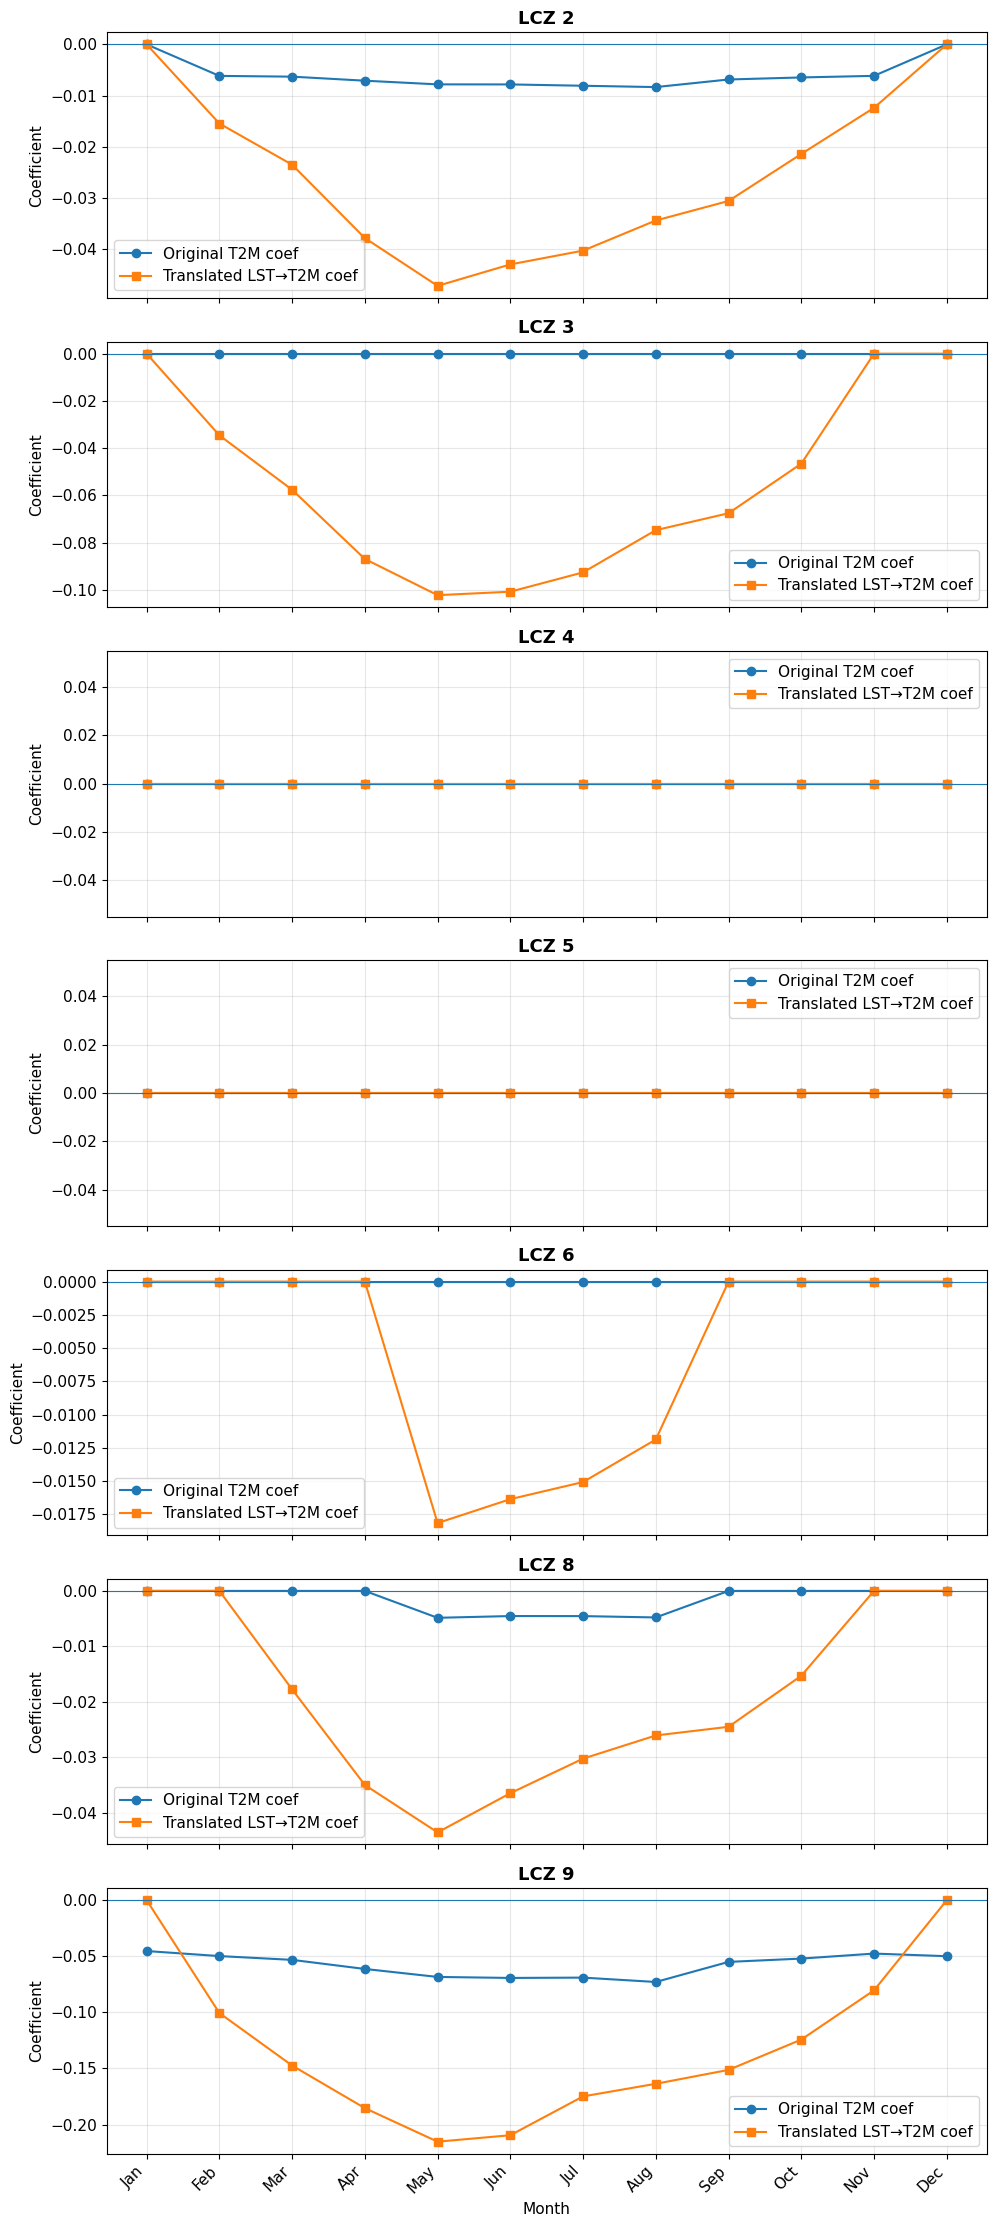

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/rome_coef_bridge_by_lcz.png


In [66]:
# Plot the direct and translated coefficients side by side by month and LCZ

import matplotlib.pyplot as plt

bridge_plot = bridge_view.copy()

lcz_list = sorted(bridge_plot["lcz"].dropna().unique().astype(int))
n_lcz = len(lcz_list)

fig, axes = plt.subplots(n_lcz, 1, figsize=(10, 3.2 * n_lcz), sharex=True)
if n_lcz == 1:
    axes = [axes]

for ax, lcz_code in zip(axes, lcz_list):
    tmp = bridge_plot[bridge_plot["lcz"] == lcz_code].sort_values("month")

    ax.plot(tmp["month"], tmp["coef_t2m"], marker="o", label="Original T2M coef")
    ax.plot(tmp["month"], tmp["coef_lst_as_t2m"], marker="s", label="Translated LST→T2M coef")

    ax.axhline(0, linewidth=0.8)
    ax.set_title(f"LCZ {lcz_code}", fontweight="bold")
    ax.set_ylabel("Coefficient")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[-1].set_xticks(range(1, 13))
axes[-1].set_xticklabels(
    [calendar.month_abbr[m] for m in range(1, 13)],
    rotation=45,
    ha="right"
)
axes[-1].set_xlabel("Month")

plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_coef_bridge_by_lcz.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {OUT / f'{SLUG}_coef_bridge_by_lcz.png'}")

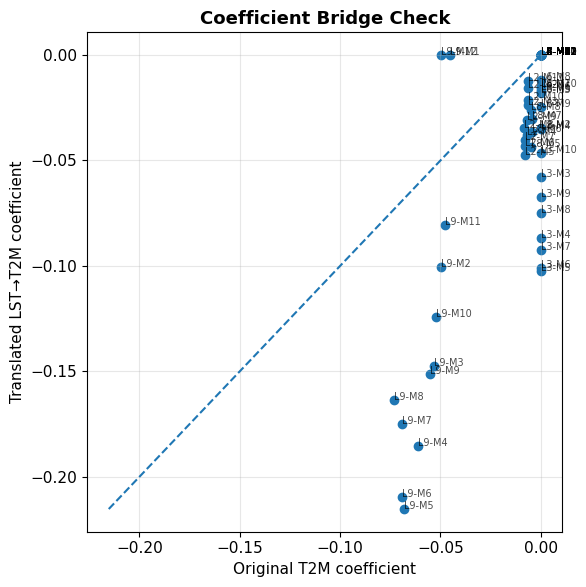

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT-HEAT/urban-heat/outputs/rome/rome_coef_bridge_scatter.png


In [67]:
# Scatter comparison between direct and translated T2M coefficients

tmp = bridge_view.copy()
tmp = tmp[np.isfinite(tmp["coef_t2m"]) & np.isfinite(tmp["coef_lst_as_t2m"])]

plt.figure(figsize=(6, 6))
plt.scatter(tmp["coef_t2m"], tmp["coef_lst_as_t2m"])

lo = min(tmp["coef_t2m"].min(), tmp["coef_lst_as_t2m"].min())
hi = max(tmp["coef_t2m"].max(), tmp["coef_lst_as_t2m"].max())
plt.plot([lo, hi], [lo, hi], linestyle="--")

for _, row in tmp.iterrows():
    plt.annotate(f"L{int(row['lcz'])}-M{int(row['month'])}",
                 (row["coef_t2m"], row["coef_lst_as_t2m"]),
                 fontsize=7, alpha=0.7)

plt.xlabel("Original T2M coefficient")
plt.ylabel("Translated LST→T2M coefficient")
plt.title("Coefficient Bridge Check", fontweight="bold")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / f"{SLUG}_coef_bridge_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {OUT / f'{SLUG}_coef_bridge_scatter.png'}")

In [68]:
# Summarize the bridge diagnostic at LCZ level

import numpy as np
import pandas as pd

# Assumes bridge_view already exists from the previous bridge-check cell
# Columns expected:
# month, lcz, coef_t2m, coef_lst_as_t2m, abs_gap, ratio_abs, sign_check

SUMMER_MONTHS = [5, 6, 7, 8, 9]
WINTER_MONTHS = [12, 1, 2]

def _is_zero(x, tol=1e-8):
    return np.isclose(x, 0.0, atol=tol)

def _same_summer_ordering(subdf):
    """
    Check whether the month ranking in summer is similar between:
    - original T2M coefficients
    - translated LST->T2M coefficients

    We use Spearman rank correlation on summer months.
    Returns NaN if not enough variation to rank meaningfully.
    """
    s = subdf[subdf["month"].isin(SUMMER_MONTHS)].sort_values("month").copy()
    if len(s) < 3:
        return np.nan

    x = s["coef_t2m"].to_numpy(float)
    y = s["coef_lst_as_t2m"].to_numpy(float)

    if np.all(~np.isfinite(x)) or np.all(~np.isfinite(y)):
        return np.nan

    # If either series is nearly constant, ordering is not informative
    if np.nanstd(x) < 1e-10 or np.nanstd(y) < 1e-10:
        return np.nan

    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()

    corr = np.corrcoef(rx, ry)[0, 1]
    return float(corr)

summary_rows = []

for lcz_code, g in bridge_view.groupby("lcz"):
    g = g.sort_values("month").copy()

    # Median absolute gap
    median_abs_gap = float(np.nanmedian(g["abs_gap"]))

    # Median translated/original ratio on non-zero original coefficients
    ratio_ok = (
        np.isfinite(g["ratio_abs"]) &
        (~_is_zero(g["coef_t2m"]))
    )
    median_ratio = float(np.nanmedian(g.loc[ratio_ok, "ratio_abs"])) if ratio_ok.any() else np.nan

    # Winter zero check: are BOTH series zero in all winter months?
    gw = g[g["month"].isin(WINTER_MONTHS)].copy()
    winter_both_zero = bool(
        len(gw) > 0 and
        np.all(_is_zero(gw["coef_t2m"])) and
        np.all(_is_zero(gw["coef_lst_as_t2m"]))
    )

    # Summer ordering similarity
    summer_rank_corr = _same_summer_ordering(g)

    # Optional simple flag
    if np.isnan(median_ratio):
        magnitude_flag = "no_nonzero_ref"
    elif median_ratio <= 1.5:
        magnitude_flag = "close"
    elif median_ratio <= 3.0:
        magnitude_flag = "moderate_gap"
    else:
        magnitude_flag = "large_gap"

    if np.isnan(summer_rank_corr):
        ordering_flag = "uninformative"
    elif summer_rank_corr >= 0.8:
        ordering_flag = "very_similar"
    elif summer_rank_corr >= 0.5:
        ordering_flag = "similar"
    elif summer_rank_corr >= 0:
        ordering_flag = "weakly_similar"
    else:
        ordering_flag = "different"

    sign_ok_share = float(np.mean(g["sign_check"].isin(["same_cooling_sign", "both_zero"])))

    summary_rows.append({
        "lcz": int(lcz_code),
        "median_abs_gap": median_abs_gap,
        "median_ratio_abs": median_ratio,
        "winter_both_zero": winter_both_zero,
        "summer_rank_corr": summer_rank_corr,
        "ordering_flag": ordering_flag,
        "magnitude_flag": magnitude_flag,
        "sign_ok_share": sign_ok_share,
        "n_months": int(len(g)),
    })

bridge_lcz_summary = pd.DataFrame(summary_rows).sort_values("lcz").reset_index(drop=True)

print("\n" + "="*80)
print("COMPACT LCZ SUMMARY: COEFFICIENT BRIDGE CHECK")
print("="*80)
print(bridge_lcz_summary.round(4).to_string(index=False))

# Save and store the bridge diagnostic outputs
bridge_lcz_summary_path = INT / f"{SLUG}_coef_bridge_lcz_summary.csv"
bridge_lcz_summary.to_csv(bridge_lcz_summary_path, index=False)
tables["coef_bridge_lcz_summary"] = bridge_lcz_summary

print(f"\n✓ Saved: {bridge_lcz_summary_path.name}")


COMPACT LCZ SUMMARY: COEFFICIENT BRIDGE CHECK
 lcz  median_abs_gap  median_ratio_abs  winter_both_zero  summer_rank_corr  ordering_flag magnitude_flag  sign_ok_share  n_months
   2          0.0205            4.2946             False               0.0 weakly_similar      large_gap            1.0        12
   3          0.0626               NaN             False               NaN  uninformative no_nonzero_ref            1.0        12
   4          0.0000               NaN              True               NaN  uninformative no_nonzero_ref            1.0        12
   5          0.0000               NaN              True               NaN  uninformative no_nonzero_ref            1.0        12
   6          0.0000               NaN              True               NaN  uninformative no_nonzero_ref            1.0        12
   8          0.0195            7.3529              True               0.6        similar      large_gap            1.0        12
   9          0.0925            2.4614     

In [69]:
# Short textual interpretation of the LCZ-level bridge summary

print("\nLCZ interpretation:")
for _, row in bridge_lcz_summary.iterrows():
    msg = (
        f"LCZ {int(row['lcz'])}: "
        f"median |gap|={row['median_abs_gap']:.4f}, "
        f"median ratio={row['median_ratio_abs']:.2f}x, "
        f"winter_both_zero={row['winter_both_zero']}, "
        f"summer_ordering={row['ordering_flag']}"
    )
    print(" - " + msg)


LCZ interpretation:
 - LCZ 2: median |gap|=0.0205, median ratio=4.29x, winter_both_zero=False, summer_ordering=weakly_similar
 - LCZ 3: median |gap|=0.0626, median ratio=nanx, winter_both_zero=False, summer_ordering=uninformative
 - LCZ 4: median |gap|=0.0000, median ratio=nanx, winter_both_zero=True, summer_ordering=uninformative
 - LCZ 5: median |gap|=0.0000, median ratio=nanx, winter_both_zero=True, summer_ordering=uninformative
 - LCZ 6: median |gap|=0.0000, median ratio=nanx, winter_both_zero=True, summer_ordering=uninformative
 - LCZ 8: median |gap|=0.0195, median ratio=7.35x, winter_both_zero=True, summer_ordering=similar
 - LCZ 9: median |gap|=0.0925, median ratio=2.46x, winter_both_zero=False, summer_ordering=weakly_similar


### 7.4 Vegetation Diagnostics JSON

The diagnostics JSON preserves the main greening, cooling, benefit, and cost summary quantities in a compact machine-readable form.


In [70]:
veg_diagnostics = {
    "city": CITY,
    "slug": SLUG,
    "policy": "uniform_Q3_target",
    "target_gvi": float(TARGET_GVI),
    "total_dGVI_points": float(DELTA_INDEX),
    "citywide_dGVI_popw": float(compute_popw_mean(dGVI_map, pop_on_ref, SCOPE_PHYS)),

    "dLST_summer_mean": float(np.nanmean(dLST_summer[SCOPE_PHYS])),
    "dLST_summer_popw": float(dLST_summer_popw),
    "dT2M_summer_approx_mean": float(np.nanmean(dT2M_summer_approx[SCOPE_PHYS])),
    "dT2M_summer_approx_popw": float(dT2M_summer_approx_popw),

    "cum_avoided_trees_only_25y": CUM_trees_only,
    "cum_avoided_trees_on_top_25y": CUM_trees_on_top,
    "pv_capex": PV_trees_capex,
    "pv_om_base": PV_trees_om,
    "pv_total_base": PV_trees_total,
    "eac_base": EAC_trees,
    "cost_per_death_base": cost_per_death_base if CUM_trees_only > 0 else None,
}

with open(OUT / f"{SLUG}_veg_diagnostics.json", "w") as f:
    json.dump(veg_diagnostics, f, indent=2)
print(f"✓ Saved: {SLUG}_veg_diagnostics.json")

✓ Saved: rome_veg_diagnostics.json


### 7.5 Cost Summary CSV

This CSV is the compact cost summary used downstream for CBA comparisons and robustness checks.


In [71]:
cost_summary_df = pd.DataFrame([
    {
        "scenario": "base_om",
        "pv_capex": PV_trees_capex,
        "pv_om": PV_trees_om,
        "pv_total": PV_trees_total,
        "eac": EAC_trees,
        "cum_avoided_25y": CUM_trees_only,
        "cost_per_death": cost_per_death_base if CUM_trees_only > 0 else np.nan,
    },
    {
        "scenario": "5x_om",
        "pv_capex": PV_trees_capex,
        "pv_om": PV_trees_om_5x,
        "pv_total": PV_trees_total_5x,
        "eac": EAC_trees_5x,
        "cum_avoided_25y": CUM_trees_only,
        "cost_per_death": cost_per_death_5x if CUM_trees_only > 0 else np.nan,
    },
])
cost_summary_df.to_csv(TBL / f"tree_cost_summary_{SLUG}.csv", index=False)
print(f"✓ Saved: tree_cost_summary_{SLUG}.csv")

✓ Saved: tree_cost_summary_rome.csv


### 7.6 Auxiliary Arrays for `NB08`

These auxiliary arrays store the cooling fields and policy surfaces needed for later cross-policy synthesis and diagnostics.


In [72]:
veg_aux_path = INT / f"{SLUG}_veg_aux_arrays.npz"
np.savez_compressed(
    veg_aux_path,
    dLST_month_ref_uniform=dLST_monthly,
    dLST_summer=dLST_summer,
    dT2M_month_ref_uniform_approx=dT2M_monthly_approx,
    dT2M_summer_approx=dT2M_summer_approx,
    dGVI_map=dGVI_map,
    gvi_baseline=gvi_on_ref,
    SCOPE_PHYS=SCOPE_PHYS,
)
print(f"✓ Saved: {veg_aux_path.name}")

✓ Saved: rome_veg_aux_arrays.npz


In [73]:
# Export the 25-year vegetation benefit series used later in NB8
trees_25y_df = pd.DataFrame({
    "year": YEARS_ALL,
    "trees_only_raw": trees_only_25y_raw,
    "trees_only_dynamic": trees_only_25y,
    "trees_on_top_raw": trees_on_top_25y_raw,
    "trees_on_top_dynamic": trees_on_top_25y,
    "maturity_factor": trees_factor,
    "ac_gross": ac_only_25y,
})
trees_25y_df.to_csv(TBL / f"trees_benefits_25y_{SLUG}.csv", index=False)
print(f"  Saved: trees_benefits_25y_{SLUG}.csv")

# Export the compact vegetation CEA summary for downstream use
cea_summary = {
    "policy": "trees_uniform",
    "pv_cost_base": float(PV_trees_total),
    "pv_cost_5x": float(PV_trees_total_5x),
    "avoided_deaths_25y": float(CUM_trees_only),
    "avoided_deaths_on_top_25y": float(CUM_trees_on_top),
    "cost_per_death_base": float(cost_per_death_base),
    "cost_per_death_5x": float(cost_per_death_5x),
    "ac_gross_25y": float(CUM_ac_gross),  # For reference only
}
with open(TBL / f"trees_cea_summary_{SLUG}.json", "w") as f:
    json.dump(cea_summary, f, indent=2)
print(f"  Saved: trees_cea_summary_{SLUG}.json")

  Saved: trees_benefits_25y_rome.csv
  Saved: trees_cea_summary_rome.json


## 8. Closing Export Repeat and Integrity Checks

The final cells repeat the core 25-year export objects for convenience and then run basic assertions on the regional masks and policy domain. They do not add a new modeling step; they are there to catch misalignment before the outputs are used downstream.


In [74]:
# Export the 25-year vegetation benefit series used later in NB8
trees_25y_df = pd.DataFrame({
    "year": YEARS_ALL,
    "trees_only_raw": trees_only_25y_raw,
    "trees_only_dynamic": trees_only_25y,
    "trees_on_top_raw": trees_on_top_25y_raw,
    "trees_on_top_dynamic": trees_on_top_25y,
    "maturity_factor": trees_factor,
    "ac_gross": ac_only_25y,
})
trees_25y_df.to_csv(TBL / f"trees_benefits_25y_{SLUG}.csv", index=False)
print(f"  Saved: trees_benefits_25y_{SLUG}.csv")

# Export the compact vegetation CEA summary for downstream use
cea_summary = {
    "policy": "trees_uniform",
    "pv_cost_base": float(PV_trees_total),
    "pv_cost_5x": float(PV_trees_total_5x),
    "avoided_deaths_25y": float(CUM_trees_only),
    "avoided_deaths_on_top_25y": float(CUM_trees_on_top),
    "cost_per_death_base": float(cost_per_death_base),
    "cost_per_death_5x": float(cost_per_death_5x),
    "ac_gross_25y": float(CUM_ac_gross),  # For reference only
}
with open(TBL / f"trees_cea_summary_{SLUG}.json", "w") as f:
    json.dump(cea_summary, f, indent=2)
print(f"  Saved: trees_cea_summary_{SLUG}.json")

  Saved: trees_benefits_25y_rome.csv
  Saved: trees_cea_summary_rome.json


## 8. Electricity co-benefits from vegetation

**Note:** The vegetation → electricity savings feedback (Falchetta, De Cian & Lunghi 2026) is now integrated directly into NB08's AC cost computation, where it reduces the AC policy's operating cost when combined with the vegetation policy. See NB08 Cell 24 (feedback) and Cell 33 (lambda_y waste heat scaling).


In [75]:
# Electricity co-benefit computation moved to NB08 (AC cost integration).
# The reduced-form elasticity from paper (0.8%/GVI point) is now applied directly
# to per-user kWh in the AC cost cell, making the AC policy cheaper when combined
# with vegetation. See NB08 for details.
pass


In [76]:
# Reload the legacy-named policy-region raster to run final integrity checks
z = np.load(INT / f"muni_on_ref_{SLUG}.npz")
region_on_ref = z["muni_on_ref"].astype("int32")
region_cov    = z["muni_cov"].astype(bool)
ANALYSIS_MASK_REGION = z["analysis_mask_muni"].astype(bool)

MASK_CITY   = CITY_MASK
MASK_REGION   = region_cov
MASK_POLICY = ANALYSIS_MASK_REGION

assert region_on_ref.shape == CITY_MASK.shape
assert region_cov.shape == CITY_MASK.shape
assert ANALYSIS_MASK_REGION.shape == CITY_MASK.shape
assert not np.any((region_on_ref > 0) & (~region_cov)), "Leakage: labels outside region_cov"
assert np.all(region_on_ref[MASK_POLICY] > 0), "Unlabeled pixels inside MASK_POLICY"
assert np.all(MASK_POLICY <= MASK_CITY)
assert np.all(MASK_POLICY <= MASK_REGION)


In [77]:
assert np.all(ANALYSIS_MASK_REGION <= CITY_MASK)
assert np.all(ANALYSIS_MASK_REGION <= region_cov)
assert np.all(region_on_ref[ANALYSIS_MASK_REGION] > 0)
assert not np.any((region_on_ref > 0) & (~region_cov))

print("Policy domain pixels:", int(MASK_POLICY.sum()))
print("Physical policy pixels (built):", int(SCOPE_PHYS.sum()))
print("Remainder pixels (CITY_MASK outside {VEG_REGION_LABEL.lower()}s):", int((MASK_CITY & ~MASK_REGION).sum()))

Policy domain pixels: 70694
Physical policy pixels (built): 48534
Remainder pixels (CITY_MASK outside {VEG_REGION_LABEL.lower()}s): 7235
